In [1]:
# ============================================================================
# ЯЧЕЙКА 1.1: ВСЕ ИМПОРТЫ
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import json
import warnings
import time
from itertools import combinations

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, precision_recall_curve
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, VotingRegressor, VotingClassifier, StackingRegressor, StackingClassifier
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from catboost import CatBoostRegressor, CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

import shap

warnings.filterwarnings('ignore')

# Создаём папки для результатов
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../results/clustering', exist_ok=True)
os.makedirs('../results/models', exist_ok=True)
os.makedirs('../models', exist_ok=True)
os.makedirs('../models/trained', exist_ok=True)
os.makedirs('../results/predictions', exist_ok=True)
os.makedirs('../results/shap_plots', exist_ok=True)
os.makedirs('../results/shap_plots_ac', exist_ok=True)

print(" Все импорты выполнены, папки созданы")

print("="*80)
print("1.1: ПОДГОТОВКА ДАННЫХ NHANES - ИНИЦИАЛИЗАЦИЯ")
print("="*80)

 Все импорты выполнены, папки созданы
1.1: ПОДГОТОВКА ДАННЫХ NHANES - ИНИЦИАЛИЗАЦИЯ


In [2]:
# ============================================================================
# ЭТАП 1.2: ДЕМОГРАФИЧЕСКИЕ ДАННЫЕ
# ============================================================================
print("="*80)
print("1.2: ДЕМОГРАФИЧЕСКИЕ ДАННЫЕ")
print("="*80)

# Загружаем демографию
# SEQN - уникальный идентификатор пациента для объединения с другими файлами
# RIDAGEYR - возраст, RIAGENDR - пол, RIDRETH3 - раса, INDFMPIR - доход
demo = pd.read_sas('../data/DEMO_J.xpt', format='xport')
demo = demo[['SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH3', 'INDFMPIR']].copy()
demo.columns = ['id', 'age', 'gender', 'race_code', 'income_ratio']

print(f" Загружено пациентов: {demo.shape[0]:,}")

# 1.1 Фильтр по возрасту (≥18 лет)
# Фокусируемся на взрослой популяции, так как паттерны кариеса у детей отличаются
demo = demo[demo['age'] >= 18].copy()
print(f" Взрослых ≥18 лет: {len(demo):,}")

# 1.2 Кодирование пола
# Преобразуем в бинарную переменную: 0=муж, 1=жен 
demo['gender'] = demo['gender'].replace({1: 0, 2: 1})  

# 1.3 One-Hot кодирование расы
# Используем One-Hot вместо числовых меток, чтобы избежать ложных порядковых отношений между расами
def map_race(code):
    if pd.isna(code):
        return 'other'
    code = int(code)
    # Объединяем Mexican American (1) и Other Hispanic (2) в 'latino'
    if code in [1, 2]:
        return 'latino'
    elif code == 3: # Non-Hispanic White
        return 'white'
    elif code == 4: # Non-Hispanic Black
        return 'black'
    elif code == 6: # Non-Hispanic Asian
        return 'asian'
    else:  # Другие расы и смешанные
        return 'other'

demo['race_cat'] = demo['race_code'].apply(map_race)
race_dummies = pd.get_dummies(demo['race_cat'], prefix='race', dtype=int)
demo = pd.concat([demo.drop(['race_code', 'race_cat'], axis=1), race_dummies], axis=1)

# 1.4 Возрастные группы
# Создаем категории для стратифицированного анализа и заполнения пропусков
demo['age_group'] = pd.cut(demo['age'], bins=[18, 30, 45, 60, 150],
                           labels=['18-29', '30-44', '45-59', '60+'],
                           right=False)

# 1.5 Доход
# Обработка пропусков: заполняем медианой по возрастным группам, 
# т.к. доход систематически связан с возрастом
missing_income = demo['income_ratio'].isnull().sum()
print(f" Пропусков в доходе: {missing_income:,} ({missing_income/len(demo)*100:.1f}%)")
if missing_income > 0:
    demo['income_ratio'] = demo.groupby('age_group', observed=False)['income_ratio'].transform(
        lambda x: x.fillna(x.median())
    )
    print(f" Заполнено медианой по возрастным группам")

# Категоризация дохода для удобства интерпретации
# <1: ниже прожиточного минимума, 1-3: средний класс, 3+: высокий доход
demo['income_category'] = pd.cut(
    demo['income_ratio'],
    bins=[0, 1, 3, demo['income_ratio'].max() + 0.1],
    labels=['низкий (<1)', 'средний (1-3)', 'высокий (3+)'],
    right=False
)

# Проверка корректности заполнения
print(f"\n Средний доход по возрастным группам после заполнения:")
print(demo.groupby('age_group', observed=True)['income_ratio'].mean().round(2))

# Описательная статистика для понимания выборки
print(f"\n РАСПРЕДЕЛЕНИЕ ДЕМОГРАФИИ:")
print(f" Возраст: {demo['age'].min()}-{demo['age'].max()} лет, среднее: {demo['age'].mean():.1f}")
print(f" Пол: {demo['gender'].sum():,} женщин ({(demo['gender'].mean()*100):.1f}%)")
print(f" Доход: медиана {demo['income_ratio'].median():.2f}, среднее: {demo['income_ratio'].mean():.2f}")
print(f" Распределение по категориям дохода:")
print(f"  - Низкий (<1): {(demo['income_category']=='низкий (<1)').sum():,} ({(demo['income_category']=='низкий (<1)').mean()*100:.1f}%)")
print(f"  - Средний (1-3): {(demo['income_category']=='средний (1-3)').sum():,} ({(demo['income_category']=='средний (1-3)').mean()*100:.1f}%)")
print(f"  - Высокий (3+): {(demo['income_category']=='высокий (3+)').sum():,} ({(demo['income_category']=='высокий (3+)').mean()*100:.1f}%)")
print(f" Раса: W:{demo['race_white'].sum():,} B:{demo['race_black'].sum():,} "
      f"L:{demo['race_latino'].sum():,} A:{demo['race_asian'].sum():,}")

# 1.6 Проверка пропусков
# Финальный контроль качества перед сохранением
print(f"\n ПРОВЕРКА ПРОПУСКОВ:")
missing_found = False
for column in demo.columns:
    missing = demo[column].isnull().sum()
    if missing > 0:
        print(f"• {column}: {missing} пропусков ({missing/len(demo)*100:.1f}%)")
        missing_found = True

if not missing_found:
    print(" Пропусков нет!")

# 1.7 Сохранение демографии
# Сохраняем для последующего объединения с другими данными
demo.to_csv('../data/processed/demo_processed.csv', index=False)
print(f" Демография сохранена: {len(demo):,} пациентов, {len(demo.columns)} признаков")

1.2: ДЕМОГРАФИЧЕСКИЕ ДАННЫЕ
 Загружено пациентов: 9,254
 Взрослых ≥18 лет: 5,856
 Пропусков в доходе: 835 (14.3%)
 Заполнено медианой по возрастным группам

 Средний доход по возрастным группам после заполнения:
age_group
18-29    2.09
30-44    2.48
45-59    2.69
60+      2.51
Name: income_ratio, dtype: float64

 РАСПРЕДЕЛЕНИЕ ДЕМОГРАФИИ:
 Возраст: 18.0-80.0 лет, среднее: 49.9
 Пол: 3,016.0 женщин (51.5%)
 Доход: медиана 2.16, среднее: 2.46
 Распределение по категориям дохода:
  - Низкий (<1): 975 (16.6%)
  - Средний (1-3): 3,076 (52.5%)
  - Высокий (3+): 1,805 (30.8%)
 Раса: W:2,032 B:1,343 L:1,335 A:849

 ПРОВЕРКА ПРОПУСКОВ:
 Пропусков нет!
 Демография сохранена: 5,856 пациентов, 11 признаков


In [3]:
# ============================================================================
# ЭТАП 1.3: СТОМАТОЛОГИЧЕСКИЕ ДАННЫЕ (РАСЧЕТ DMFT)
# ============================================================================
print("="*80)
print("1.3: СТОМАТОЛОГИЧЕСКИЕ ДАННЫЕ (РАСЧЕТ DMFT)")
print("="*80)

# Исключаем зубы мудрости
EXCLUDE_TEETH = [1, 16, 17, 32]

# 2.1 Загрузка и расчет DMFT
# OHXDEN_J.xpt - файл с данными стоматологического обследования
# OHX*CTC - коды состояния каждого зуба (C = Coronal, T = Tooth, C = Condition)
ohx = pd.read_sas('../data/OHXDEN_J.xpt', format='xport')
# Исключаем зубы мудрости (1,16,17,32), так как они часто отсутствуют и не учитываются в DMFT
ohx_columns = ['SEQN'] + [f'OHX{i:02d}CTC' for i in range(1, 33) if i not in EXCLUDE_TEETH]
ohx = ohx[ohx_columns].copy()
ohx.columns = ['id'] + [f'OHX{i:02d}CTC' for i in range(1, 33) if i not in EXCLUDE_TEETH]

print(f" Загружено: {len(ohx):,} записей")

# 2.2 Расчет DMFT
# DMFT (Decayed, Missing, Filled Teeth) - международный индекс интенсивности кариеса
# Сумма количества кариозных (Decayed), отсутствующих (Missing) и запломбированных (Filled) зубов
dmft_results = []
for _, row in ohx.iterrows():
    decayed = missing = filled = total = 0

    # Перебираем все зубы (исключая зубы мудрости)
    for tooth in range(1, 33):
        if tooth in EXCLUDE_TEETH:
            continue
            
        col = f'OHX{tooth:02d}CTC'
        if col not in row or pd.isna(row[col]):
            continue

        # Коды состояний зубов согласно документации NHANES:
        # ------------------------------------------------------------------
        # Decayed (кариес):
        # 'J' - Permanent root tip is present but no restorative replacement is present (корень зуба)
        # 'K' - Primary tooth with a dental carious surface condition (кариес молочного зуба)
        # 'Z' - Permanent tooth with a dental carious surface condition (кариес постоянного зуба)
        # 
        # Missing (отсутствует):
        # 'E' - Missing due to dental disease (удален из-за кариеса)
        # 'M' - Missing due to other causes (удален по другой причине)
        # 'P' - Missing due to dental disease but replaced by a removable restoration (заменен съемным протезом)
        # 'Q' - Missing due to other causes but replaced by a removable restoration
        # 'R' - Missing due to dental disease but replaced by a fixed restoration (заменен мостом)
        # 'X' - Missing due to other causes but replaced by a fixed restoration
        #
        # Filled (пломба):
        # 'A' - Primary tooth with a restored surface condition (пломба на молочном зубе)
        # 'F' - Permanent tooth with a restored surface condition (пломба на постоянном зубе)
        # 'T' - Permanent root tip is present but a restorative replacement is present (корень с реставрацией)
        #
        # Present (присутствует, здоров):
        # 'D' - Sound primary tooth (здоровый молочный зуб)
        # 'S' - Sound permanent tooth (здоровый постоянный зуб)
        # ------------------------------------------------------------------

        # Коды состояния зубов (по документации NHANES)
        DECAYED_CODES = ['Z', 'J', 'K']
        MISSING_CODES = ['E', 'M', 'P', 'Q', 'R', 'X']
        FILLED_CODES = ['F', 'A', 'T']
        SOUND_CODES = ['S', 'D']

        val = row[col]    
        if isinstance(val, bytes):
            code = val.decode('utf-8', errors='ignore').strip().upper()
        else:
            code = str(val).strip().upper()
        
        if code in DECAYED_CODES:
            decayed += 1
            total += 1
        elif code in MISSING_CODES:
            missing += 1
        elif code in FILLED_CODES:
            filled += 1
            total += 1
        elif code in SOUND_CODES:
            total += 1
    
    dmft_results.append({
        'id': row['id'],
        'teeth_total': total, # Общее количество присутствующих зубов
        'teeth_decayed': decayed, # Количество кариозных зубов (целевая переменная)
        'teeth_missing': missing, # Количество отсутствующих зубов
        'teeth_filled': filled,   # Количество запломбированных зубов
        'dmft':  decayed + missing + filled,
        'active_caries':  1 if decayed > 0 else 0
    })

dmft_df = pd.DataFrame(dmft_results)
print(f" Рассчитано DMFT: {len(dmft_df):,} пациентов")

# 2.3 Объединение с демографией
# inner join - оставляем только пациентов, у которых есть и демография, и стоматология
all_data = pd.merge(demo, dmft_df, on='id', how='inner')

# 2.4 Анализ
# Первичный анализ распределения кариеса в выборке
print(f"\n АНАЛИЗ КАРИЕСА:")
print(f" Всего пациентов: {len(all_data):,}")
print(f" Средний кариес: {all_data['teeth_decayed'].mean():.2f} зубов")
print(f" Без кариеса: {(all_data['teeth_decayed'] == 0).sum():,} ({(all_data['teeth_decayed'] == 0).mean()*100:.1f}%)")
print(f" Средний DMFT: {all_data['dmft'].mean():.2f}")

print(f" С кариесом: {(all_data['teeth_decayed'] > 0).sum():,} пациентов")

# 2.5 Проверка пропусков
# Важно убедиться, что объединение прошло корректно
print(f"\n ПРОВЕРКА:")
print(f" Пропусков: {all_data.isnull().sum().sum()}")

# 2.6 Сохранение
# Сохраняем промежуточный результат перед добавлением медицинских показателей
dental_path = '../data/processed/dental_processed.csv'
all_data.to_csv(dental_path, index=False)
print(f" Стоматологические данные сохранены")

1.3: СТОМАТОЛОГИЧЕСКИЕ ДАННЫЕ (РАСЧЕТ DMFT)
 Загружено: 8,366 записей
 Рассчитано DMFT: 8,366 пациентов

 АНАЛИЗ КАРИЕСА:
 Всего пациентов: 5,533
 Средний кариес: 0.77 зубов
 Без кариеса: 4,201 (75.9%)
 Средний DMFT: 11.34
 С кариесом: 1,332 пациентов

 ПРОВЕРКА:
 Пропусков: 0
 Стоматологические данные сохранены


In [4]:
# ============================================================================
# ЭТАП 1.4.1: ПРОВЕРКА ПЕРЕКОСА В ПРИЗНАКЕ ДЕПРЕССИЯ
# ============================================================================
print("="*80)
print("1.4.1: ПРОВЕРКА ПЕРЕКОСА В ПРИЗНАКЕ ДЕПРЕССИЯ")
print("="*80)

dpq = pd.read_sas('../data/DPQ_J.xpt', format='xport')
depression = dpq[['SEQN', 'DPQ010', 'DPQ020', 'DPQ030', 'DPQ040', 
                  'DPQ050', 'DPQ060', 'DPQ070', 'DPQ080', 'DPQ090']].copy()
depression.columns = ['id', 'dep1', 'dep2', 'dep3', 'dep4', 'dep5', 
                      'dep6', 'dep7', 'dep8', 'dep9']

phq9_questions = ['dep1', 'dep2', 'dep3', 'dep4', 'dep5', 'dep6', 'dep7', 'dep8', 'dep9']

total = len(depression)

# 1. Сколько пациентов с пропусками
print("\n1. СТАТИСТИКА ПРОПУСКОВ:")
print("-" * 50)

missing_patients = 0
for idx, row in depression[phq9_questions].iterrows():
    # Пропуск = NaN, 7 (отказ), 9 (не знаю)
    missing = sum(1 for v in row if pd.isna(v) or v in [7, 9])
    if missing > 0:
        missing_patients += 1

print(f"   Всего пациентов: {total}")
print(f"   Пациентов с пропусками: {missing_patients} ({missing_patients/total*100:.1f}%)")
print(f"   Пациентов без пропусков: {total - missing_patients} ({(total-missing_patients)/total*100:.1f}%)")

# 2. По сколько пропусков на пациента
print("\n2. РАСПРЕДЕЛЕНИЕ ПО КОЛИЧЕСТВУ ПРОПУСКОВ:")
print("-" * 50)

missing_dist = {}
for idx, row in depression[phq9_questions].iterrows():
    missing = sum(1 for v in row if pd.isna(v) or v in [7, 9])
    missing_dist[missing] = missing_dist.get(missing, 0) + 1

for m in sorted(missing_dist.keys()):
    count = missing_dist[m]
    print(f"   {m} пропусков: {count} пациентов ({count/total*100:.1f}%)")

# 3. Какие ответы считаются пропусками
print("\n3. ТИПЫ ПРОПУСКОВ В ДАННЫХ:")
print("-" * 50)

for q in phq9_questions:
    nan_count = depression[q].isnull().sum()
    code_7 = (depression[q] == 7).sum()
    code_9 = (depression[q] == 9).sum()
    print(f"   {q}: NaN={nan_count}, отказ(7)={code_7}, не знаю(9)={code_9}")

print("\n" + "="*80)
print("ВЫВОД: Анализ завершён")
print("="*80)

1.4.1: ПРОВЕРКА ПЕРЕКОСА В ПРИЗНАКЕ ДЕПРЕССИЯ

1. СТАТИСТИКА ПРОПУСКОВ:
--------------------------------------------------
   Всего пациентов: 5533
   Пациентов с пропусками: 465 (8.4%)
   Пациентов без пропусков: 5068 (91.6%)

2. РАСПРЕДЕЛЕНИЕ ПО КОЛИЧЕСТВУ ПРОПУСКОВ:
--------------------------------------------------
   0 пропусков: 5068 пациентов (91.6%)
   1 пропусков: 15 пациентов (0.3%)
   2 пропусков: 3 пациентов (0.1%)
   3 пропусков: 1 пациентов (0.0%)
   4 пропусков: 1 пациентов (0.0%)
   8 пропусков: 5 пациентов (0.1%)
   9 пропусков: 440 пациентов (8.0%)

3. ТИПЫ ПРОПУСКОВ В ДАННЫХ:
--------------------------------------------------
   dep1: NaN=439, отказ(7)=4, не знаю(9)=4
   dep2: NaN=440, отказ(7)=2, не знаю(9)=4
   dep3: NaN=440, отказ(7)=3, не знаю(9)=4
   dep4: NaN=441, отказ(7)=3, не знаю(9)=4
   dep5: NaN=441, отказ(7)=2, не знаю(9)=3
   dep6: NaN=442, отказ(7)=3, не знаю(9)=5
   dep7: NaN=442, отказ(7)=2, не знаю(9)=3
   dep8: NaN=442, отказ(7)=2, не знаю(9)=5
   

In [5]:
# ============================================================================
# ЭТАП 1.4.2: МЕДИЦИНСКИЕ ПОКАЗАТЕЛИ (BMI, ДИАБЕТ, АСТМА, ДЕПРЕССИЯ)
# ============================================================================
print("="*80)
print("1.4.2: МЕДИЦИНСКИЕ ПОКАЗАТЕЛИ (BMI, ДИАБЕТ, АСТМА, ДЕПРЕССИЯ)")
print("="*80)

# 3.1 Индекс массы тела (BMI)
# BMX_J.xpt - файл с антропометрическими данными
# BMXBMI - рассчитанный индекс массы тела (вес в кг / рост в м²)
bmx = pd.read_sas('../data/BMX_J.xpt', format='xport')
bmi_data = bmx[['SEQN', 'BMXBMI']].copy()
bmi_data.columns = ['id', 'bmi']
# left join - сохраняем всех пациентов, даже если нет BMI
all_data = pd.merge(all_data, bmi_data, on='id', how='left')
print(f" BMI добавлен, пропусков: {all_data['bmi'].isnull().sum():,}")

# 3.2 Диабет
# DIQ_J.xpt - файл с вопросами о диабете
# DIQ010: 1=диабет, 2=нет диабета, 3=предиабет
# DIQ160: 1=предиабет
diq = pd.read_sas('../data/DIQ_J.xpt', format='xport')
diabetes_data = diq[['SEQN', 'DIQ010', 'DIQ160']].copy()
diabetes_data.columns = ['id', 'has_diabetes', 'has_prediabetes']

# Создаем 3-категориальную переменную:
# 2 = диабет
# 1 = предиабет 
# 0 = нет диабета
def get_diabetes_final(row):
    diag_diabetes = row['has_diabetes']
    diag_prediabetes = row['has_prediabetes']

    # Диабет
    if diag_diabetes == 1:
        return 2
    # Предиабет
    elif diag_diabetes == 3:
        return 1
    # Нет диабета, но проверяем предиабет
    elif diag_diabetes == 2:
        return 1 if diag_prediabetes == 1 else 0
    # Пропуски - проверяем только предиабет
    else:
        return 1 if diag_prediabetes == 1 else 0

diabetes_data['diabetes'] = diabetes_data.apply(get_diabetes_final, axis=1)
all_data = pd.merge(all_data, diabetes_data[['id', 'diabetes']], on='id', how='left')
print(f" Диабет добавлен (0=нет, 1=предиабет, 2=диабет), пропусков: {all_data['diabetes'].isnull().sum():,}")

# 3.3 Астма
# MCQ_J.xpt - файл с вопросами о различных медицинских состояниях
# MCQ010: 1=астма, 2=нет астмы
mcq = pd.read_sas('../data/MCQ_J.xpt', format='xport')
asthma_data = mcq[['SEQN', 'MCQ010']].copy()
asthma_data.columns = ['id', 'asthma']
# Преобразуем в бинарную переменную: 1=астма, 0=нет астмы
asthma_data['asthma'] = (asthma_data['asthma'] == 1).astype(int)
all_data = pd.merge(all_data, asthma_data, on='id', how='left')
print(f" Астма добавлена, пропусков: {all_data['asthma'].isnull().sum():,}")

# 3.4 Депрессия (PHQ-9) - ПРОВЕРКА ПО ДИАПАЗОНУ
print("   Обработка депрессии (PHQ-9) с категорией 'unknown'...")

dpq = pd.read_sas('../data/DPQ_J.xpt', format='xport')
depression = dpq[['SEQN', 'DPQ010', 'DPQ020', 'DPQ030', 'DPQ040', 
                  'DPQ050', 'DPQ060', 'DPQ070', 'DPQ080', 'DPQ090']].copy()
depression.columns = ['id', 'dep1', 'dep2', 'dep3', 'dep4', 'dep5', 
                      'dep6', 'dep7', 'dep8', 'dep9']

phq9_questions = ['dep1', 'dep2', 'dep3', 'dep4', 'dep5', 'dep6', 'dep7', 'dep8', 'dep9']

def get_depression_by_range(row):
    """Классификация по диапазону значений"""
    valid = []
    for v in row:
        # Если значение НЕ число -> пропускаем
        if not isinstance(v, (int, float)):
            continue
        # Если число в диапазоне 0-3 -> валидный ответ
        if 0 <= v <= 3:
            valid.append(int(v))
        # 7 и 9 (отказ/не знаю) -> пропускаем
    
    if len(valid) < 5:
        return 2
    return 1 if sum(valid) >= 10 else 0

depression['depression'] = depression[phq9_questions].apply(get_depression_by_range, axis=1)

print(f"      Нет депрессии (0): {(depression['depression'] == 0).sum()} ({(depression['depression'] == 0).mean()*100:.1f}%)")
print(f"      Депрессия (1): {(depression['depression'] == 1).sum()} ({(depression['depression'] == 1).mean()*100:.1f}%)")
print(f"      Неизвестно (2): {(depression['depression'] == 2).sum()} ({(depression['depression'] == 2).mean()*100:.1f}%)")

all_data = pd.merge(all_data, depression[['id', 'depression']], on='id', how='left')
print(f" Депрессия добавлена, пропусков: {all_data['depression'].isnull().sum():,}")

# Сохраняем промежуточный результат с пропусками
# Пропуски будут обработаны на следующем этапе после анализа их природы
medical_path = '../data/processed/data_with_medical_raw.csv'
all_data.to_csv(medical_path, index=False)
print(f"\n Медицинские данные сохранены: {medical_path}")

1.4.2: МЕДИЦИНСКИЕ ПОКАЗАТЕЛИ (BMI, ДИАБЕТ, АСТМА, ДЕПРЕССИЯ)
 BMI добавлен, пропусков: 99
 Диабет добавлен (0=нет, 1=предиабет, 2=диабет), пропусков: 0
 Астма добавлена, пропусков: 0
   Обработка депрессии (PHQ-9) с категорией 'unknown'...
      Нет депрессии (0): 4627 (83.6%)
      Депрессия (1): 461 (8.3%)
      Неизвестно (2): 445 (8.0%)
 Депрессия добавлена, пропусков: 0

 Медицинские данные сохранены: ../data/processed/data_with_medical_raw.csv


In [6]:
# ============================================================================
# ЭТАП 1.5: ПОТРЕБЛЕНИЕ САХАРА
# ============================================================================
print("="*80)
print("1.5: ПОТРЕБЛЕНИЕ САХАРА")
print("="*80)

# 4.1 Загрузка данных о питании за 2 дня
# DR1TOT_J.xpt и DR2TOT_J.xpt - файлы с данными 24-часового recall о питании
# NHANES собирает данные за два отдельных дня для повышения надежности оценок
# DR1TSUGR / DR2TSUGR - общее потребление сахара в граммах за день
day1 = pd.read_sas('../data/DR1TOT_J.xpt', format='xport')
day2 = pd.read_sas('../data/DR2TOT_J.xpt', format='xport')

sugar_day1 = day1[['SEQN', 'DR1TSUGR']].copy()
sugar_day2 = day2[['SEQN', 'DR2TSUGR']].copy()
sugar_day1.columns = ['id', 'sugar_day1']
sugar_day2.columns = ['id', 'sugar_day2']

# 4.2 Объединение и расчет среднего
# outer join - сохраняем всех пациентов, у кого есть хотя бы один день данных
sugar_all = pd.merge(sugar_day1, sugar_day2, on='id', how='outer')

# Функция для расчета среднего потребления
# Используем среднее за два дня, чтобы уменьшить влияние внутрииндивидуальной вариабельности
def get_average_sugar(row):
    values = []
    if pd.notna(row['sugar_day1']):
        values.append(row['sugar_day1'])
    if pd.notna(row['sugar_day2']):
        values.append(row['sugar_day2'])
    return np.mean(values) if values else np.nan

sugar_all['sugar_avg'] = sugar_all.apply(get_average_sugar, axis=1)

# 4.3 Объединение с основными данными 
# left join - сохраняем всех пациентов, даже если нет данных о питании
# Пропуски будут обработаны позже
all_data = pd.merge(all_data, sugar_all[['id', 'sugar_avg']], on='id', how='left')

print(f" Сахар добавлен: {all_data['sugar_avg'].notna().sum():,} записей")
print(f" Пропусков: {all_data['sugar_avg'].isna().sum():,} ({all_data['sugar_avg'].isna().mean()*100:.1f}%)")
print(f" Среднее потребление: {all_data['sugar_avg'].mean():.1f} г/день")

1.5: ПОТРЕБЛЕНИЕ САХАРА
 Сахар добавлен: 4,983 записей
 Пропусков: 550 (9.9%)
 Среднее потребление: 101.0 г/день


In [7]:
# ============================================================================
# ЭТАП 1.6: КУРЕНИЕ
# ============================================================================
print("="*80)
print("1.6: КУРЕНИЕ")
print("="*80)

# 5.1 Загрузка данных о курении
# SMQ_J.xpt - файл с вопросами о курении 
# 
# Переменные:
# SMQ020 - Выкурил ли хотя бы 100 сигарет за всю жизнь
#          1 = Yes (да), 2 = No (нет), 7=Refused, 9=Don't know
#
# SMQ040 - Курит ли сейчас сигареты (задается только если SMQ020 = 1)
#          1 = Every day (каждый день)
#          2 = Some days (иногда)
#          3 = Not at all (совсем не курит)
#          7=Refused, 9=Don't know
#
# SMD057 - Сколько сигарет в день выкуривал, когда бросил
#          Диапазон значений: 1-90 (количество сигарет)
#          1 = 1 cigarette or less
#          95 = 95 cigarettes or more
#          777 = Refused, 999 = Don't know
smoking_raw = pd.read_sas('../data/SMQ_J.xpt', format='xport')
smoking_data = smoking_raw[['SEQN', 'SMQ020', 'SMQ040', 'SMD057']].copy()
smoking_data.columns = ['id', 'smoked_100', 'smoke_now', 'smoke_quit']

# 5.2 Обработка статуса курения
# Создаем бинарную переменную: 1=курит сейчас, 0=не курит
def process_smoking(row):
    
    smoked = row['smoked_100']  # Курил ли когда-либо 100 сигарет
    smokes = row['smoke_now']   # Курит ли сейчас
    quit = row['smoke_quit']    # Данные о курении при отказе
    
     # Шаг 1: Прямой вопрос о текущем курении (SMQ040)
    if pd.notna(smokes) and smokes not in [7, 9]:
        if smokes in [1, 2]:  # 1=каждый день, 2=иногда
            return 1  # Курит сейчас
        elif smokes == 3:  # 3=не курит совсем
            return 0  # Не курит (бывший курильщик)
    
    # Шаг 2: Если есть данные о количестве сигарет при отказе (SMD057)
    # Любое числовое значение означает, что человек бросил курить
    if pd.notna(quit):
        return 0  # Не курит (есть данные о том сколько курил когда бросил → бросил)
    
    # 3. Если нет ни smokes ни quit, проверяем smoked_100
    if pd.notna(smoked) and smoked not in [7, 9]:
        if smoked == 1:  # выкурил ≥100 сигарет
            return 1  # Курит 
        elif smoked == 2:  # не выкурил 100 сигарет (не окажет существенного влияния на стоматологический статус)
            return 0  # Не курит 
    
    # 4. Все остальные случаи (все пропуски)
    return  np.nan  # Неизвестно

smoking_data['smoking_status'] = smoking_data.apply(process_smoking, axis=1)

# 5.3 Объединение с основными данными
all_data = pd.merge(all_data, smoking_data[['id', 'smoking_status']], on='id', how='left')

print(f" Курение добавлено: {all_data['smoking_status'].notna().sum():,} записей")
print(f" Текущие курильщики: {(all_data['smoking_status'] == 1).sum():,}")
print(f" Пропуски: {all_data['smoking_status'].isna().sum():,} ({all_data['smoking_status'].isna().mean()*100:.1f}%)")

1.6: КУРЕНИЕ
 Курение добавлено: 5,533 записей
 Текущие курильщики: 972
 Пропуски: 0 (0.0%)


In [8]:
# ============================================================================
# ЭТАП 1.7: ОБРАБОТКА ПРОПУСКОВ - АНАЛИЗ СВЯЗЕЙ BMI
# ============================================================================
print("="*80)
print("1.7: ОБРАБОТКА ПРОПУСКОВ - АНАЛИЗ СВЯЗЕЙ BMI")
print("="*80)

# Перед заполнением пропусков анализируем природу пропусков
# и связи BMI с другими переменными. Это позволит обоснованно выбрать
# стратегию импутации.

# Берем только записи с известным BMI
bmi_known = all_data[all_data['bmi'].notna()].copy()
print(f"Анализируем {len(bmi_known)} пациентов с известным BMI\n")

# 1. Непрерывные признаки (корреляции)
# Анализируем линейные связи BMI с другими количественными переменными
print(" КОРРЕЛЯЦИИ С НЕПРЕРЫВНЫМИ ПРИЗНАКАМИ:")
print("-" * 60)

continuous = ['age', 'income_ratio', 'sugar_avg', 'teeth_decayed', 'dmft', 'teeth_missing', 'teeth_filled']
for feat in continuous:
    if feat in bmi_known.columns:
        corr = bmi_known[feat].corr(bmi_known['bmi'])
        print(f"  {feat:15}: {corr:6.3f}")

# 2. Категориальные признаки (средний BMI по группам)
# Анализируем различия в BMI между группами пациентов
# Это поможет понять, какие переменные важны для стратифицированной импутации
print("\n СРЕДНИЙ BMI ПО КАТЕГОРИЯМ:")
print("-" * 60)

categorical = {
    'gender': {0: 'Мужчины', 1: 'Женщины'},
    'diabetes': {0: 'Нет диабета', 1: 'Предиабет', 2: 'Диабет'},  
    'asthma': {0: 'Нет астмы', 1: 'Астма'},
    'depression': {0: 'Нет депрессии', 1: 'Депрессия', 2: 'Неизвестно'},  
    'smoking_status': {0: 'Не курит', 1: 'Курит'},
    'race_white': {0: 'Другие расы', 1: 'Белые'},
    'race_black': {0: 'Другие расы', 1: 'Черные'},
    'race_latino': {0: 'Другие расы', 1: 'Латино'},
    'race_asian': {0: 'Другие расы', 1: 'Азиаты'},
    'race_other': {0: 'Другие расы', 1: 'Другая раса'},
    'age_group': { 
        '18-29': '18-29 лет',
        '30-44': '30-44 лет',
        '45-59': '45-59 лет', 
        '60+': '60+ лет'
    },
    'income_category': {  
        'низкий (<1)': 'Низкий доход',
        'средний (1-3)': 'Средний доход',
        'высокий (3+)': 'Высокий доход'
    }
}

for cat, labels in categorical.items():
    if cat in bmi_known.columns:
        print(f"\n{cat}:")
        means = bmi_known.groupby(cat, observed=True)['bmi'].mean()
        for val, mean_val in means.items():
            label = labels.get(val, val)
            # Вычисляем отклонение от общего среднего BMI
            # Это показывает, насколько группа специфична по BMI
            diff = mean_val - bmi_known['bmi'].mean()
            diff_sign = '+' if diff > 0 else ''
            print(f"    {label:15}: {mean_val:5.1f}  ({diff_sign}{diff:.1f} от среднего)")

# 3. ВЫВОД - что сильнее всего влияет
# Определяем, какие категориальные переменные создают наибольшие различия в BMI
# Эти переменные будут использованы для групповой импутации
print("\n" + "="*80)
print(" ЧТО ВЛИЯЕТ НА BMI БОЛЬШЕ ВСЕГО:")
print("="*80)

# Сортируем категории по разнице между группами
# Чем больше разница, тем важнее учитывать эту переменную при заполнении пропусков
print("\n Разница между группами:")
diffs = []
for cat in categorical.keys():
    if cat in bmi_known.columns:
        means = bmi_known.groupby(cat, observed=True)['bmi'].mean()
        if len(means) > 1:
            max_diff = means.max() - means.min()
            diffs.append((cat, max_diff))

diffs.sort(key=lambda x: x[1], reverse=True)
for cat, diff in diffs[:5]:  # Топ-5
    print(f"  {cat:15}: разница {diff:.1f} ед. BMI между группами")

1.7: ОБРАБОТКА ПРОПУСКОВ - АНАЛИЗ СВЯЗЕЙ BMI
Анализируем 5434 пациентов с известным BMI

 КОРРЕЛЯЦИИ С НЕПРЕРЫВНЫМИ ПРИЗНАКАМИ:
------------------------------------------------------------
  age            :  0.029
  income_ratio   : -0.039
  sugar_avg      : -0.013
  teeth_decayed  :  0.017
  dmft           : -0.002
  teeth_missing  : -0.001
  teeth_filled   : -0.008

 СРЕДНИЙ BMI ПО КАТЕГОРИЯМ:
------------------------------------------------------------

gender:
    Мужчины        :  29.2  (-0.5 от среднего)
    Женщины        :  30.1  (+0.4 от среднего)

diabetes:
    Нет диабета    :  28.8  (-0.9 от среднего)
    Предиабет      :  31.7  (+2.1 от среднего)
    Диабет         :  32.4  (+2.7 от среднего)

asthma:
    Нет астмы      :  29.4  (-0.3 от среднего)
    Астма          :  31.5  (+1.8 от среднего)

depression:
    Нет депрессии  :  29.6  (-0.1 от среднего)
    Депрессия      :  31.4  (+1.7 от среднего)
    Неизвестно     :  28.6  (-1.1 от среднего)

smoking_status:
    Не кур

In [9]:
# ============================================================================
# ЭТАП 1.8: ОБРАБОТКА ПРОПУСКОВ - ЗАПОЛНЕНИЕ BMI
# ============================================================================
print("="*80)
print("1.8: ОБРАБОТКА ПРОПУСКОВ - ЗАПОЛНЕНИЕ BMI")
print("="*80)

bmi_missing = all_data['bmi'].isnull().sum()
if bmi_missing > 0:
    print(f"\n Заполняем {bmi_missing} пропусков BMI...")
    
    # Стратегия импутации: групповое заполнение медианой
    # На основе анализа топ-5 факторов, влияющих на BMI
    race_cols = ['race_asian', 'race_black', 'race_latino', 'race_white', 'race_other']

    # Факторы для стратифицированной импутации BMI (топ-5 из анализа)
    grouping_cols = race_cols + ['diabetes', 'asthma', 'depression', 'age_group']
    
    # Создаем составной ключ группы из всех значимых категориальных переменных
    all_data['bmi_group'] = ''
    for col in grouping_cols:
        all_data['bmi_group'] = all_data['bmi_group'] + '_' + all_data[col].astype(str)
    
    # Убираем первое подчеркивание
    all_data['bmi_group'] = all_data['bmi_group'].str[1:]

    # Заполняем пропуски медианой по каждой группе
    filled = 0
    for group in all_data['bmi_group'].unique():
        # Находим пациентов в этой группе с пропущенным BMI
        mask = (all_data['bmi_group'] == group) & all_data['bmi'].isna()
        if mask.sum() > 0:
            # Вычисляем медиану BMI для этой группы (по пациентам с известным BMI)
            group_median = all_data[
                (all_data['bmi_group'] == group) & 
                all_data['bmi'].notna()
            ]['bmi'].median()

            # Если медиана не NaN - заполняем
            if not pd.isna(group_median):
                all_data.loc[mask, 'bmi'] = group_median
                filled += mask.sum()

    print(f" Заполнено {filled} пропусков групповой медианой")
    
    # ДОЗАПОЛНЕНИЕ ОСТАВШИХСЯ ПРОПУСКОВ (уникальные группы) ==========
    still_missing = all_data['bmi'].isna().sum()
    if still_missing > 0:
        global_median = all_data['bmi'].median()
        all_data['bmi'] = all_data['bmi'].fillna(global_median)
        print(f" Дозаполнено {still_missing} пропусков глобальной медианой ({global_median:.1f})")
    
    # Удаляем временную колонку
    all_data = all_data.drop(columns=['bmi_group'])
    
else:
    print(f"\n Пропусков BMI нет, импутация не требуется.")

1.8: ОБРАБОТКА ПРОПУСКОВ - ЗАПОЛНЕНИЕ BMI

 Заполняем 99 пропусков BMI...
 Заполнено 98 пропусков групповой медианой
 Дозаполнено 1 пропусков глобальной медианой (28.4)


In [10]:
# ============================================================================
# ЭТАП 1.9: ОБРАБОТКА ПРОПУСКОВ - АНАЛИЗ СВЯЗЕЙ САХАРА
# ============================================================================
print("="*80)
print("1.9: ОБРАБОТКА ПРОПУСКОВ - АНАЛИЗ СВЯЗЕЙ САХАРА")
print("="*80)

# Изучаем структуру пропусков и связи потребления сахара
# с другими переменными перед импутацией
# Это позволит выбрать обоснованную стратегию заполнения

# Берем только записи с известным сахаром
sugar_known = all_data[all_data['sugar_avg'].notna()].copy()
print(f"Анализируем {len(sugar_known)} пациентов с известным потреблением сахара\n")

# 1. Непрерывные признаки (корреляции)
# Анализируем линейные связи потребления сахара с другими количественными переменными
print(" КОРРЕЛЯЦИИ С НЕПРЕРЫВНЫМИ ПРИЗНАКАМИ:")
print("-" * 60)

continuous = ['age', 'income_ratio', 'bmi', 'teeth_decayed', 'dmft', 'teeth_missing', 'teeth_filled']
for feat in continuous:
    if feat in sugar_known.columns:
        corr = sugar_known[feat].corr(sugar_known['sugar_avg'])
        print(f"   {feat:15}: {corr:6.3f}")

## 2. Категориальные признаки (средний сахар по группам)
# Анализируем различия в потреблении сахара между группами пациентов
# Это поможет понять, какие переменные важны для стратифицированной импутации
print("\n СРЕДНИЙ САХАР ПО КАТЕГОРИЯМ:")
print("-" * 60)

categorical = {
    'gender': {0: 'Мужчины', 1: 'Женщины'},
    'diabetes': {0: 'Нет диабета', 1: 'Предиабет', 2: 'Диабет'},  #
    'asthma': {0: 'Нет астмы', 1: 'Астма'},
    'depression': {0: 'Нет депрессии', 1: 'Депрессия', 2: 'Неизвестно'},  
    'smoking_status': {0: 'Не курит', 1: 'Курит'},
    'poor_hygiene': {0: 'Хорошая гигиена', 1: 'Плохая гигиена'},
    'race_white': {0: 'Другие расы', 1: 'Белые'},
    'race_black': {0: 'Другие расы', 1: 'Черные'},
    'race_latino': {0: 'Другие расы', 1: 'Латино'},
    'race_asian': {0: 'Другие расы', 1: 'Азиаты'},
    'race_other': {0: 'Другие расы', 1: 'Другая раса'},
    'age_group': {  
        '18-29': '18-29 лет',
        '30-44': '30-44 лет',
        '45-59': '45-59 лет', 
        '60+': '60+ лет'
    },
    'income_category': {  
        'низкий (<1)': 'Низкий доход',
        'средний (1-3)': 'Средний доход',
        'высокий (3+)': 'Высокий доход'
    }
}

for cat, labels in categorical.items():
    if cat in sugar_known.columns:
        print(f"\n{cat}:")
        means = sugar_known.groupby(cat, observed=True)['sugar_avg'].mean()
        for val, mean_val in means.items():
            label = labels.get(val, val)
            # Вычисляем отклонение от общего среднего потребления сахара
            # Это показывает, насколько группа специфична по потреблению сахара
            diff = mean_val - sugar_known['sugar_avg'].mean()
            diff_sign = '+' if diff > 0 else ''
            print(f"    {label:15}: {mean_val:5.1f} г  ({diff_sign}{diff:.1f} от среднего)")

# 3. ВЫВОД - что сильнее всего влияет
# Определяем, какие категориальные переменные создают наибольшие различия в потреблении сахара
# Эти переменные будут использованы для групповой импутации
print("\n" + "="*80)
print(" ЧТО ВЛИЯЕТ НА ПОТРЕБЛЕНИЕ САХАРА БОЛЬШЕ ВСЕГО:")
print("="*80)

print("\n Разница между группами:")
diffs = []
for cat in categorical.keys():
    if cat in sugar_known.columns:
        means = sugar_known.groupby(cat, observed=True)['sugar_avg'].mean()
        if len(means) > 1:
            max_diff = means.max() - means.min()
            diffs.append((cat, max_diff))

# Сортируем по величине различий и показываем топ-5
# Эти переменные будут приоритетными при стратификации
diffs.sort(key=lambda x: x[1], reverse=True)
for cat, diff in diffs[:5]:
    print(f"  {cat:15}: разница {diff:.1f} г сахара между группами")

1.9: ОБРАБОТКА ПРОПУСКОВ - АНАЛИЗ СВЯЗЕЙ САХАРА
Анализируем 4983 пациентов с известным потреблением сахара

 КОРРЕЛЯЦИИ С НЕПРЕРЫВНЫМИ ПРИЗНАКАМИ:
------------------------------------------------------------
   age            : -0.070
   income_ratio   : -0.076
   bmi            : -0.012
   teeth_decayed  :  0.113
   dmft           :  0.037
   teeth_missing  :  0.034
   teeth_filled   : -0.041

 СРЕДНИЙ САХАР ПО КАТЕГОРИЯМ:
------------------------------------------------------------

gender:
    Мужчины        : 112.8 г  (+11.8 от среднего)
    Женщины        :  89.8 г  (-11.2 от среднего)

diabetes:
    Нет диабета    : 105.4 г  (+4.4 от среднего)
    Предиабет      :  95.5 г  (-5.5 от среднего)
    Диабет         :  85.0 г  (-16.0 от среднего)

asthma:
    Нет астмы      : 100.6 г  (-0.4 от среднего)
    Астма          : 103.1 г  (+2.0 от среднего)

depression:
    Нет депрессии  : 100.7 г  (-0.3 от среднего)
    Депрессия      : 106.9 г  (+5.9 от среднего)
    Неизвестно     :  94.

In [11]:
# ============================================================================
# ЭТАП 1.10: ОБРАБОТКА ПРОПУСКОВ - ЗАПОЛНЕНИЕ САХАРА
# ============================================================================
print("="*80)
print("1.10: ОБРАБОТКА ПРОПУСКОВ - ЗАПОЛНЕНИЕ САХАРА")
print("="*80)

sugar_missing = all_data['sugar_avg'].isnull().sum()
if sugar_missing > 0:
    print(f"\n Заполняем {sugar_missing} пропусков сахара...")

    # Стратегия импутации: групповое заполнение медианой
    # На основе анализа топ-6 факторов, влияющих на потребление сахара:
    # 1. race_asian - самый сильный фактор
    # 2. smoking_status - поведенческий фактор
    # 3. gender - половые различия
    # 4. diabetes - медицинский статус
    # 5. age_group - возрастные особенности
    # 6. income_category - социально-экономический статус

    race_cols = ['race_asian', 'race_black', 'race_latino', 'race_white', 'race_other']

    # Вариант 1: Полная группа (все 6 факторов)
    all_data['sugar_group_full'] = ''
    for col in race_cols + ['smoking_status', 'gender', 'diabetes', 'age_group', 'income_category']:
        all_data['sugar_group_full'] = all_data['sugar_group_full'] + '_' + all_data[col].astype(str)
    all_data['sugar_group_full'] = all_data['sugar_group_full'].str[1:]

    # Вариант 2: Группа без income_category (5 факторов)
    all_data['sugar_group_no_income'] = ''
    for col in race_cols + ['smoking_status', 'gender', 'diabetes', 'age_group']:
        all_data['sugar_group_no_income'] = all_data['sugar_group_no_income'] + '_' + all_data[col].astype(str)
    all_data['sugar_group_no_income'] = all_data['sugar_group_no_income'].str[1:]

    # Вариант 3: Группа без age_group и income_category (4 фактора)
    all_data['sugar_group_core'] = ''
    for col in race_cols + ['smoking_status', 'gender', 'diabetes']:
        all_data['sugar_group_core'] = all_data['sugar_group_core'] + '_' + all_data[col].astype(str)
    all_data['sugar_group_core'] = all_data['sugar_group_core'].str[1:]

    # Заполняем с приоритетом: сначала самые точные группы
    filled = 0
    
    # Уровень 1: Полные группы
    if 'sugar_group_full' in all_data.columns:
        for group in all_data['sugar_group_full'].unique():
            mask = (all_data['sugar_group_full'] == group) & all_data['sugar_avg'].isna()
            if mask.sum() > 0:
                group_median = all_data[
                    (all_data['sugar_group_full'] == group) & 
                    all_data['sugar_avg'].notna()
                ]['sugar_avg'].median()
                if not pd.isna(group_median):
                    all_data.loc[mask, 'sugar_avg'] = group_median
                    filled += mask.sum()

    # Уровень 2: Группы без income_category
    if 'sugar_group_no_income' in all_data.columns:
        for group in all_data['sugar_group_no_income'].unique():
            mask = (all_data['sugar_group_no_income'] == group) & all_data['sugar_avg'].isna()
            if mask.sum() > 0:
                group_median = all_data[
                    (all_data['sugar_group_no_income'] == group) & 
                    all_data['sugar_avg'].notna()
                ]['sugar_avg'].median()
                if not pd.isna(group_median):
                    all_data.loc[mask, 'sugar_avg'] = group_median
                    filled += mask.sum()

    # Уровень 3: Core группы (без age_group и income_category)
    if 'sugar_group_core' in all_data.columns:
        for group in all_data['sugar_group_core'].unique():
            mask = (all_data['sugar_group_core'] == group) & all_data['sugar_avg'].isna()
            if mask.sum() > 0:
                group_median = all_data[
                    (all_data['sugar_group_core'] == group) & 
                    all_data['sugar_avg'].notna()
                ]['sugar_avg'].median()
                if not pd.isna(group_median):
                    all_data.loc[mask, 'sugar_avg'] = group_median
                    filled += mask.sum()

    # Уровень 4: Глобальная медиана 
    still_missing = all_data['sugar_avg'].isnull().sum()
    if still_missing > 0:
        global_median = all_data['sugar_avg'].median()
        all_data['sugar_avg'].fillna(global_median, inplace=True)
        filled += still_missing

    print(f" Заполнено {filled} пропусков")
    
    # Удаляем временные колонки
    all_data = all_data.drop(columns=['sugar_group_full', 'sugar_group_no_income', 'sugar_group_core'])
    
else:
    print(f"\n Пропусков сахара нет, импутация не требуется.")

1.10: ОБРАБОТКА ПРОПУСКОВ - ЗАПОЛНЕНИЕ САХАРА

 Заполняем 550 пропусков сахара...
 Заполнено 550 пропусков


In [12]:
# ============================================================================
# ЭТАП 1.11: СОХРАНЕНИЕ ДАТАСЕТА С МЕДИЦИНСКИМИ ПОКАЗАТЕЛЯМИ
# ============================================================================
print("="*80)
print("1.11: СОХРАНЕНИЕ ДАТАСЕТА С МЕДИЦИНСКИМИ ПОКАЗАТЕЛЯМИ")
print("="*80)

# Сохраняем промежуточный результат после обработки всех медицинских показателей
# и заполнения пропусков в BMI и потреблении сахара
# Этот датасет содержит:
# - Демографические данные (возраст, пол, раса, доход)
# - Стоматологические показатели (DMFT, компоненты)
# - Медицинские показатели (BMI, диабет, астма, депрессия)
# - Поведенческие факторы (потребление сахара, курение)

medical_final_path = '../data/processed/dataset_medical.csv'
all_data.to_csv(medical_final_path, index=False)

print(f" Датасет сохранен: {medical_final_path}")
print(f"   Размер: {all_data.shape[0]:,} строк, {all_data.shape[1]} колонок")
print(f"   Пропуски: обработаны")

1.11: СОХРАНЕНИЕ ДАТАСЕТА С МЕДИЦИНСКИМИ ПОКАЗАТЕЛЯМИ
 Датасет сохранен: ../data/processed/dataset_medical.csv
   Размер: 5,533 строк, 23 колонок
   Пропуски: обработаны


In [13]:
# ============================================================================
# ЭТАП 1.12: ЗАГРУЗКА ДАННЫХ ГИГИЕНЫ
# ============================================================================
print("="*80)
print("1.12: ЗАГРУЗКА ДАННЫХ ГИГИЕНЫ")
print("="*80)

# Загружаем датасет (который сохранили)
all_data = pd.read_csv('../data/processed/dataset_medical.csv')

# Загружаем данные гигиены из файла OHXREF_J.xpt 
# OHAROCOH - наличие проблем с гигиеной полости рта:
#   1 = Yes (есть проблемы) 
#   2 = No (нет проблем) 
#
# OHAREC - общая рекомендация по стоматологическому уходу:
#   1 = See a dentist immediately (немедленно) 
#   2 = See a dentist within the next 2 weeks (в течение 2 недель)
#   3 = See a dentist at your earliest convenience (при первой возможности)
#   4 = Continue your regular routine care (продолжать обычный уход)

ohxref = pd.read_sas('../data/OHXREF_J.xpt', format='xport')
hygiene = ohxref[['SEQN', 'OHAROCOH', 'OHAREC']].copy()
hygiene.columns = ['id', 'hygiene_raw', 'recommendation']

# Создаем переменную для оценки гигиены:
# - Если OHAROCOH == 1 - плохая гигиена (нуждается в стоматологической помощи)
# - Если OHAREC == 4 (регулярный уход) -> хорошая гигиена (0)
# - Если OHAREC любой другой -> NaN (может быть рекомендация не по гигиене)
hygiene['poor_hygiene_raw'] = hygiene.apply(
    lambda x: 1 if x['hygiene_raw'] == 1 else (0 if x['recommendation'] == 4 else np.nan), 
    axis=1
)

# Объединяем
all_data = pd.merge(all_data, hygiene[['id', 'poor_hygiene_raw']], on='id', how='left')

print(f" Статус гигиены:")
print(f"   Плохая гигиена (1): {(all_data['poor_hygiene_raw'] == 1).sum():,}")
print(f"   Хорошая гигиена (0): {(all_data['poor_hygiene_raw'] == 0).sum():,}")
print(f"   Пропуски: {all_data['poor_hygiene_raw'].isna().sum():,} ({all_data['poor_hygiene_raw'].isna().mean()*100:.1f}%)")

1.12: ЗАГРУЗКА ДАННЫХ ГИГИЕНЫ
 Статус гигиены:
   Плохая гигиена (1): 1,165
   Хорошая гигиена (0): 3,073
   Пропуски: 1,295 (23.4%)


In [14]:
# ============================================================================
# ЭТАП 1.13: СОЗДАНИЕ ТРЕХ ВАРИАНТОВ ДАТАСЕТОВ (ГИГИЕНА)
# ============================================================================
print("="*80)
print("1.13: СОЗДАНИЕ ТРЕХ ВАРИАНТОВ ДАТАСЕТОВ (ГИГИЕНА)")
print("="*80)

# Переименовываем целевую переменную
all_data = all_data.rename(columns={'teeth_decayed': 'carious_count'})

# ========== ВАРИАНТ 1: УДАЛЕНИЕ ПРОПУСКОВ ==========
print("\n ВАРИАНТ 1: УДАЛЕНИЕ ПАЦИЕНТОВ С ПРОПУСКАМИ")
df_drop = all_data.dropna(subset=['poor_hygiene_raw']).copy()
df_drop = df_drop.rename(columns={'poor_hygiene_raw': 'poor_hygiene'})
print(f"   Хорошая (0): {(df_drop['poor_hygiene'] == 0).sum():,} ({(df_drop['poor_hygiene'] == 0).mean()*100:.1f}%)")
print(f"   Плохая (1): {(df_drop['poor_hygiene'] == 1).sum():,} ({(df_drop['poor_hygiene'] == 1).mean()*100:.1f}%)")
print(f"   Всего пациентов: {len(df_drop):,}")
df_drop.to_csv('../data/processed/dataset_v1_drop.csv', index=False)

# ========== ВАРИАНТ 2: ТРИ КАТЕГОРИИ ==========
print("\n ВАРИАНТ 2: ТРИ КАТЕГОРИИ (0,1,2)")
df_3cat = all_data.copy()
df_3cat['poor_hygiene'] = df_3cat['poor_hygiene_raw'].fillna(2)
df_3cat = df_3cat.drop(columns=['poor_hygiene_raw'])
print(f"   Хорошая (0): {(df_3cat['poor_hygiene'] == 0).sum():,} ({(df_3cat['poor_hygiene'] == 0).mean()*100:.1f}%)")
print(f"   Плохая (1): {(df_3cat['poor_hygiene'] == 1).sum():,} ({(df_3cat['poor_hygiene'] == 1).mean()*100:.1f}%)")
print(f"   Неизвестно (2): {(df_3cat['poor_hygiene'] == 2).sum():,} ({(df_3cat['poor_hygiene'] == 2).mean()*100:.1f}%)")
print(f"   Всего пациентов: {len(df_3cat):,}")
df_3cat.to_csv('../data/processed/dataset_v2_3cat.csv', index=False)

# ========== ВАРИАНТ 3: ML-ИМПУТАЦИЯ ==========
print("\n ВАРИАНТ 3: ML-ИМПУТАЦИЯ")
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

df_ml = all_data.copy()
features = ['age', 'gender', 'income_ratio', 'race_asian', 'race_black', 'race_latino', 
            'race_white', 'race_other', 'bmi', 'diabetes', 'asthma', 'depression', 
            'smoking_status', 'sugar_avg']

# Разделяем данные
train = df_ml[df_ml['poor_hygiene_raw'].notna()].copy()
predict = df_ml[df_ml['poor_hygiene_raw'].isna()].copy()

# Заполняем пропуски в признаках
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(train[features])
X_predict = imputer.transform(predict[features])

# Обучаем и предсказываем
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, train['poor_hygiene_raw'])
predicted = rf.predict(X_predict)

df_ml['poor_hygiene'] = df_ml['poor_hygiene_raw']
df_ml.loc[df_ml['poor_hygiene_raw'].isna(), 'poor_hygiene'] = predicted
df_ml = df_ml.drop(columns=['poor_hygiene_raw'])

print(f"   Хорошая (0): {(df_ml['poor_hygiene'] == 0).sum():,} ({(df_ml['poor_hygiene'] == 0).mean()*100:.1f}%)")
print(f"   Плохая (1): {(df_ml['poor_hygiene'] == 1).sum():,} ({(df_ml['poor_hygiene'] == 1).mean()*100:.1f}%)")
print(f"   Всего пациентов: {len(df_ml):,}")
df_ml.to_csv('../data/processed/dataset_v3_ml.csv', index=False)

print("\n" + "="*80)
print(" ГОТОВО! Созданы 3 датасета")
print("="*80)

1.13: СОЗДАНИЕ ТРЕХ ВАРИАНТОВ ДАТАСЕТОВ (ГИГИЕНА)

 ВАРИАНТ 1: УДАЛЕНИЕ ПАЦИЕНТОВ С ПРОПУСКАМИ
   Хорошая (0): 3,073 (72.5%)
   Плохая (1): 1,165 (27.5%)
   Всего пациентов: 4,238

 ВАРИАНТ 2: ТРИ КАТЕГОРИИ (0,1,2)
   Хорошая (0): 3,073 (55.5%)
   Плохая (1): 1,165 (21.1%)
   Неизвестно (2): 1,295 (23.4%)
   Всего пациентов: 5,533

 ВАРИАНТ 3: ML-ИМПУТАЦИЯ
   Хорошая (0): 4,317 (78.0%)
   Плохая (1): 1,216 (22.0%)
   Всего пациентов: 5,533

 ГОТОВО! Созданы 3 датасета


In [15]:
# ============================================================================
# ЭТАП 1.14: ПРОВЕРКА МОДЕЛИ НА ПЕРЕОБУЧЕНИЕ (ДЛЯ ML-ИМПУТАЦИИ)
# ============================================================================
print("="*80)
print("1.14: ПРОВЕРКА МОДЕЛИ НА ПЕРЕОБУЧЕНИЕ (ДЛЯ ML-ИМПУТАЦИИ)")
print("="*80)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df_check = all_data.copy()  

# Берем только записи с известной гигиеной для обучения и валидации
df_train = df_check[df_check['poor_hygiene_raw'].notna()].copy()
features = ['age', 'gender', 'income_ratio',
            'race_asian', 'race_black', 'race_latino', 'race_white', 'race_other',
            'bmi', 'diabetes', 'asthma', 'depression',
            'smoking_status', 'sugar_avg']

X = df_train[features]
y = df_train['poor_hygiene_raw']  # целевая переменная - исходные данные о гигиене

# Разделяем на обучающую и тестовую выборки (80/20)
# test_size=0.2 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучаем Random Forest с ограниченной глубиной (max_depth=5)
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

# Сравниваем точность на обучающей и тестовой выборках
# Если разница небольшая (<0.05) - модель хорошо обобщает
# Если разница большая - модель переобучена и не подходит для импутации
train_acc = accuracy_score(y_train, rf.predict(X_train))
test_acc = accuracy_score(y_test, rf.predict(X_test))

print(f"\n Точность на train: {train_acc:.3f}")
print(f" Точность на test:  {test_acc:.3f}")
print(f" Разница: {train_acc - test_acc:.3f}")

if train_acc - test_acc < 0.05:
    print("\n Модель не переобучена")
else:
    print("\n Модель переобучена")

1.14: ПРОВЕРКА МОДЕЛИ НА ПЕРЕОБУЧЕНИЕ (ДЛЯ ML-ИМПУТАЦИИ)

 Точность на train: 0.744
 Точность на test:  0.729
 Разница: 0.015

 Модель не переобучена



1.15: АНАЛИЗ ВСЕХ ТРЁХ ДАТАСЕТОВ

 АНАЛИЗ ДАТАСЕТА: v1_drop

=== age ===
count    4238.000000
mean       49.228882
std        18.792860
min        18.000000
25%        33.000000
50%        50.000000
75%        64.000000
max        80.000000
Name: age, dtype: float64


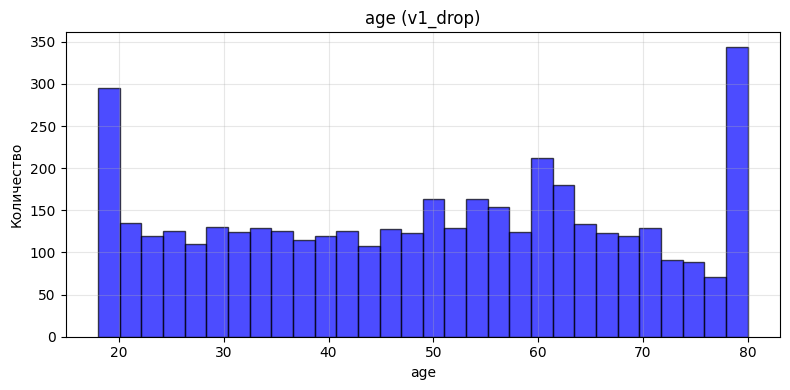


=== gender ===
count    4238.000000
mean        0.516045
std         0.499801
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: gender, dtype: float64


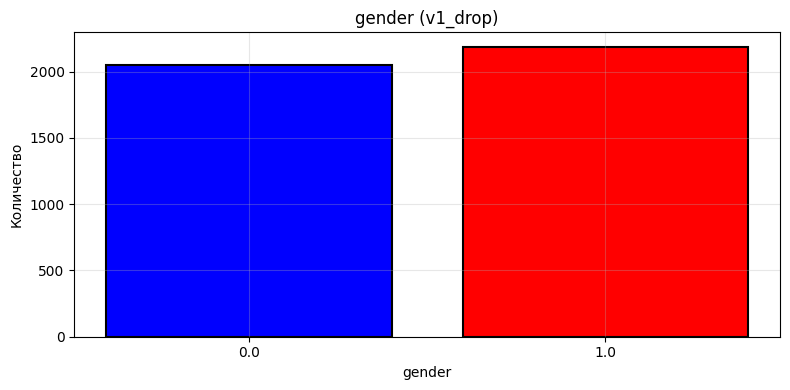


=== income_ratio ===
count    4.238000e+03
mean     2.577419e+00
std      1.533911e+00
min      5.397605e-79
25%      1.390000e+00
50%      2.160000e+00
75%      3.920000e+00
max      5.000000e+00
Name: income_ratio, dtype: float64


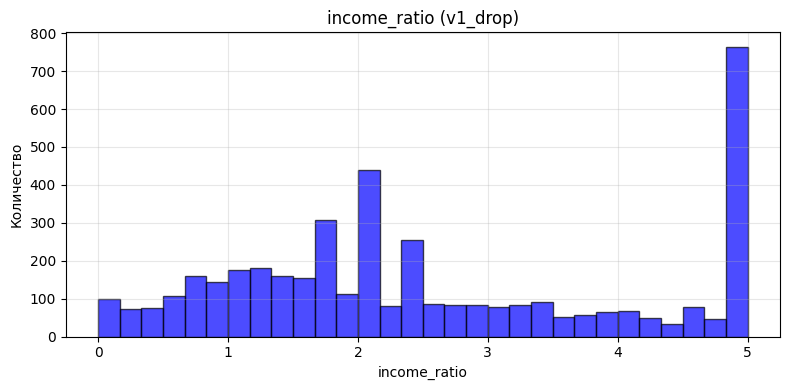


=== race_asian ===
count    4238.000000
mean        0.151723
std         0.358794
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: race_asian, dtype: float64


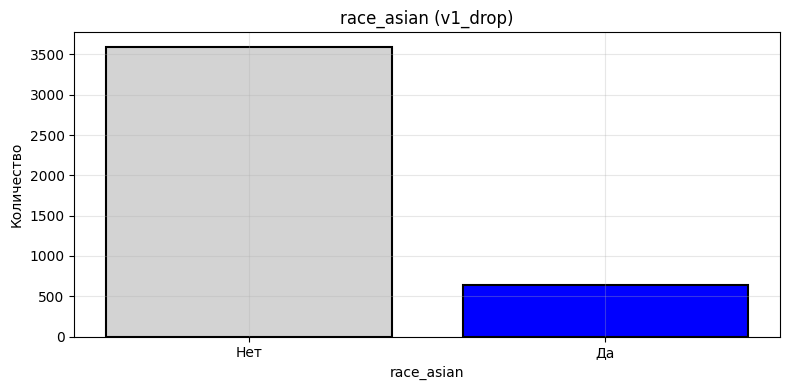


=== race_black ===
count    4238.000000
mean        0.214488
std         0.410515
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: race_black, dtype: float64


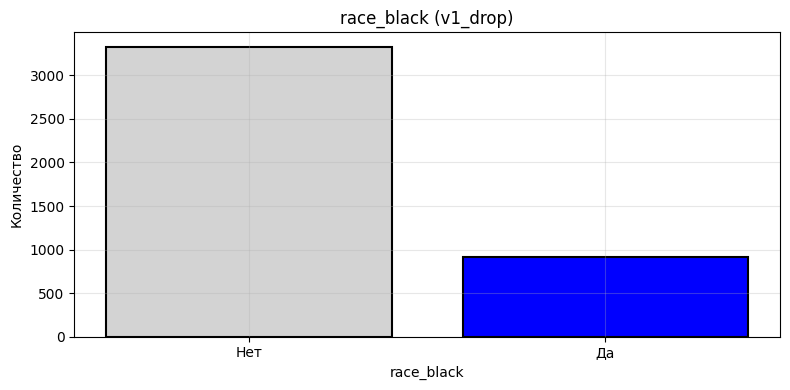


=== race_latino ===
count    4238.000000
mean        0.227230
std         0.419092
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: race_latino, dtype: float64


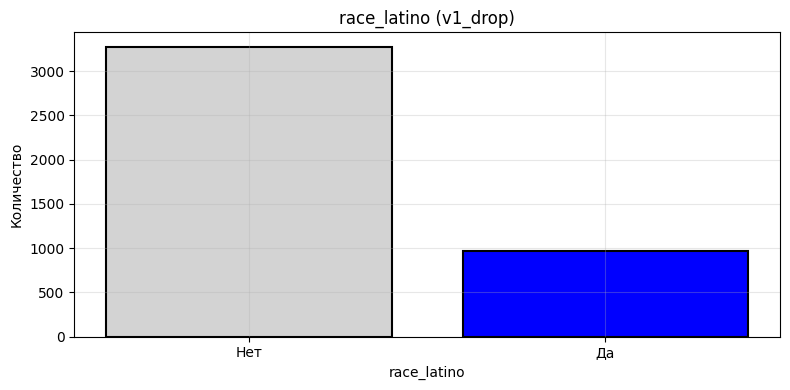


=== race_white ===
count    4238.000000
mean        0.357008
std         0.479174
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: race_white, dtype: float64


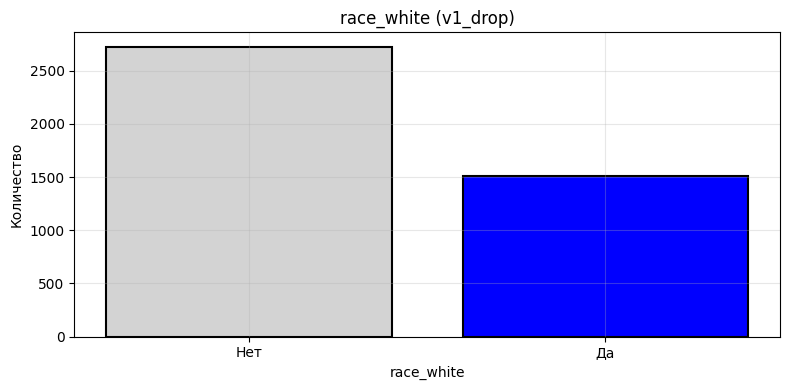


=== race_other ===
count    4238.000000
mean        0.049552
std         0.217042
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: race_other, dtype: float64


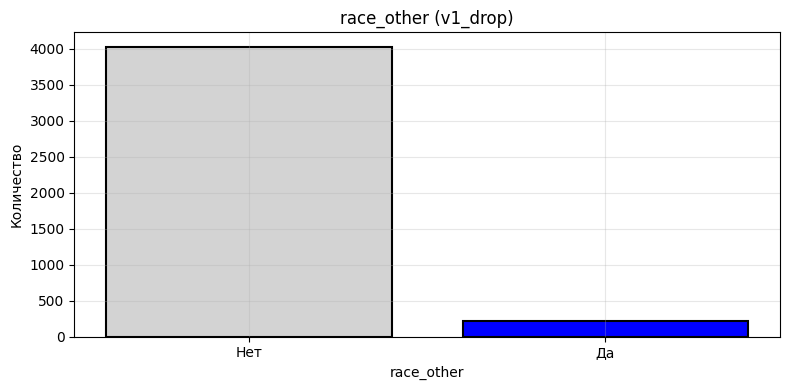


=== teeth_total ===
count    4238.000000
mean       22.364559
std         8.347817
min         0.000000
25%        21.000000
50%        26.000000
75%        28.000000
max        28.000000
Name: teeth_total, dtype: float64


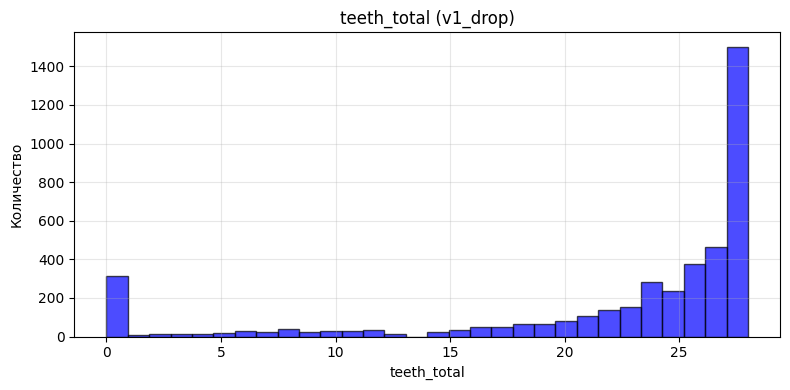


=== carious_count ===
count    4238.000000
mean        0.504483
std         1.775147
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        22.000000
Name: carious_count, dtype: float64


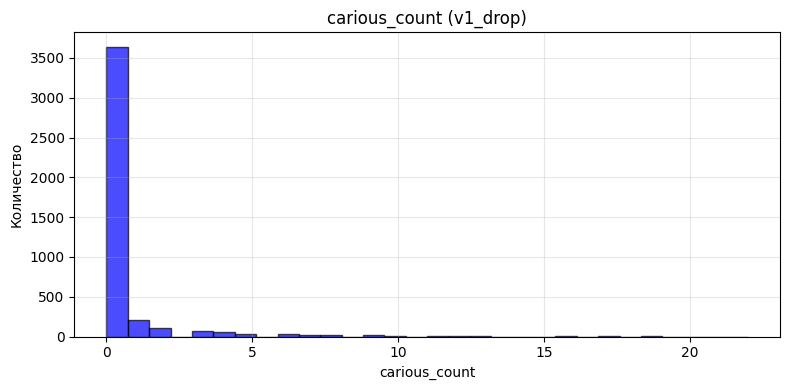


=== teeth_missing ===
count    4238.000000
mean        5.436999
std         8.326230
min         0.000000
25%         0.000000
50%         2.000000
75%         6.000000
max        28.000000
Name: teeth_missing, dtype: float64


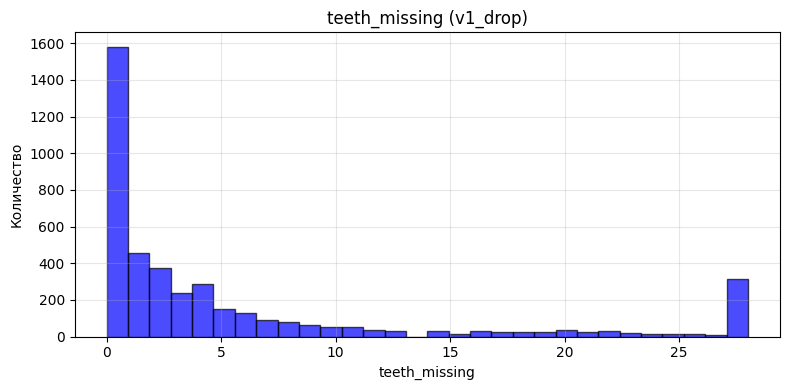


=== teeth_filled ===
count    4238.000000
mean        5.370930
std         5.145761
min         0.000000
25%         0.000000
50%         4.000000
75%         9.000000
max        26.000000
Name: teeth_filled, dtype: float64


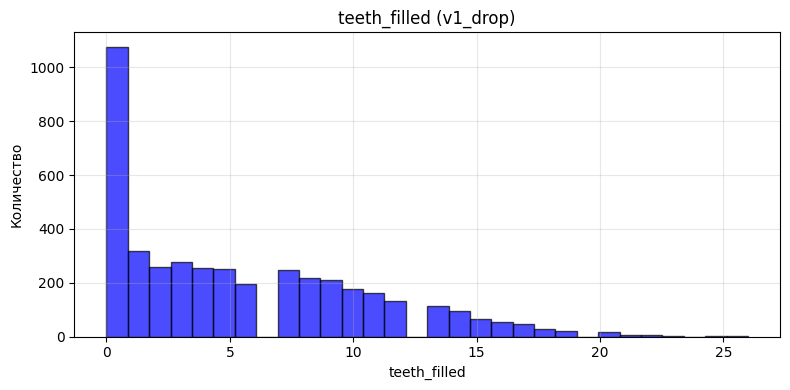


=== dmft ===
count    4238.000000
mean       11.312412
std         8.451536
min         0.000000
25%         4.000000
50%        10.000000
75%        17.000000
max        28.000000
Name: dmft, dtype: float64


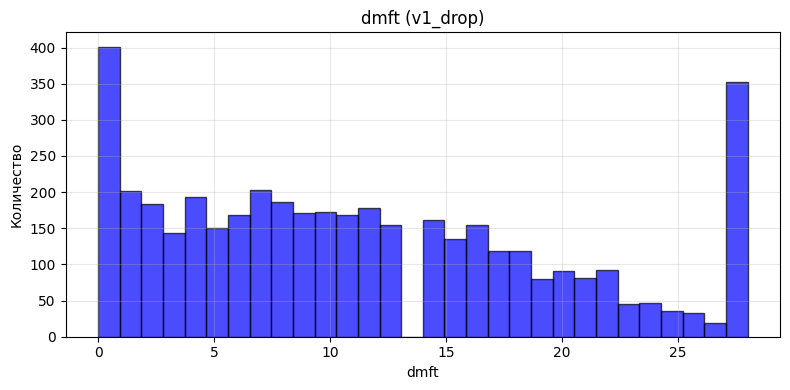


=== bmi ===
count    4238.000000
mean       29.570340
std         7.336977
min        14.200000
25%        24.600000
50%        28.300000
75%        33.200000
max        86.200000
Name: bmi, dtype: float64


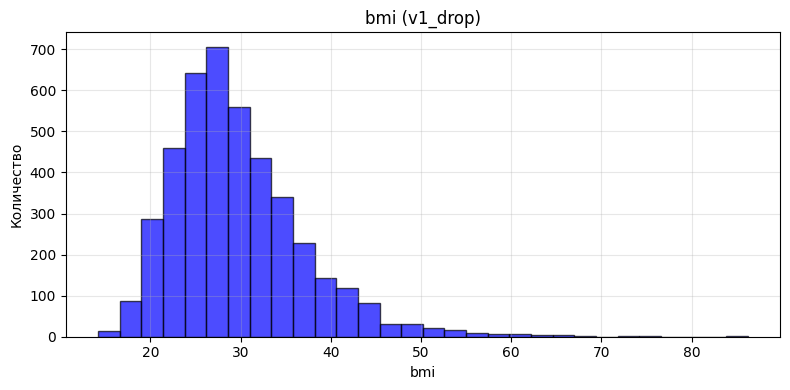


=== diabetes ===
count    4238.000000
mean        0.417650
std         0.725274
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         2.000000
Name: diabetes, dtype: float64


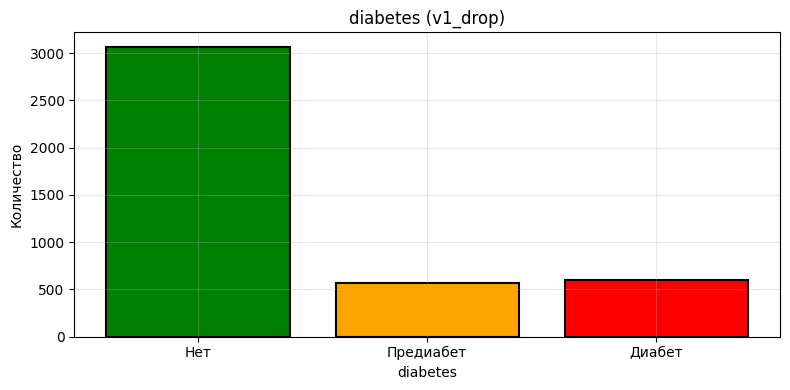


=== asthma ===
count    4238.000000
mean        0.150307
std         0.357414
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: asthma, dtype: float64


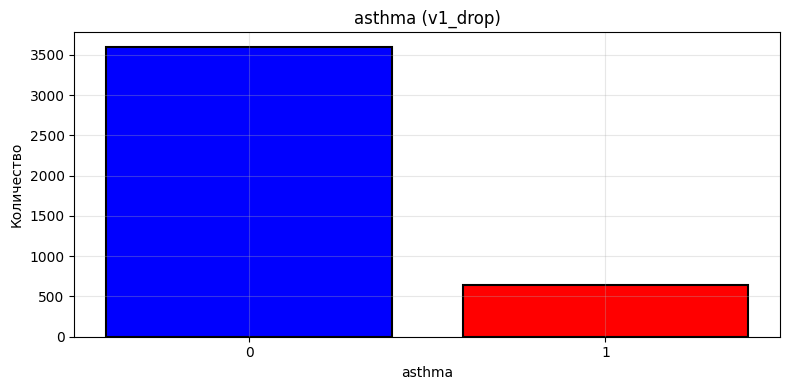


=== depression ===
count    4238.000000
mean        0.214016
std         0.548108
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         2.000000
Name: depression, dtype: float64


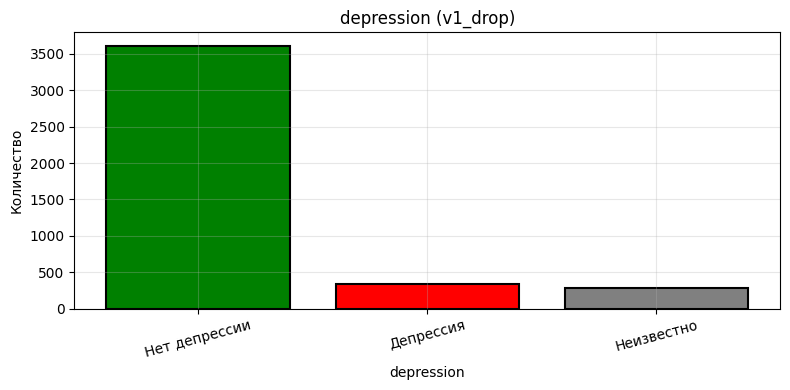


=== sugar_avg ===
count    4238.000000
mean       99.108252
std        62.187754
min         2.290000
25%        58.515000
50%        87.282500
75%       122.021250
max       892.645000
Name: sugar_avg, dtype: float64


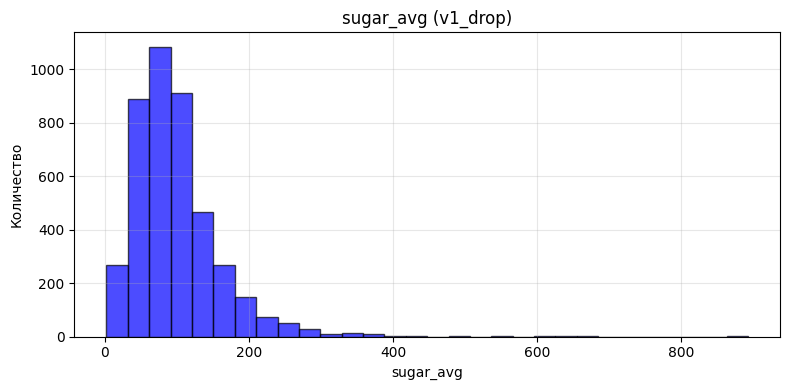


=== smoking_status ===
count    4238.000000
mean        0.159037
std         0.365754
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: smoking_status, dtype: float64


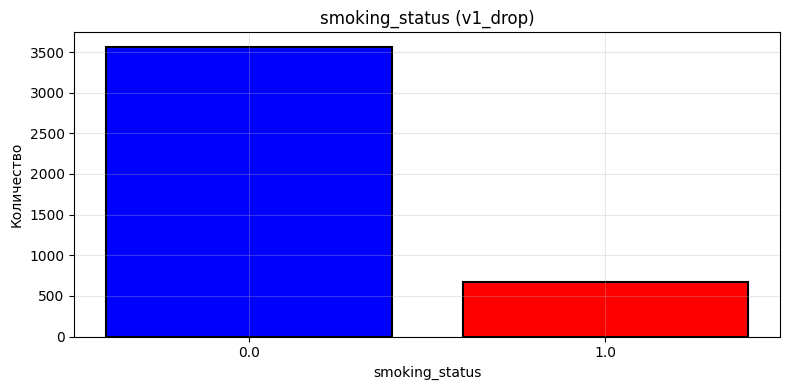


=== poor_hygiene ===
count    4238.000000
mean        0.274894
std         0.446513
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: poor_hygiene, dtype: float64


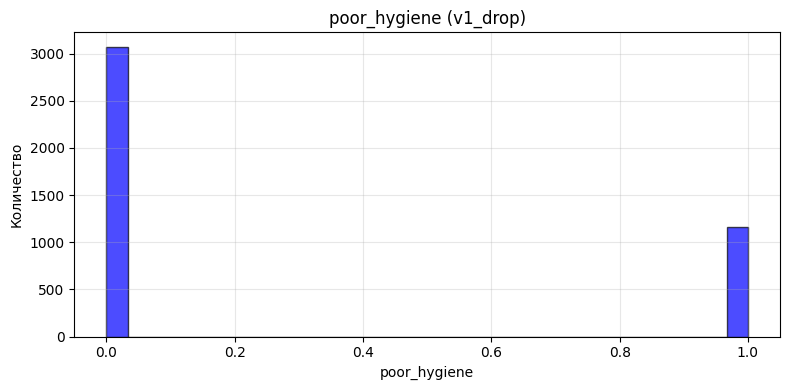


 АНАЛИЗ ДАТАСЕТА: v2_3cat

=== age ===
count    5533.000000
mean       49.816555
std        18.649364
min        18.000000
25%        33.000000
50%        51.000000
75%        65.000000
max        80.000000
Name: age, dtype: float64


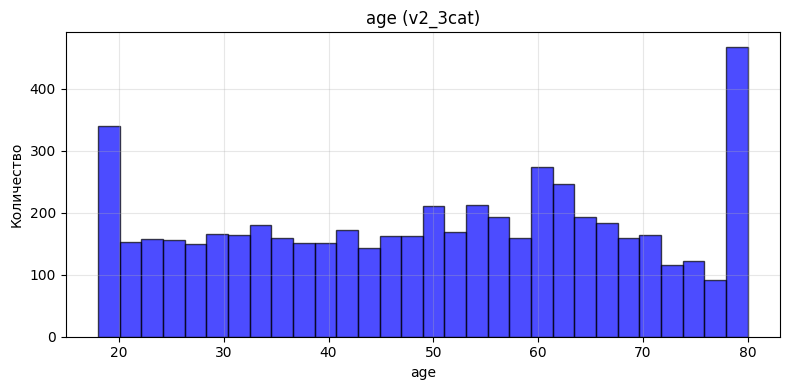


=== gender ===
count    5533.000000
mean        0.517079
std         0.499753
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: gender, dtype: float64


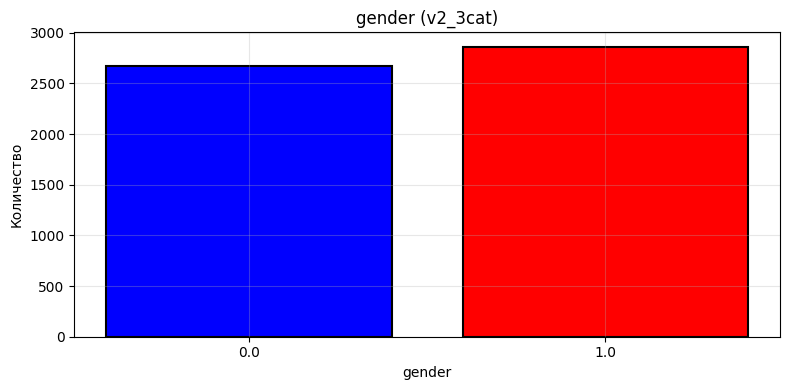


=== income_ratio ===
count    5.533000e+03
mean     2.467999e+00
std      1.506751e+00
min      5.397605e-79
25%      1.270000e+00
50%      2.160000e+00
75%      3.650000e+00
max      5.000000e+00
Name: income_ratio, dtype: float64


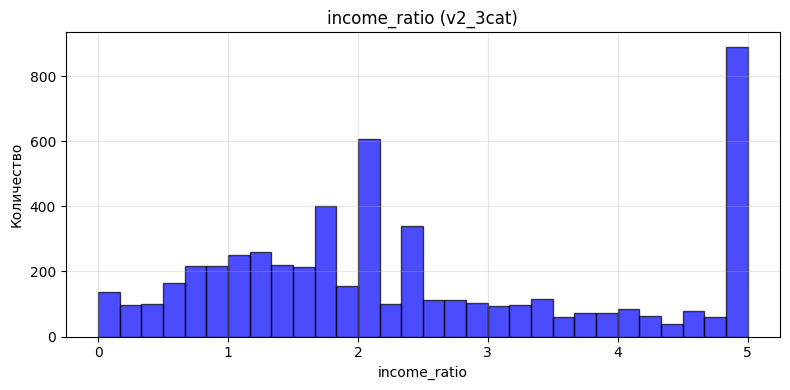


=== race_asian ===
count    5533.000000
mean        0.143322
std         0.350432
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: race_asian, dtype: float64


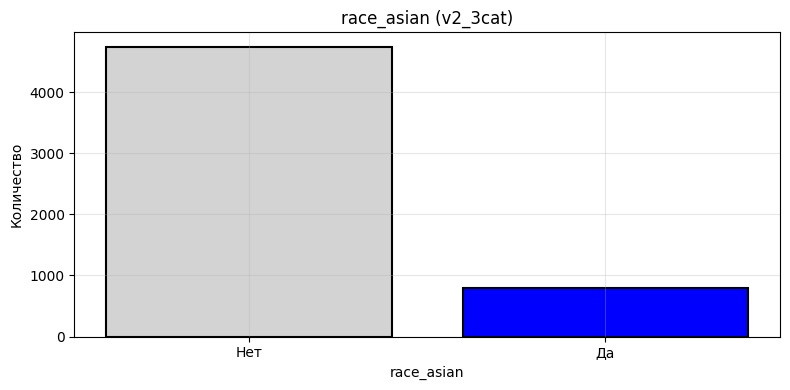


=== race_black ===
count    5533.000000
mean        0.231881
std         0.422072
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: race_black, dtype: float64


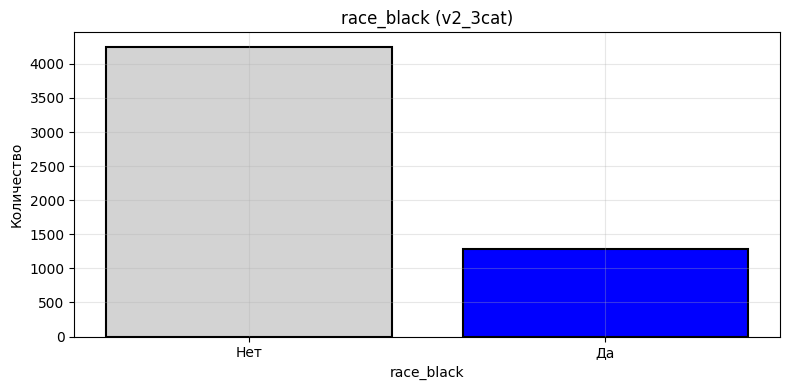


=== race_latino ===
count    5533.000000
mean        0.229713
std         0.420686
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: race_latino, dtype: float64


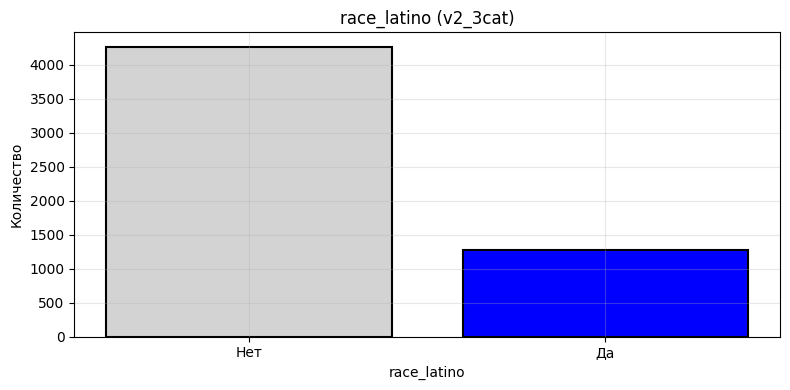


=== race_white ===
count    5533.000000
mean        0.343033
std         0.474765
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: race_white, dtype: float64


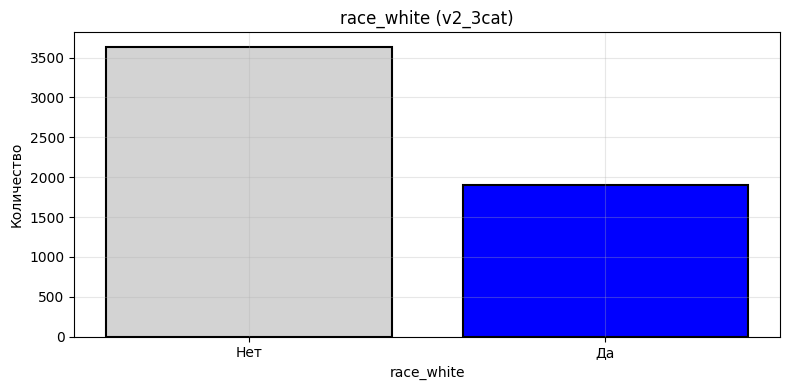


=== race_other ===
count    5533.000000
mean        0.052051
std         0.222151
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: race_other, dtype: float64


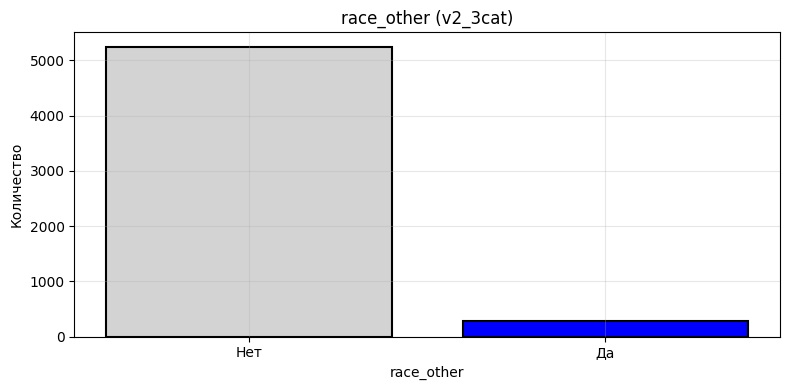


=== teeth_total ===
count    5533.000000
mean       21.094524
std         9.338996
min         0.000000
25%        19.000000
50%        26.000000
75%        28.000000
max        28.000000
Name: teeth_total, dtype: float64


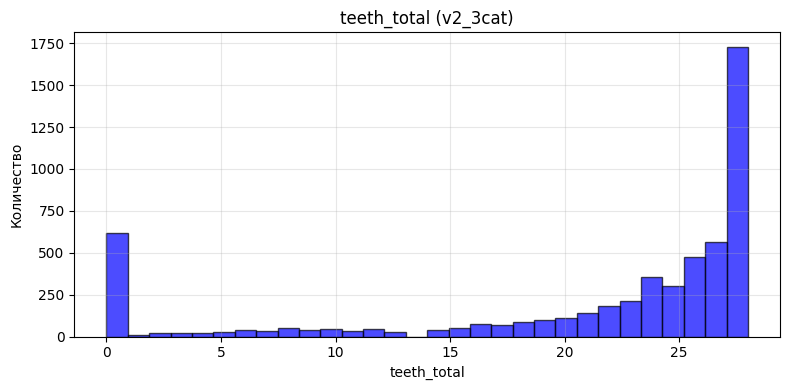


=== carious_count ===
count    5533.000000
mean        0.772998
std         2.128674
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        25.000000
Name: carious_count, dtype: float64


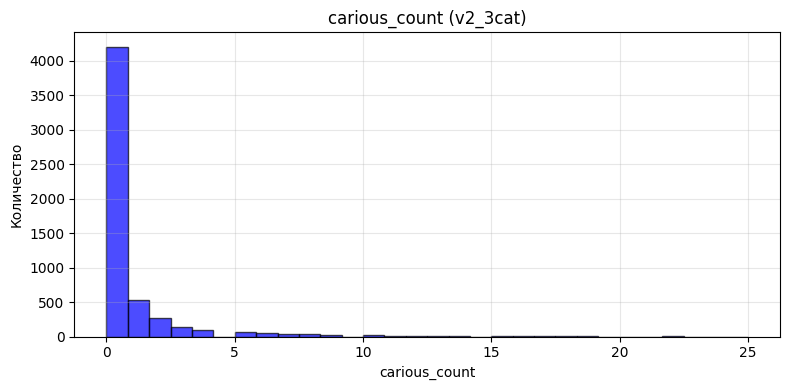


=== teeth_missing ===
count    5533.000000
mean        5.617929
std         8.370103
min         0.000000
25%         0.000000
50%         2.000000
75%         7.000000
max        28.000000
Name: teeth_missing, dtype: float64


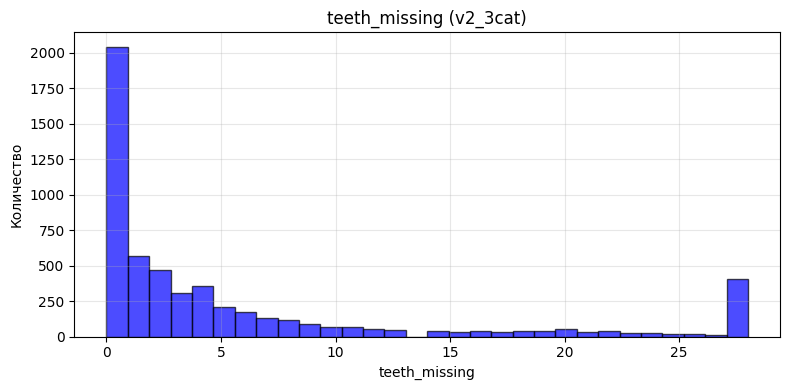


=== teeth_filled ===
count    5533.000000
mean        4.952467
std         5.046825
min         0.000000
25%         0.000000
50%         4.000000
75%         8.000000
max        26.000000
Name: teeth_filled, dtype: float64


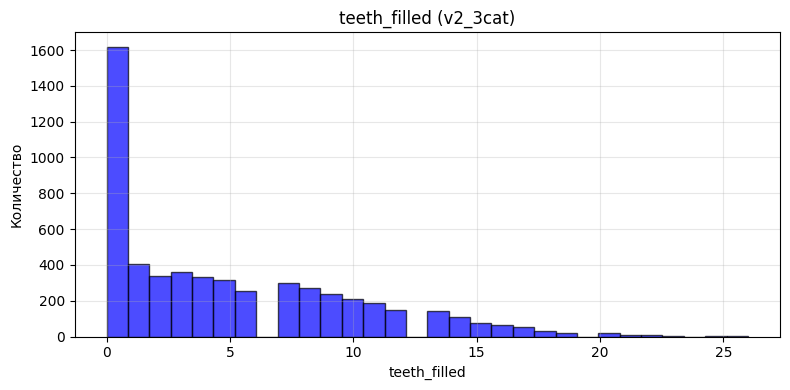


=== dmft ===
count    5533.000000
mean       11.343394
std         8.614794
min         0.000000
25%         4.000000
50%        10.000000
75%        17.000000
max        28.000000
Name: dmft, dtype: float64


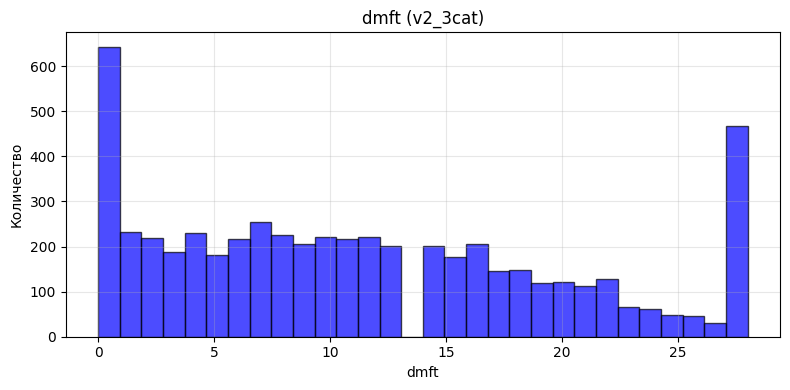


=== bmi ===
count    5533.000000
mean       29.673866
std         7.385523
min        14.200000
25%        24.600000
50%        28.400000
75%        33.400000
max        86.200000
Name: bmi, dtype: float64


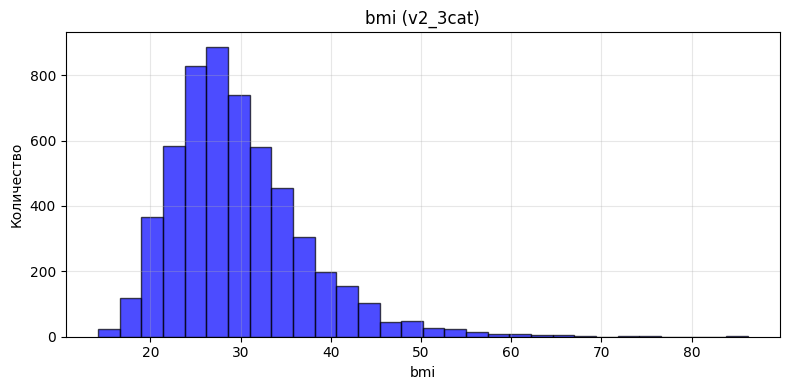


=== diabetes ===
count    5533.000000
mean        0.433400
std         0.740657
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         2.000000
Name: diabetes, dtype: float64


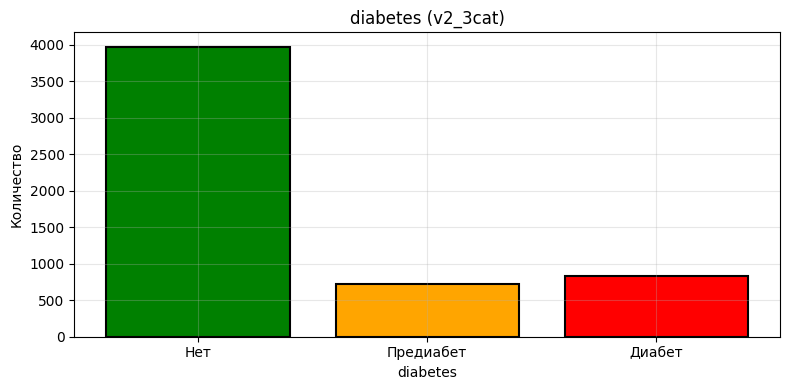


=== asthma ===
count    5533.000000
mean        0.152359
std         0.359401
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: asthma, dtype: float64


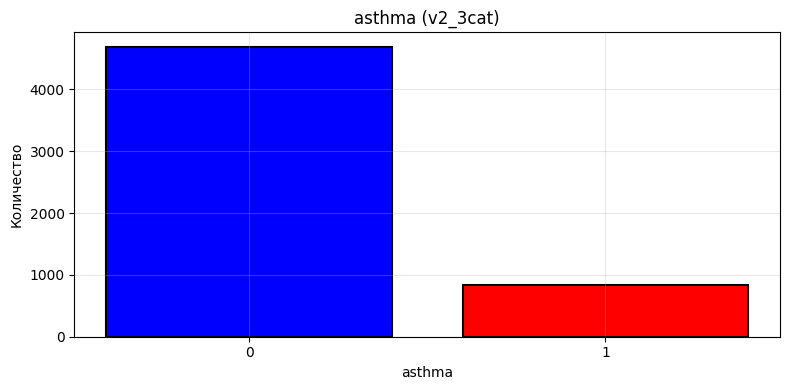


=== depression ===
count    5533.000000
mean        0.244171
std         0.587765
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         2.000000
Name: depression, dtype: float64


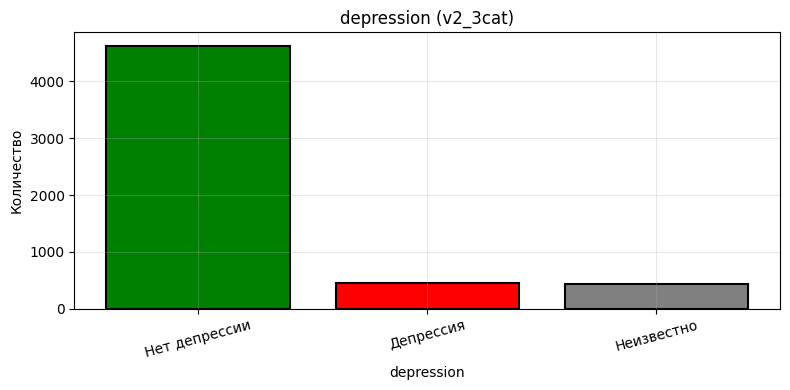


=== sugar_avg ===
count    5533.000000
mean       99.984969
std        62.892666
min         0.980000
25%        59.050000
50%        87.480000
75%       123.500000
max       892.645000
Name: sugar_avg, dtype: float64


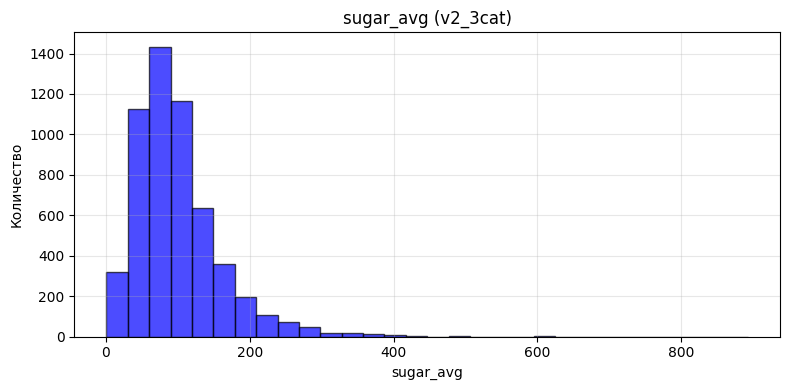


=== smoking_status ===
count    5533.000000
mean        0.175673
std         0.380576
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: smoking_status, dtype: float64


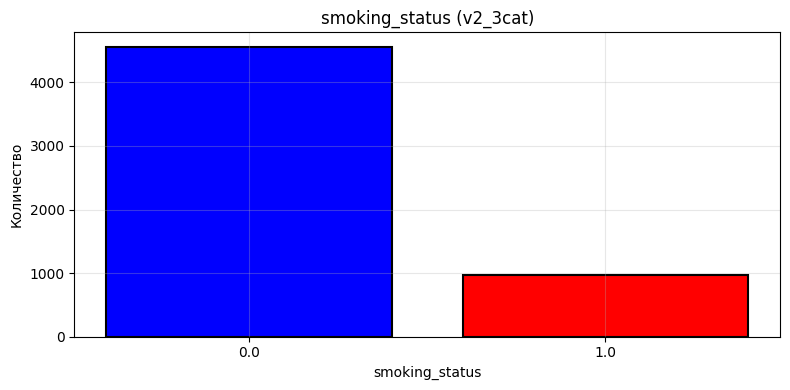


=== poor_hygiene ===
count    5533.000000
mean        0.678655
std         0.828436
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         2.000000
Name: poor_hygiene, dtype: float64


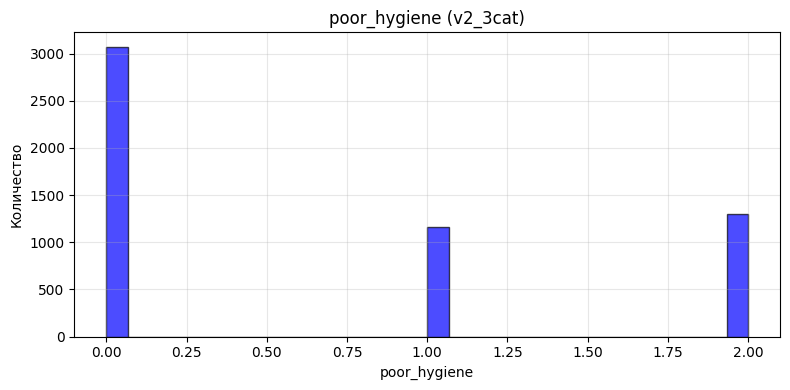


 АНАЛИЗ ДАТАСЕТА: v3_ml

=== age ===
count    5533.000000
mean       49.816555
std        18.649364
min        18.000000
25%        33.000000
50%        51.000000
75%        65.000000
max        80.000000
Name: age, dtype: float64


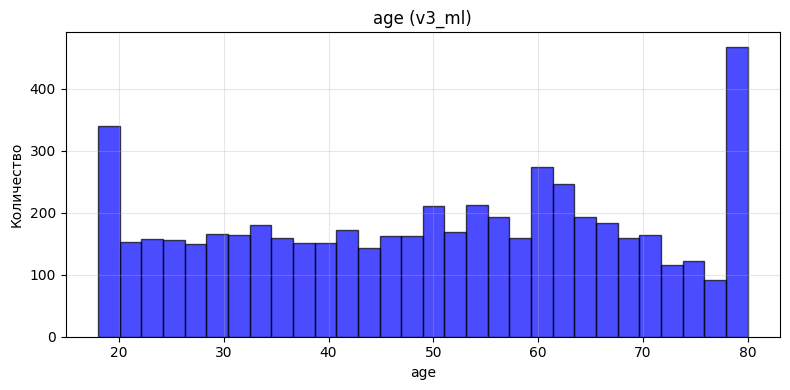


=== gender ===
count    5533.000000
mean        0.517079
std         0.499753
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: gender, dtype: float64


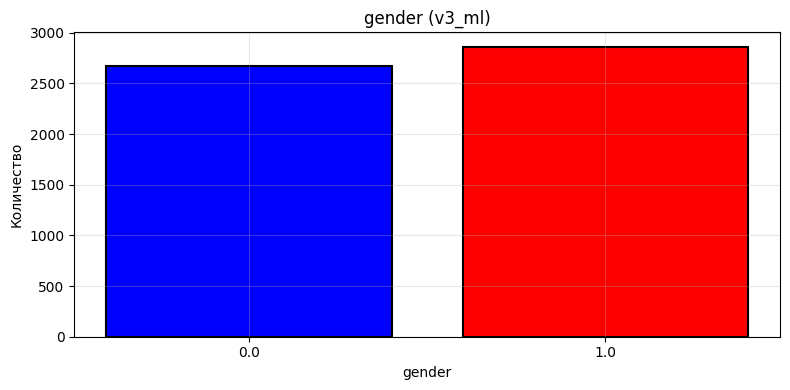


=== income_ratio ===
count    5.533000e+03
mean     2.467999e+00
std      1.506751e+00
min      5.397605e-79
25%      1.270000e+00
50%      2.160000e+00
75%      3.650000e+00
max      5.000000e+00
Name: income_ratio, dtype: float64


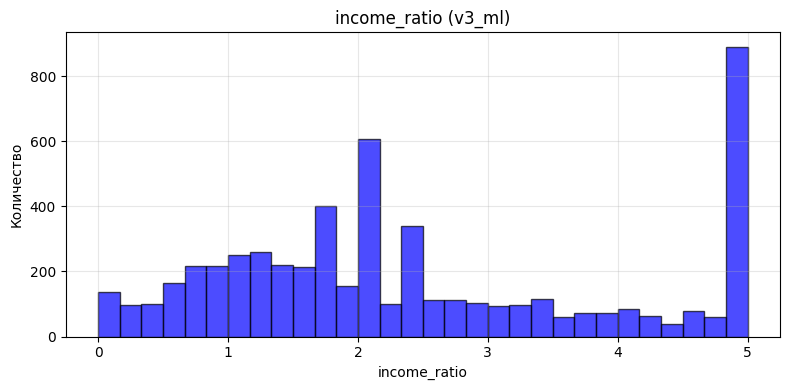


=== race_asian ===
count    5533.000000
mean        0.143322
std         0.350432
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: race_asian, dtype: float64


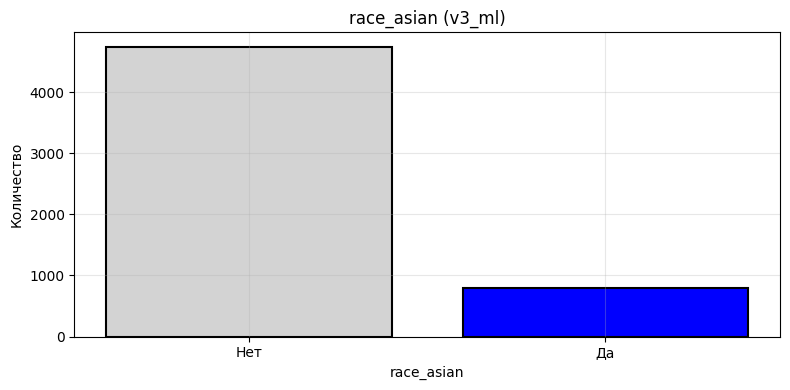


=== race_black ===
count    5533.000000
mean        0.231881
std         0.422072
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: race_black, dtype: float64


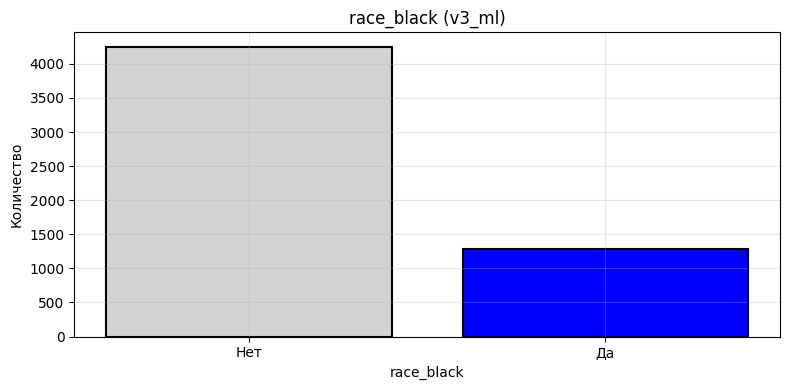


=== race_latino ===
count    5533.000000
mean        0.229713
std         0.420686
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: race_latino, dtype: float64


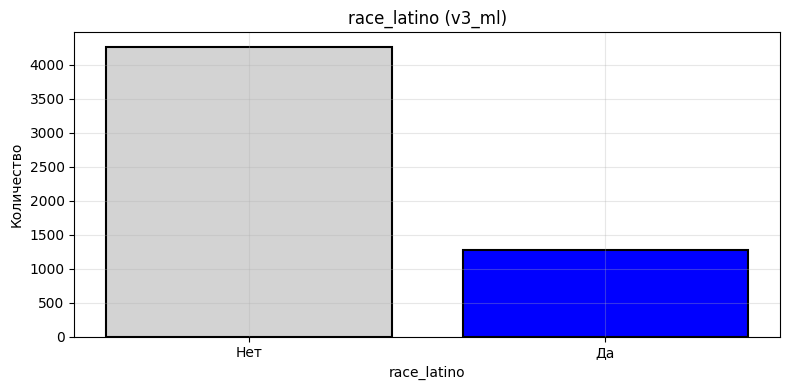


=== race_white ===
count    5533.000000
mean        0.343033
std         0.474765
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: race_white, dtype: float64


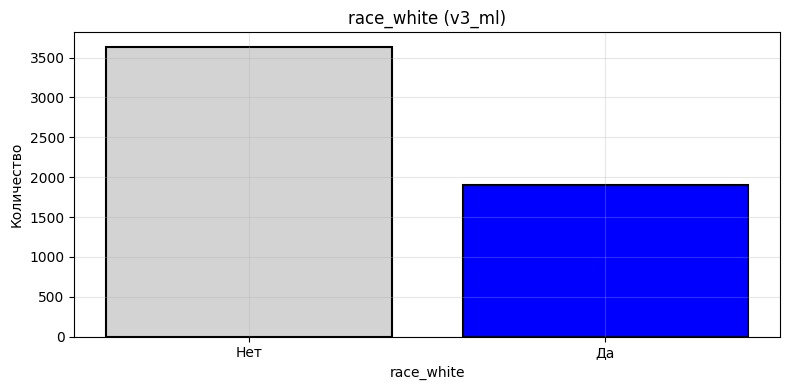


=== race_other ===
count    5533.000000
mean        0.052051
std         0.222151
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: race_other, dtype: float64


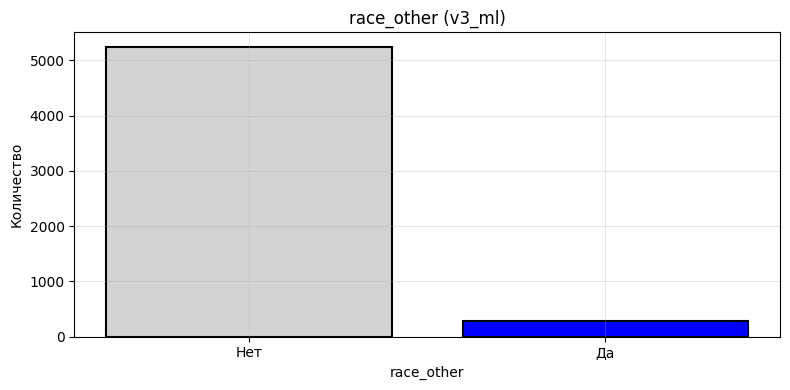


=== teeth_total ===
count    5533.000000
mean       21.094524
std         9.338996
min         0.000000
25%        19.000000
50%        26.000000
75%        28.000000
max        28.000000
Name: teeth_total, dtype: float64


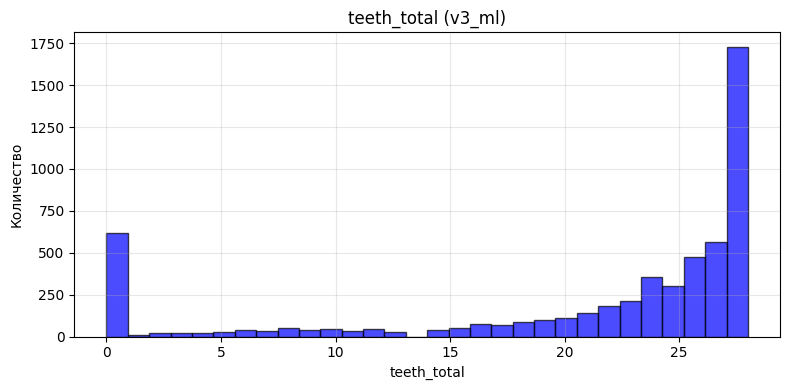


=== carious_count ===
count    5533.000000
mean        0.772998
std         2.128674
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        25.000000
Name: carious_count, dtype: float64


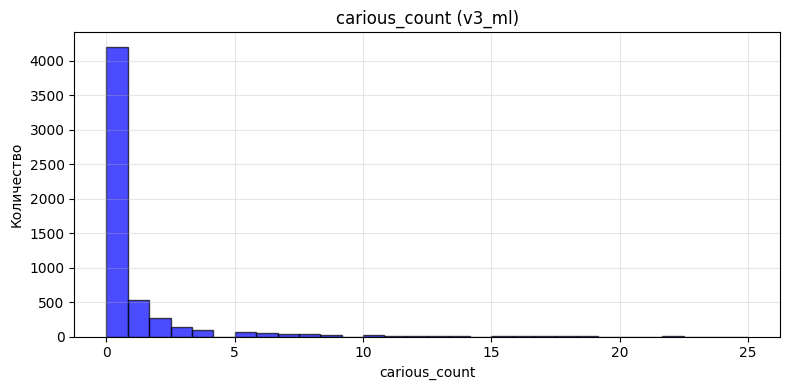


=== teeth_missing ===
count    5533.000000
mean        5.617929
std         8.370103
min         0.000000
25%         0.000000
50%         2.000000
75%         7.000000
max        28.000000
Name: teeth_missing, dtype: float64


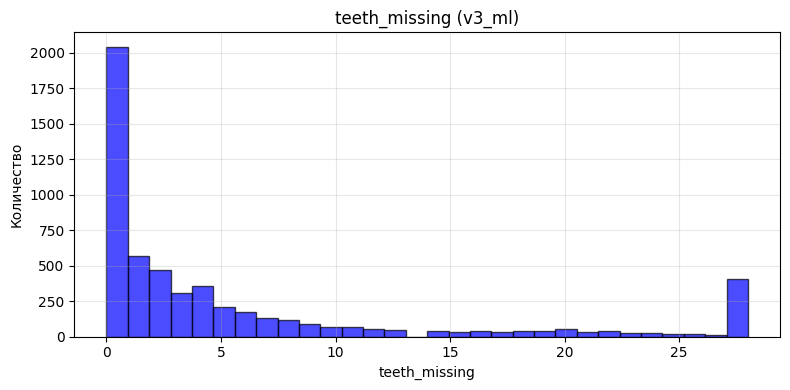


=== teeth_filled ===
count    5533.000000
mean        4.952467
std         5.046825
min         0.000000
25%         0.000000
50%         4.000000
75%         8.000000
max        26.000000
Name: teeth_filled, dtype: float64


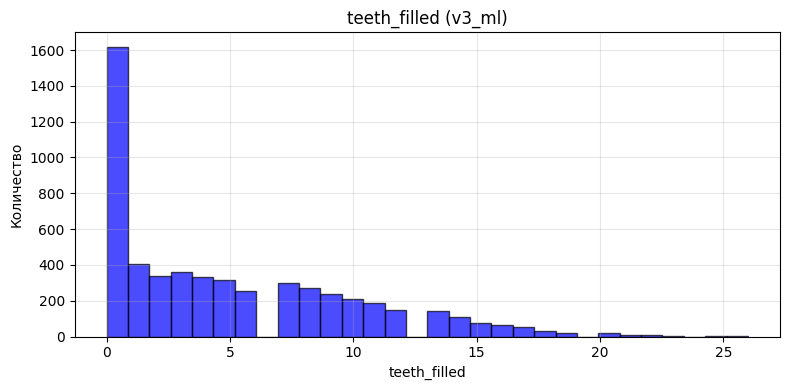


=== dmft ===
count    5533.000000
mean       11.343394
std         8.614794
min         0.000000
25%         4.000000
50%        10.000000
75%        17.000000
max        28.000000
Name: dmft, dtype: float64


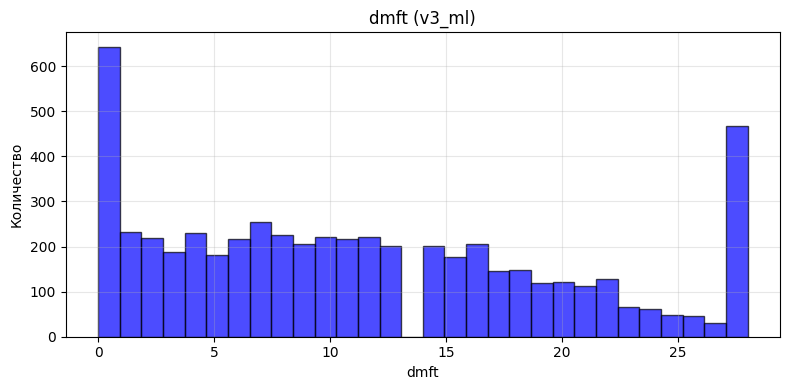


=== bmi ===
count    5533.000000
mean       29.673866
std         7.385523
min        14.200000
25%        24.600000
50%        28.400000
75%        33.400000
max        86.200000
Name: bmi, dtype: float64


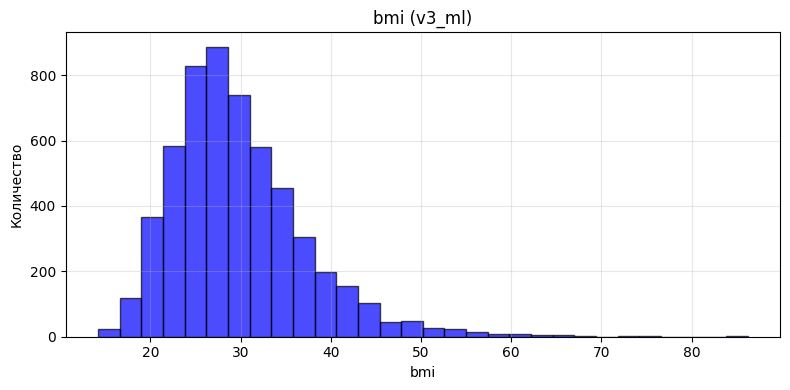


=== diabetes ===
count    5533.000000
mean        0.433400
std         0.740657
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         2.000000
Name: diabetes, dtype: float64


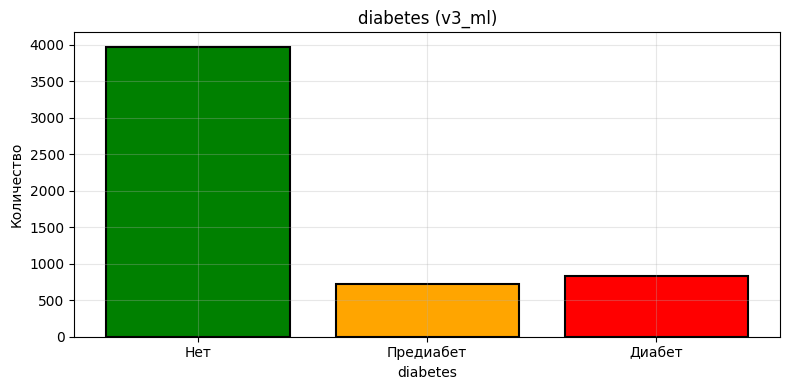


=== asthma ===
count    5533.000000
mean        0.152359
std         0.359401
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: asthma, dtype: float64


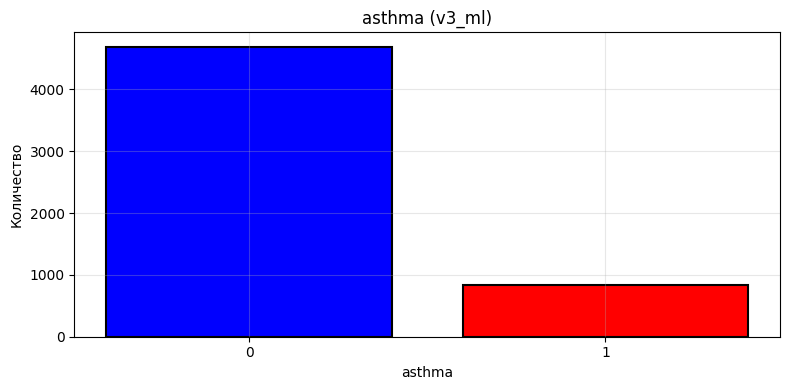


=== depression ===
count    5533.000000
mean        0.244171
std         0.587765
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         2.000000
Name: depression, dtype: float64


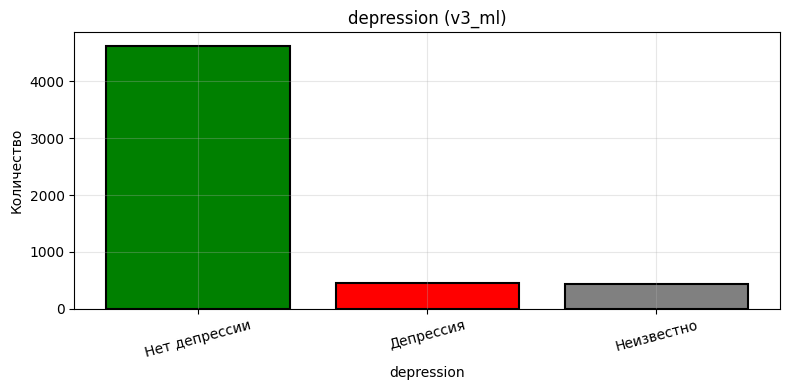


=== sugar_avg ===
count    5533.000000
mean       99.984969
std        62.892666
min         0.980000
25%        59.050000
50%        87.480000
75%       123.500000
max       892.645000
Name: sugar_avg, dtype: float64


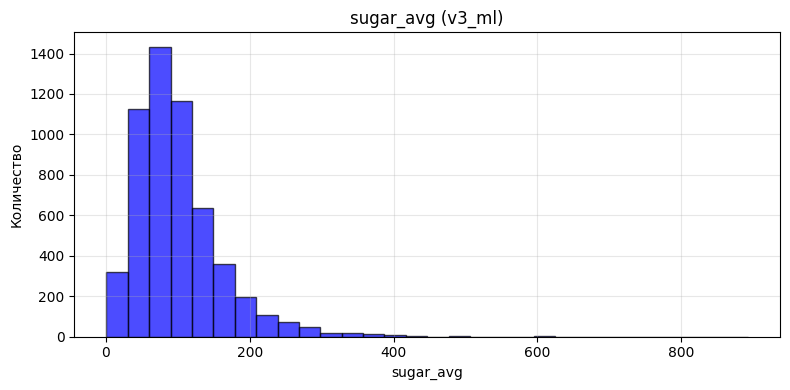


=== smoking_status ===
count    5533.000000
mean        0.175673
std         0.380576
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: smoking_status, dtype: float64


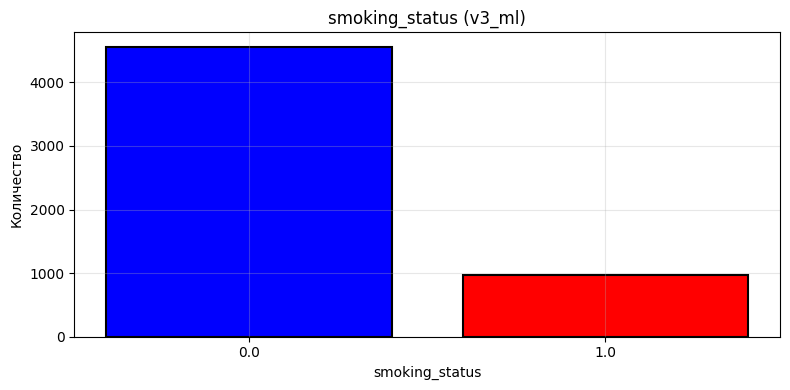


=== poor_hygiene ===
count    5533.000000
mean        0.219772
std         0.414130
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: poor_hygiene, dtype: float64


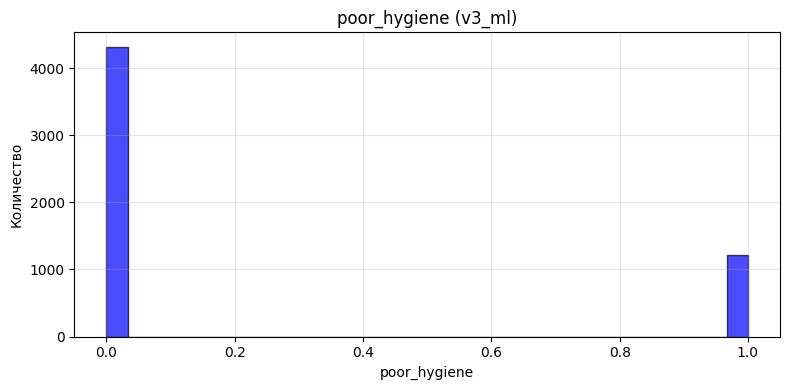

In [16]:
# ============================================================================
# ЭТАП 1.15: АНАЛИЗ ВСЕХ ТРЁХ ДАТАСЕТОВ 
# ============================================================================
# Цель: визуализация распределения всех признаков
# ============================================================================

print("\n" + "="*80)
print("1.15: АНАЛИЗ ВСЕХ ТРЁХ ДАТАСЕТОВ")
print("="*80)

datasets = {
    'v1_drop': pd.read_csv('../data/processed/dataset_v1_drop.csv'),
    'v2_3cat': pd.read_csv('../data/processed/dataset_v2_3cat.csv'),
    'v3_ml': pd.read_csv('../data/processed/dataset_v3_ml.csv')
} 

# Признаки для анализа
features = ['age', 'gender', 'income_ratio', 
            'race_asian', 'race_black', 'race_latino', 'race_white', 'race_other',
            'teeth_total', 'carious_count', 'teeth_missing', 'teeth_filled', 'dmft', 'risk_class',
            'bmi', 'diabetes', 'asthma', 'depression',
            'sugar_avg', 'smoking_status', 'poor_hygiene']

# Проходим по каждому датасету
for name, dataset in datasets.items():
    print("\n" + "="*80)
    print(f" АНАЛИЗ ДАТАСЕТА: {name}")
    print("="*80)
    
    for feature in features:
        if feature not in dataset.columns:
            continue
            
        print(f"\n=== {feature} ===")
        print(dataset[feature].describe())
        
        # Гистограмма
        plt.figure(figsize=(8, 4))
        
        # Для бинарных признаков - столбчатая диаграмма
        if feature in ['gender', 'asthma', 'smoking_status', 'active_caries']:
            counts = dataset[feature].value_counts().sort_index()
            plt.bar(counts.index.astype(str), counts.values, 
                   color=['blue', 'red'], edgecolor='black', linewidth=1.5)
            plt.xlabel(feature)
            
        # Для диабета (теперь 0,1,2)
        elif feature == 'diabetes':
            counts = dataset[feature].value_counts().sort_index()
            labels = {0: 'Нет', 1: 'Предиабет', 2: 'Диабет'}
            colors = ['green', 'orange', 'red']
            bars = plt.bar([labels.get(i, str(i)) for i in counts.index], counts.values,
                          color=colors[:len(counts)], edgecolor='black', linewidth=1.5)
            plt.xlabel('diabetes')

        # Для депрессии (теперь 0,1,2 где 2 = неизвестно)
        elif feature == 'depression':
            counts = dataset[feature].value_counts().sort_index()
            labels = {0: 'Нет депрессии', 1: 'Депрессия', 2: 'Неизвестно'}
            colors = ['green', 'red', 'gray']
            bars = plt.bar([labels.get(i, str(i)) for i in counts.index], counts.values,
                          color=colors[:len(counts)], edgecolor='black', linewidth=1.5)
            plt.xlabel('depression')
            plt.xticks(rotation=15)

        # Для рас (бинарные)
        elif feature.startswith('race_'):
            counts = dataset[feature].value_counts().sort_index()
            plt.bar(['Нет', 'Да'], counts.values, 
                   color=['lightgray', 'blue'], edgecolor='black', linewidth=1.5)
            plt.xlabel(feature)
            
        # Для всех остальных - гистограмма
        else:
            plt.hist(dataset[feature], bins=30, color='blue', alpha=0.7, 
                    edgecolor='black', linewidth=1)
            plt.xlabel(feature)
        
        plt.ylabel('Количество')
        plt.title(f'{feature} ({name})')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

1.16: ОБРЕЗАНИЕ ВЫБРОСОВ И ВИЗУАЛИЗАЦИЯ

v1_drop:
   Сахар: 892.6 → 300.0
   BMI: 86.2 → 55.0

v2_3cat:
   Сахар: 892.6 → 300.0
   BMI: 86.2 → 55.0

v3_ml:
   Сахар: 892.6 → 300.0
   BMI: 86.2 → 55.0


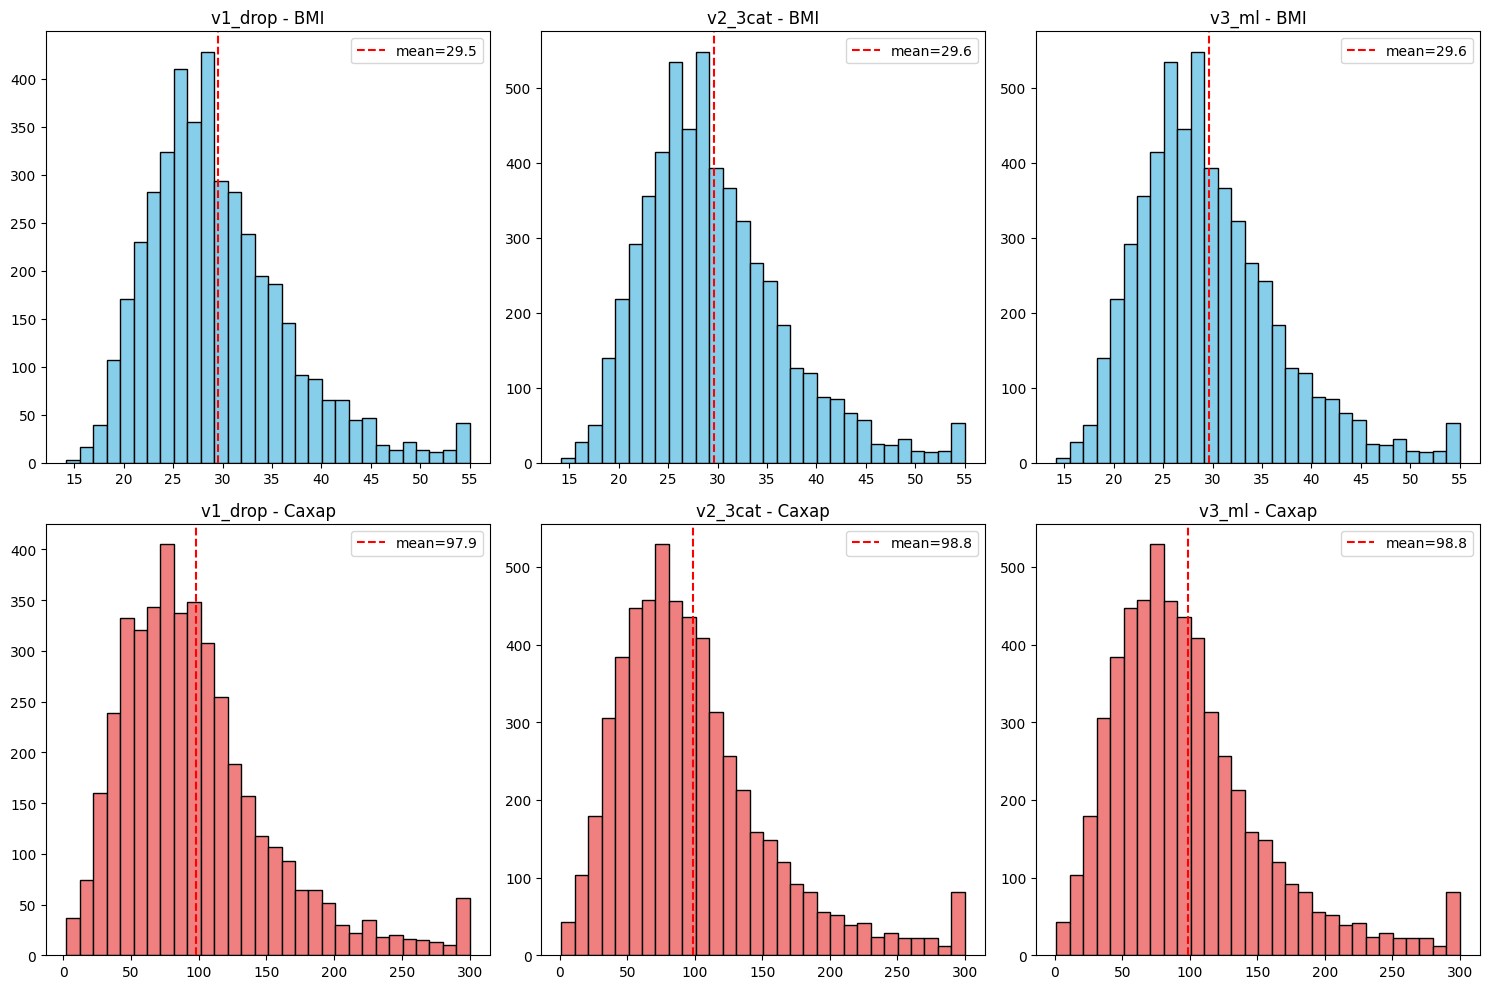


 Все датасеты сохранены!


In [17]:
# ============================================================================
# ЭТАП 1.16: ОБРЕЗАНИЕ ВЫБРОСОВ ДЛЯ ВСЕХ ДАТАСЕТОВ
# ============================================================================
print("="*80)
print("1.16: ОБРЕЗАНИЕ ВЫБРОСОВ И ВИЗУАЛИЗАЦИЯ")
print("="*80)

datasets = {
    'v1_drop': pd.read_csv('../data/processed/dataset_v1_drop.csv'),
    'v2_3cat': pd.read_csv('../data/processed/dataset_v2_3cat.csv'),
    'v3_ml': pd.read_csv('../data/processed/dataset_v3_ml.csv')
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, (name, df) in enumerate(datasets.items()):
    # Обрезаем
    before_sugar = df['sugar_avg'].max()
    df['sugar_avg'] = df['sugar_avg'].clip(upper=300)
    before_bmi = df['bmi'].max()
    df['bmi'] = df['bmi'].clip(upper=55)
    
    print(f"\n{name}:")
    print(f"   Сахар: {before_sugar:.1f} → {df['sugar_avg'].max():.1f}")
    print(f"   BMI: {before_bmi:.1f} → {df['bmi'].max():.1f}")
    
    # Сохраняем
    df.to_csv(f'../data/processed/dataset_{name}.csv', index=False)
    
    # Гистограмма BMI
    axes[0, idx].hist(df['bmi'], bins=30, color='skyblue', edgecolor='black')
    axes[0, idx].set_title(f'{name} - BMI')
    axes[0, idx].axvline(df['bmi'].mean(), color='red', linestyle='--', label=f'mean={df["bmi"].mean():.1f}')
    axes[0, idx].legend()
    
    # Гистограмма сахара
    axes[1, idx].hist(df['sugar_avg'], bins=30, color='lightcoral', edgecolor='black')
    axes[1, idx].set_title(f'{name} - Сахар')
    axes[1, idx].axvline(df['sugar_avg'].mean(), color='red', linestyle='--', label=f'mean={df["sugar_avg"].mean():.1f}')
    axes[1, idx].legend()

plt.tight_layout()
plt.savefig('../results/clustering/bmi_sugar_histograms_all.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Все датасеты сохранены!")

In [18]:
# ============================================================================
# ЭТАП 1.17: ИНФОРМАЦИЯ О ДАТАСЕТАХ (ТИПЫ ДАННЫХ, ПРОПУСКИ, ПАМЯТЬ)
# ============================================================================
# Цель: получение сводной информации о структуре каждого датасета (типы колонок, количество не-null значений, использование памяти)
# ============================================================================

print("\n" + "="*80)
print("1.17: ИНФОРМАЦИЯ О ДАТАСЕТАХ (ТИПЫ ДАННЫХ, ПРОПУСКИ, ПАМЯТЬ)")
print("="*80)

for name, dataset in datasets.items():
    print("\n" + "="*80)
    print(f" INFO ДАТАСЕТА: {name}")
    print("="*80)
    print(dataset.info())
    print("\n")


1.17: ИНФОРМАЦИЯ О ДАТАСЕТАХ (ТИПЫ ДАННЫХ, ПРОПУСКИ, ПАМЯТЬ)

 INFO ДАТАСЕТА: v1_drop
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               4238 non-null   float64
 1   age              4238 non-null   float64
 2   gender           4238 non-null   float64
 3   income_ratio     4238 non-null   float64
 4   race_asian       4238 non-null   int64  
 5   race_black       4238 non-null   int64  
 6   race_latino      4238 non-null   int64  
 7   race_other       4238 non-null   int64  
 8   race_white       4238 non-null   int64  
 9   age_group        4238 non-null   object 
 10  income_category  4238 non-null   object 
 11  teeth_total      4238 non-null   int64  
 12  carious_count    4238 non-null   int64  
 13  teeth_missing    4238 non-null   int64  
 14  teeth_filled     4238 non-null   int64  
 15  dmft             42


1.18: МАТРИЦА КОРРЕЛЯЦИЙ И АНАЛИЗ СВЯЗИ ФАКТОРОВ РИСКА
   Целевые переменные: DMFT и ACTIVE_CARIES

 МАТРИЦА КОРРЕЛЯЦИЙ: v1_drop

 АНАЛИЗ ДЛЯ DMFT:
   Анализируем 16 числовых признаков


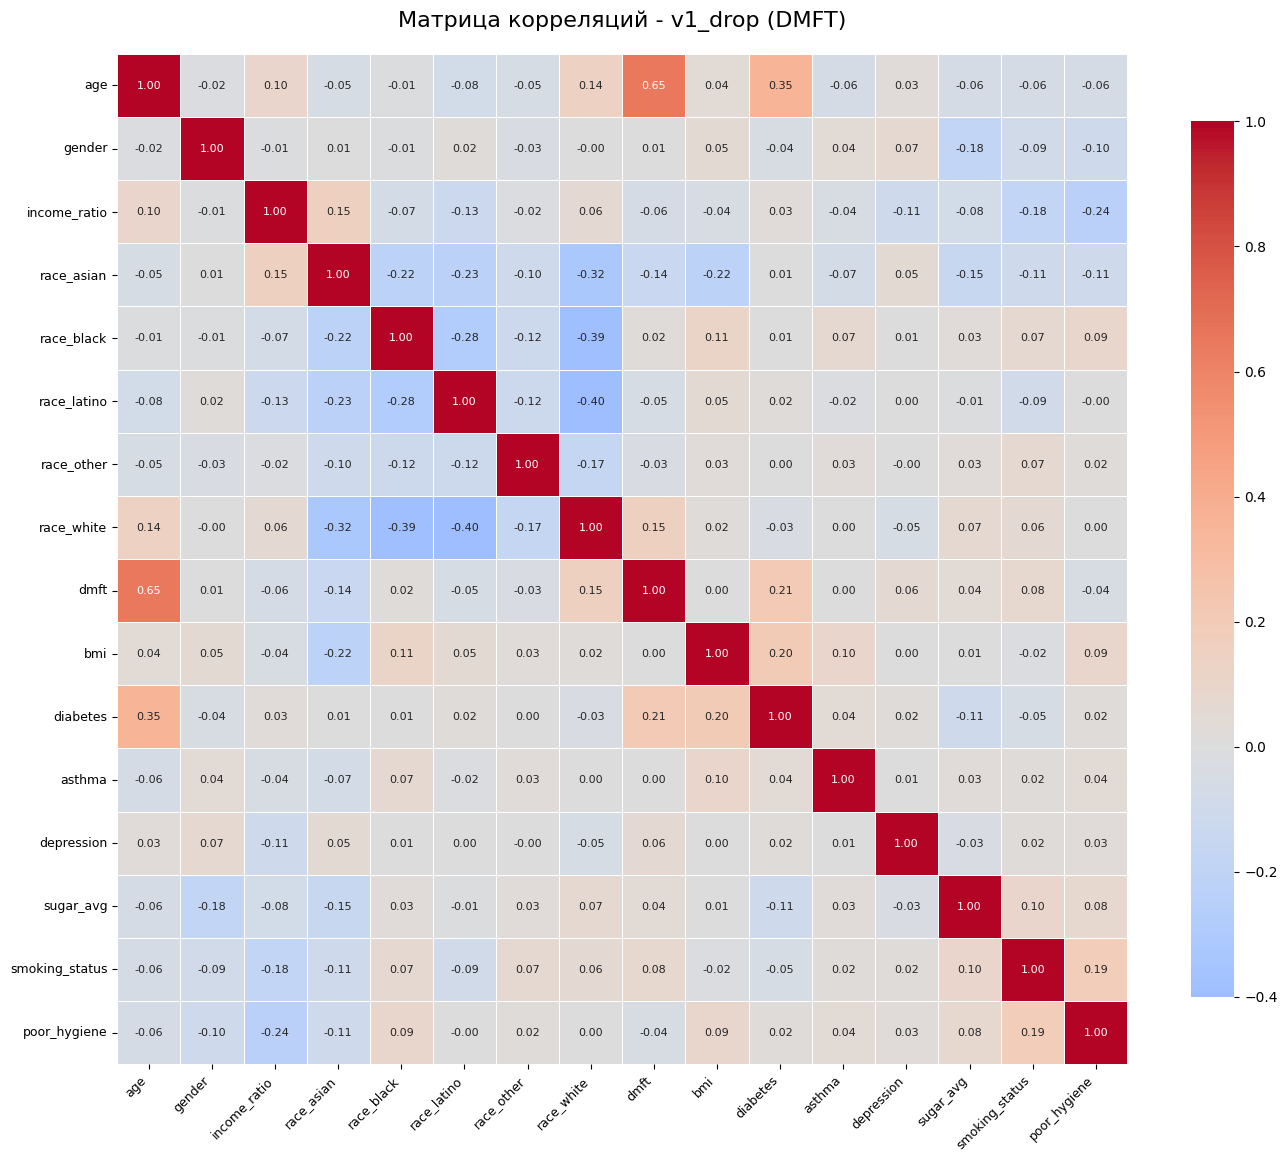


 КОРРЕЛЯЦИИ ФАКТОРОВ РИСКА С DMFT: v1_drop

 ПРИЗНАК                   |   КОРРЕЛЯЦИЯ | СИЛА        
-------------------------------------------------------
 age                       | +     0.6546 | сильная     
 diabetes                  | +     0.2142 | слабая      
 race_white                | +     0.1494 | очень слабая
 race_asian                | -     0.1402 | очень слабая
 smoking_status            | +     0.0796 | очень слабая
 income_ratio              | -     0.0601 | очень слабая
 depression                | +     0.0575 | очень слабая
 race_latino               | -     0.0534 | очень слабая
 sugar_avg                 | +     0.0375 | очень слабая
 poor_hygiene              | -     0.0375 | очень слабая
 race_other                | -     0.0321 | очень слабая
 race_black                | +     0.0197 | очень слабая
 gender                    | +     0.0128 | очень слабая
 asthma                    | +     0.0027 | очень слабая
 bmi                       | +     0.0025 | 

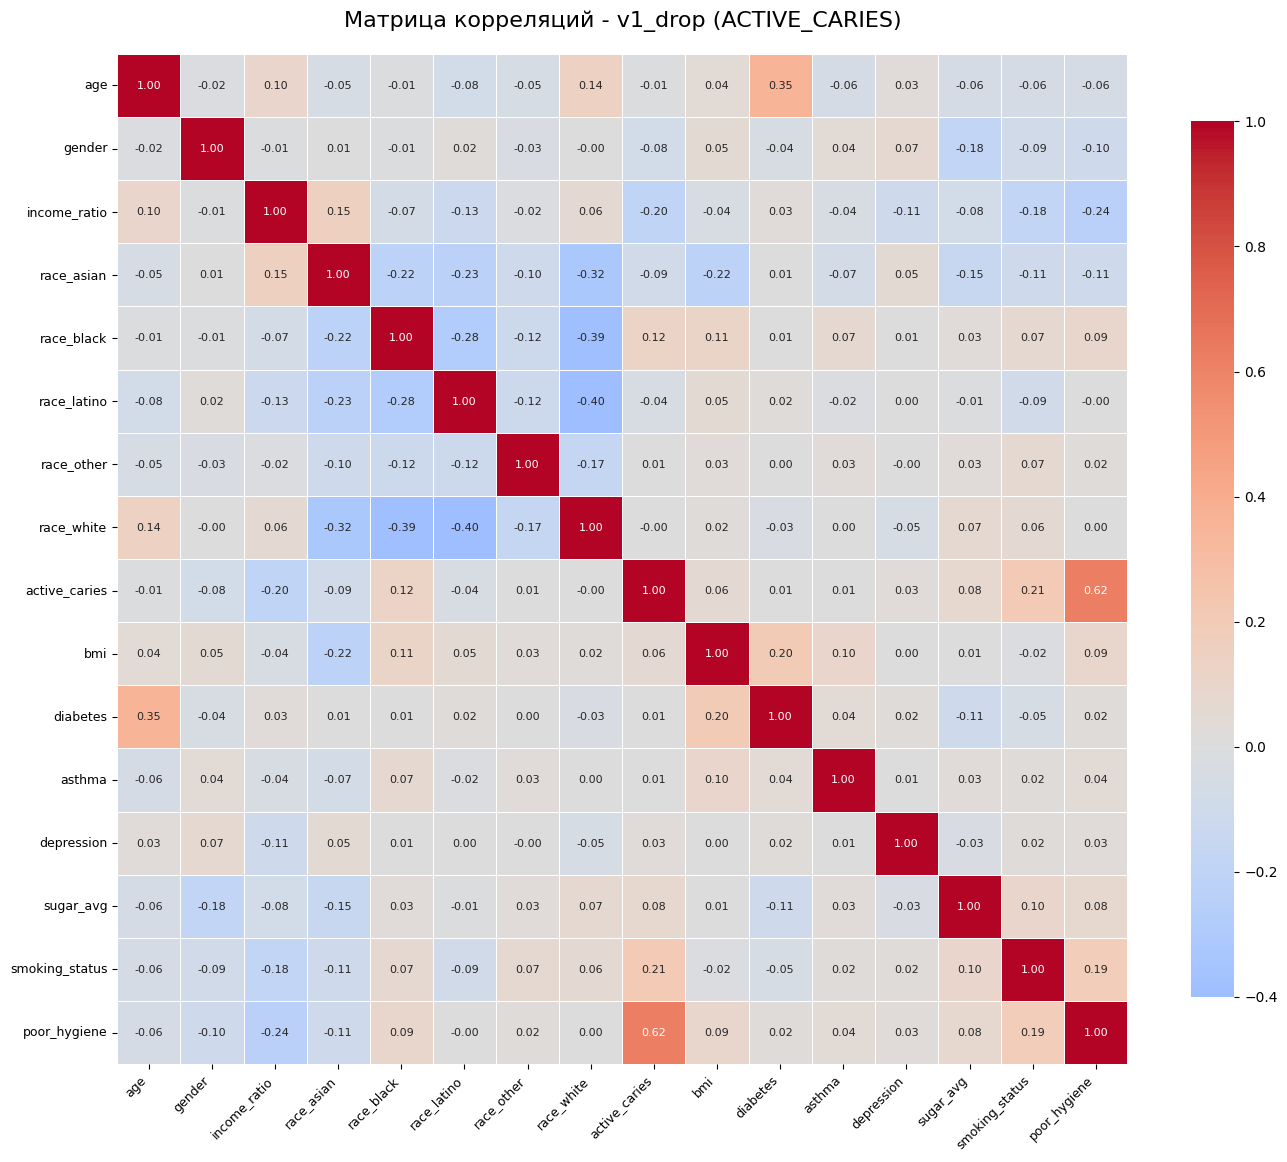


 КОРРЕЛЯЦИИ ФАКТОРОВ РИСКА С ACTIVE_CARIES: v1_drop

 ПРИЗНАК                   |   КОРРЕЛЯЦИЯ | СИЛА        
-------------------------------------------------------
 poor_hygiene              | +     0.6249 | сильная     
 smoking_status            | +     0.2111 | слабая      
 income_ratio              | -     0.2038 | слабая      
 race_black                | +     0.1168 | очень слабая
 race_asian                | -     0.0921 | очень слабая
 gender                    | -     0.0849 | очень слабая
 sugar_avg                 | +     0.0838 | очень слабая
 bmi                       | +     0.0619 | очень слабая
 race_latino               | -     0.0386 | очень слабая
 depression                | +     0.0260 | очень слабая
 age                       | -     0.0144 | очень слабая
 asthma                    | +     0.0135 | очень слабая
 race_other                | +     0.0074 | очень слабая
 diabetes                  | +     0.0058 | очень слабая
 race_white                | -     

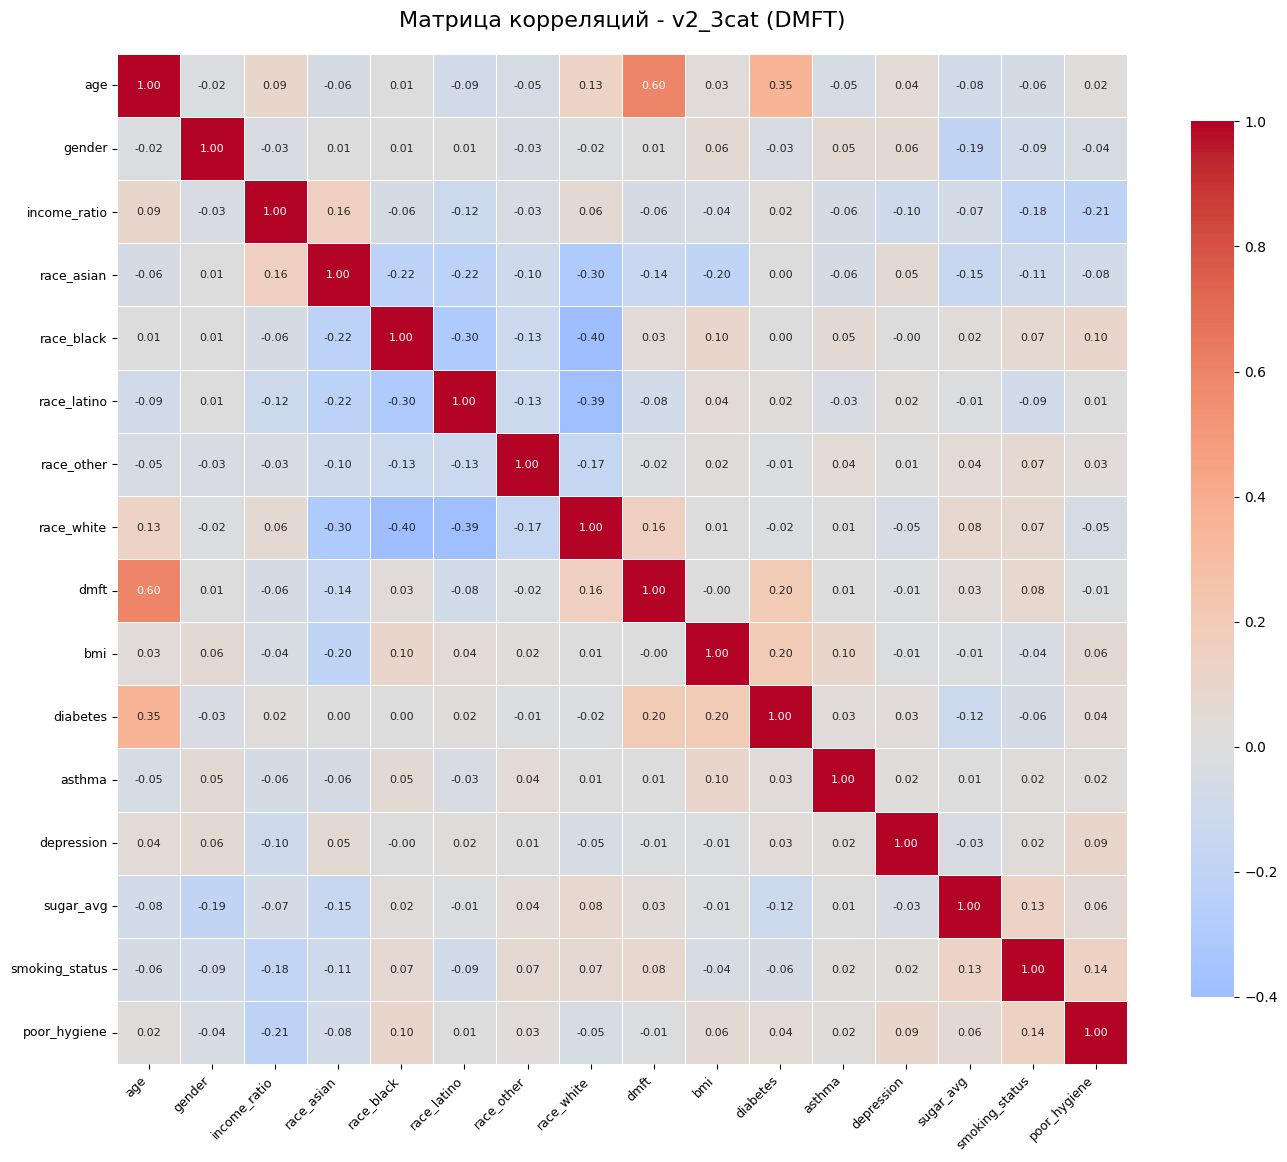


 КОРРЕЛЯЦИИ ФАКТОРОВ РИСКА С DMFT: v2_3cat

 ПРИЗНАК                   |   КОРРЕЛЯЦИЯ | СИЛА        
-------------------------------------------------------
 age                       | +     0.6030 | сильная     
 diabetes                  | +     0.2020 | слабая      
 race_white                | +     0.1607 | очень слабая
 race_asian                | -     0.1413 | очень слабая
 smoking_status            | +     0.0790 | очень слабая
 race_latino               | -     0.0786 | очень слабая
 income_ratio              | -     0.0577 | очень слабая
 sugar_avg                 | +     0.0338 | очень слабая
 race_black                | +     0.0271 | очень слабая
 race_other                | -     0.0232 | очень слабая
 depression                | -     0.0148 | очень слабая
 poor_hygiene              | -     0.0094 | очень слабая
 gender                    | +     0.0093 | очень слабая
 asthma                    | +     0.0092 | очень слабая
 bmi                       | -     0.0016 | 

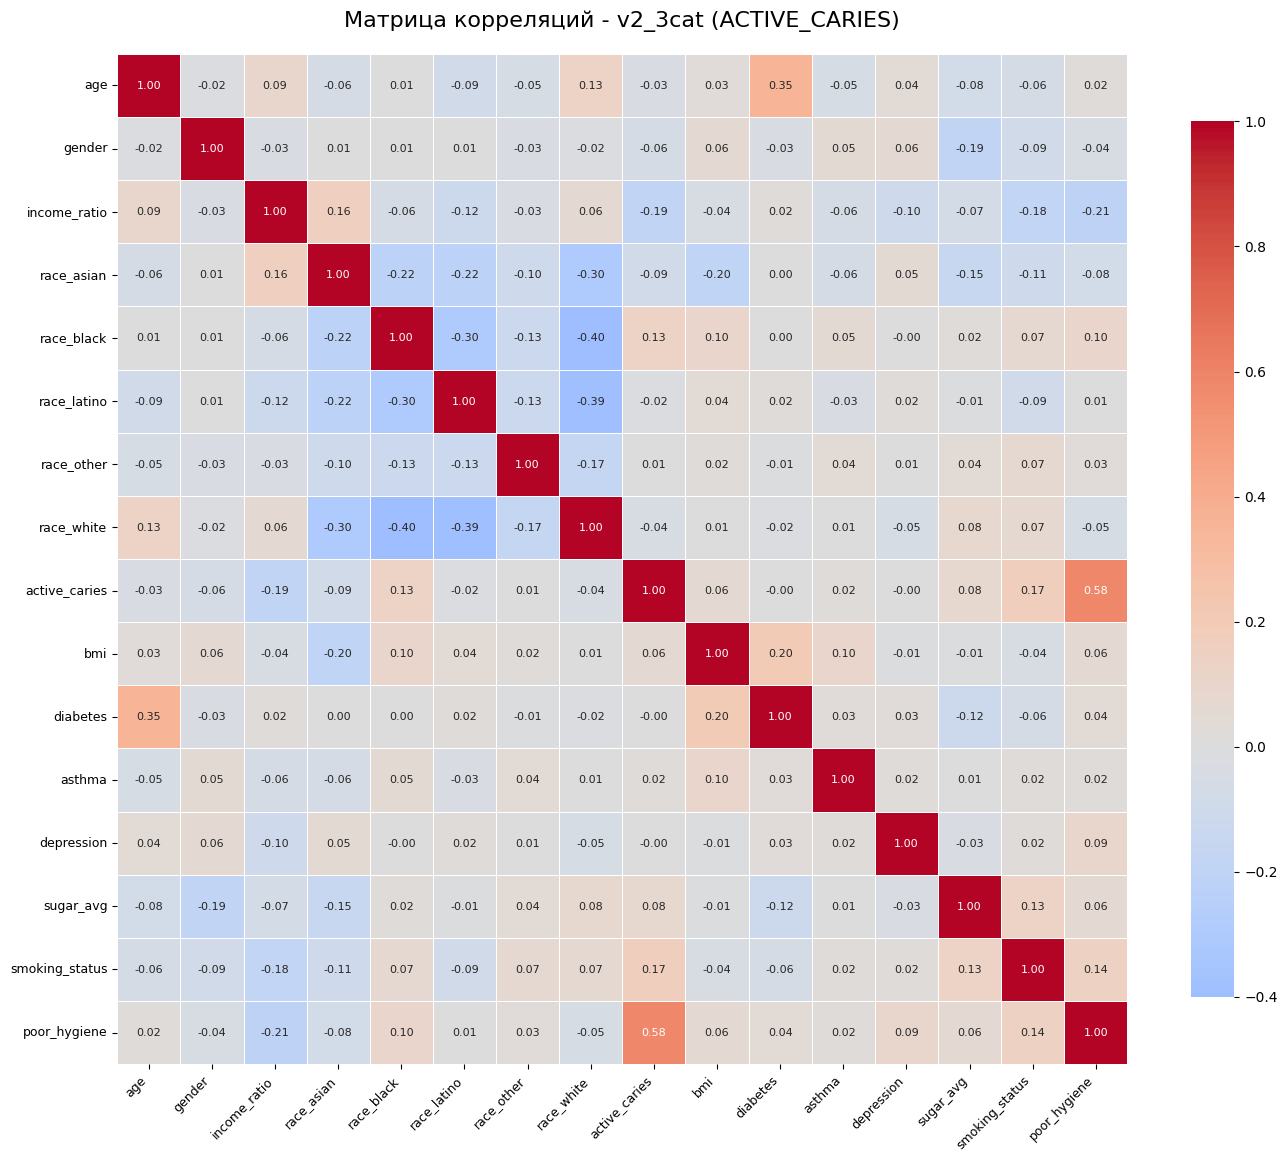


 КОРРЕЛЯЦИИ ФАКТОРОВ РИСКА С ACTIVE_CARIES: v2_3cat

 ПРИЗНАК                   |   КОРРЕЛЯЦИЯ | СИЛА        
-------------------------------------------------------
 poor_hygiene              | +     0.5818 | умеренная   
 income_ratio              | -     0.1868 | очень слабая
 smoking_status            | +     0.1655 | очень слабая
 race_black                | +     0.1334 | очень слабая
 race_asian                | -     0.0892 | очень слабая
 sugar_avg                 | +     0.0787 | очень слабая
 bmi                       | +     0.0645 | очень слабая
 gender                    | -     0.0607 | очень слабая
 race_white                | -     0.0382 | очень слабая
 age                       | -     0.0276 | очень слабая
 race_latino               | -     0.0201 | очень слабая
 asthma                    | +     0.0154 | очень слабая
 race_other                | +     0.0070 | очень слабая
 diabetes                  | -     0.0036 | очень слабая
 depression                | -     

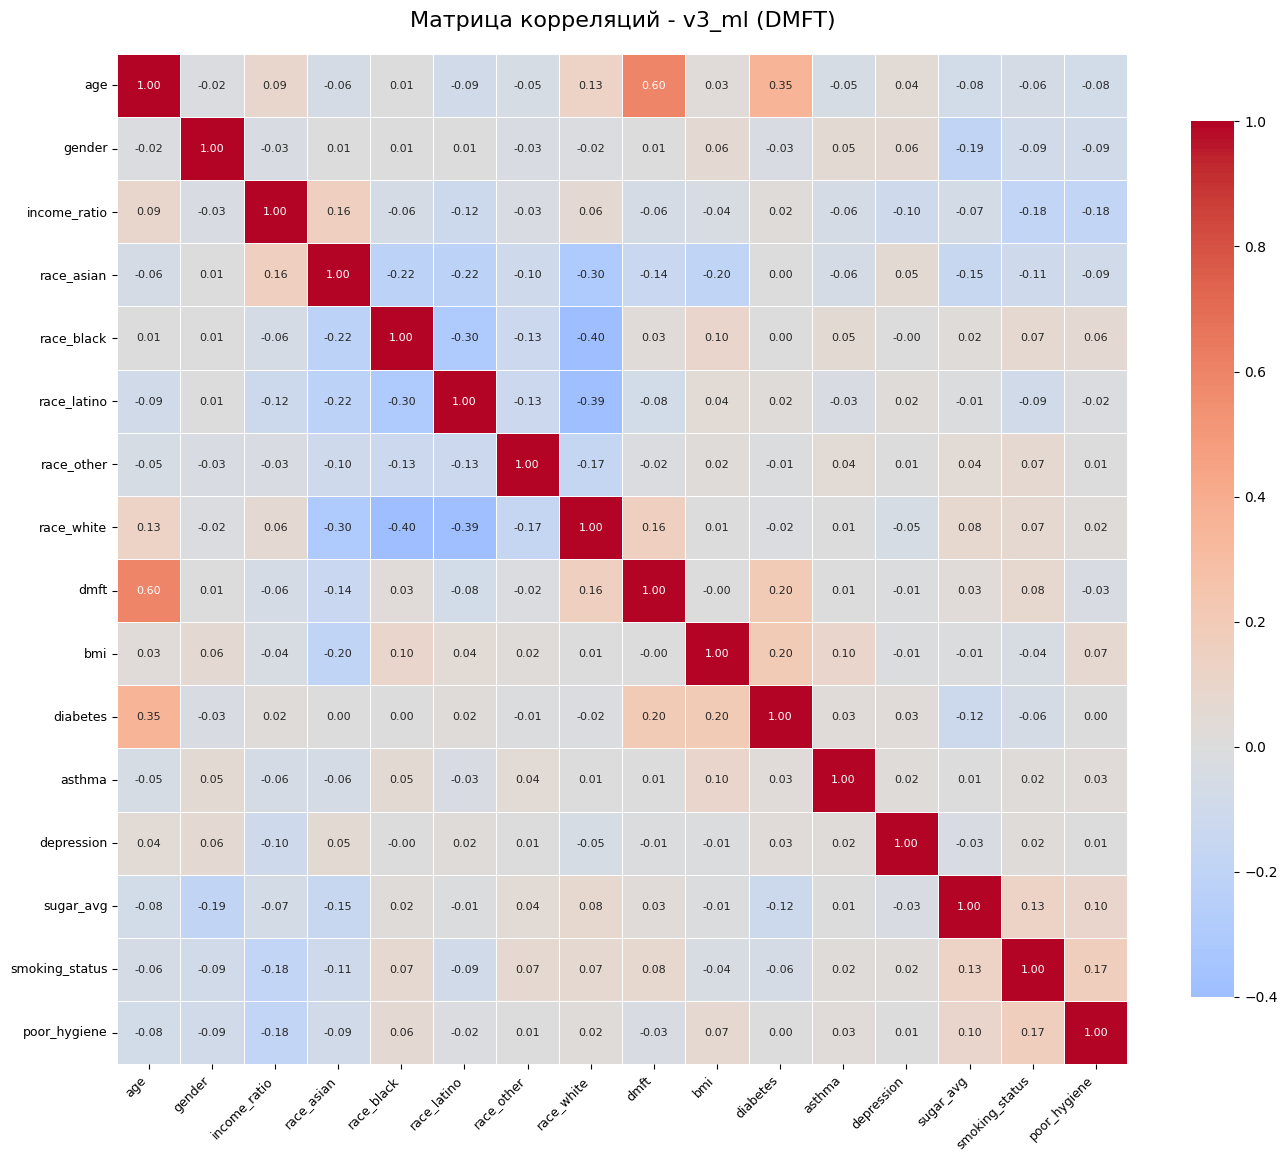


 КОРРЕЛЯЦИИ ФАКТОРОВ РИСКА С DMFT: v3_ml

 ПРИЗНАК                   |   КОРРЕЛЯЦИЯ | СИЛА        
-------------------------------------------------------
 age                       | +     0.6030 | сильная     
 diabetes                  | +     0.2020 | слабая      
 race_white                | +     0.1607 | очень слабая
 race_asian                | -     0.1413 | очень слабая
 smoking_status            | +     0.0790 | очень слабая
 race_latino               | -     0.0786 | очень слабая
 income_ratio              | -     0.0577 | очень слабая
 sugar_avg                 | +     0.0338 | очень слабая
 poor_hygiene              | -     0.0323 | очень слабая
 race_black                | +     0.0271 | очень слабая
 race_other                | -     0.0232 | очень слабая
 depression                | -     0.0148 | очень слабая
 gender                    | +     0.0093 | очень слабая
 asthma                    | +     0.0092 | очень слабая
 bmi                       | -     0.0016 | оч

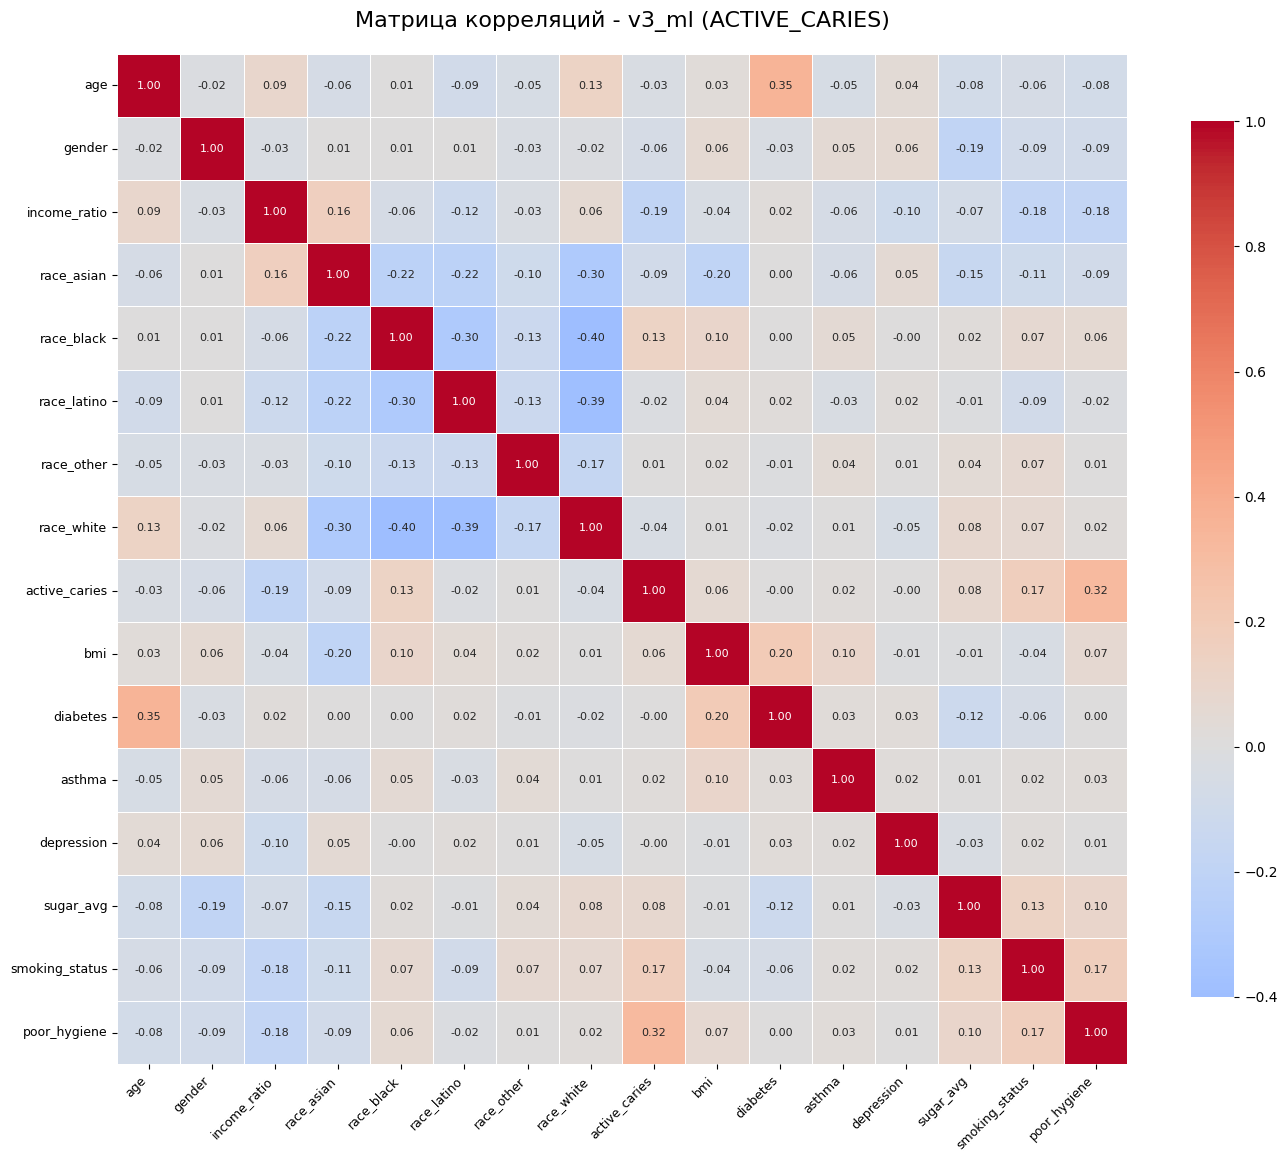


 КОРРЕЛЯЦИИ ФАКТОРОВ РИСКА С ACTIVE_CARIES: v3_ml

 ПРИЗНАК                   |   КОРРЕЛЯЦИЯ | СИЛА        
-------------------------------------------------------
 poor_hygiene              | +     0.3229 | слабая      
 income_ratio              | -     0.1868 | очень слабая
 smoking_status            | +     0.1655 | очень слабая
 race_black                | +     0.1334 | очень слабая
 race_asian                | -     0.0892 | очень слабая
 sugar_avg                 | +     0.0787 | очень слабая
 bmi                       | +     0.0645 | очень слабая
 gender                    | -     0.0607 | очень слабая
 race_white                | -     0.0382 | очень слабая
 age                       | -     0.0276 | очень слабая
 race_latino               | -     0.0201 | очень слабая
 asthma                    | +     0.0154 | очень слабая
 race_other                | +     0.0070 | очень слабая
 diabetes                  | -     0.0036 | очень слабая
 depression                | -     0.

In [19]:
# ============================================================================
# ЭТАП 1.18: МАТРИЦА КОРРЕЛЯЦИЙ И АНАЛИЗ СВЯЗИ ФАКТОРОВ РИСКА 
#           С ЦЕЛЕВЫМИ ПЕРЕМЕННЫМИ (DMFT и ACTIVE_CARIES)
# ============================================================================
# Цель: визуализация матрицы корреляций и выявление всех факторов, влияющих на:
#       1. dmft (регрессия) 
#       2. active_caries (бинарная классификация) 
# ============================================================================

print("\n" + "="*80)
print("1.18: МАТРИЦА КОРРЕЛЯЦИЙ И АНАЛИЗ СВЯЗИ ФАКТОРОВ РИСКА")
print("   Целевые переменные: DMFT и ACTIVE_CARIES")
print("="*80)

datasets = {
    'v1_drop': pd.read_csv('../data/processed/dataset_v1_drop.csv'),
    'v2_3cat': pd.read_csv('../data/processed/dataset_v2_3cat.csv'),
    'v3_ml': pd.read_csv('../data/processed/dataset_v3_ml.csv')
}

for name, dataset in datasets.items():
    print("\n" + "="*80)
    print(f" МАТРИЦА КОРРЕЛЯЦИЙ: {name}")
    print("="*80)
    
    # ========================================================================
    # 1. АНАЛИЗ ДЛЯ DMFT
    # ========================================================================
    
    # Выбираем только числовые колонки
    numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns
    numeric_cols = [col for col in numeric_cols if col != 'id']
    
    # Исключаем компоненты DMFT (чтобы не было автокорреляции)
    exclude_from_corr_dmft = [
        'teeth_missing', 'teeth_filled', 'teeth_total', 'carious_count',
        'age_group', 'income_category', 'active_caries'
    ]
    numeric_cols_dmft = [col for col in numeric_cols if col not in exclude_from_corr_dmft]
    
    print(f"\n АНАЛИЗ ДЛЯ DMFT:")
    print(f"   Анализируем {len(numeric_cols_dmft)} числовых признаков")
    
    # Матрица корреляций для DMFT
    corr_matrix_dmft = dataset[numeric_cols_dmft].corr()
    
    # Тепловая карта для DMFT
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr_matrix_dmft.round(2), 
                annot=True, 
                fmt='.2f',
                annot_kws={'size': 8},
                cmap='coolwarm',
                center=0,
                square=True,
                linewidths=0.5,
                cbar_kws={"shrink": 0.8})
    
    plt.title(f'Матрица корреляций - {name} (DMFT)', fontsize=16, pad=20)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    
    plt.savefig(f'../results/clustering/correlation_{name}_dmft.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'../results/clustering/correlation_{name}_dmft.pdf', bbox_inches='tight')
    plt.show()
    
    # Корреляции с DMFT
    print(f"\n{'='*80}")
    print(f" КОРРЕЛЯЦИИ ФАКТОРОВ РИСКА С DMFT: {name}")
    print(f"{'='*80}")
    
    target_dmft = 'dmft'
    correlations_dmft = []
    
    if target_dmft in dataset.columns:
        for col in numeric_cols_dmft:
            if col != target_dmft and col in dataset.columns:
                corr = dataset[col].corr(dataset[target_dmft])
                if not np.isnan(corr):
                    correlations_dmft.append((col, corr))
        
        correlations_dmft.sort(key=lambda x: abs(x[1]), reverse=True)
        
        print(f"\n {'ПРИЗНАК':<25} | {'КОРРЕЛЯЦИЯ':>12} | {'СИЛА':<12}")
        print("-" * 55)
        
        for col, corr in correlations_dmft:
            sign = "+" if corr > 0 else "-"
            if abs(corr) >= 0.6:
                strength = "сильная"
            elif abs(corr) >= 0.4:
                strength = "умеренная"
            elif abs(corr) >= 0.2:
                strength = "слабая"
            else:
                strength = "очень слабая"
            
            print(f" {col:<25} | {sign} {abs(corr):>10.4f} | {strength:<12}")
        
        print(f"\n ТОП-5 ФАКТОРОВ, КОРРЕЛИРУЮЩИХ С DMFT:")
        for col, corr in correlations_dmft[:5]:
            sign = "+" if corr > 0 else "-"
            print(f"    {sign} {col:<20}: {corr:+.4f}")
    
    # ========================================================================
    # 2. АНАЛИЗ ДЛЯ ACTIVE_CARIES
    # ========================================================================
    
    # Исключаем компоненты для active_caries
    exclude_from_corr_active = [
        'teeth_missing', 'teeth_filled', 'teeth_total', 'carious_count',
        'age_group', 'income_category', 'dmft'
    ]
    numeric_cols_active = [col for col in numeric_cols if col not in exclude_from_corr_active]
    
    print(f"\n АНАЛИЗ ДЛЯ ACTIVE_CARIES:")
    print(f"   Анализируем {len(numeric_cols_active)} числовых признаков")
    
    # Проверяем наличие active_caries
    if 'active_caries' in dataset.columns:
        # Матрица корреляций для ACTIVE_CARIES
        if 'active_caries' not in numeric_cols_active:
            numeric_cols_active.append('active_caries')
        
        corr_matrix_active = dataset[numeric_cols_active].corr()
        
        # Тепловая карта для ACTIVE_CARIES
        plt.figure(figsize=(14, 12))
        sns.heatmap(corr_matrix_active.round(2), 
                    annot=True, 
                    fmt='.2f',
                    annot_kws={'size': 8},
                    cmap='coolwarm',
                    center=0,
                    square=True,
                    linewidths=0.5,
                    cbar_kws={"shrink": 0.8})
        
        plt.title(f'Матрица корреляций - {name} (ACTIVE_CARIES)', fontsize=16, pad=20)
        plt.xticks(rotation=45, ha='right', fontsize=9)
        plt.yticks(rotation=0, fontsize=9)
        plt.tight_layout()
        
        plt.savefig(f'../results/clustering/correlation_{name}_active_caries.png', dpi=300, bbox_inches='tight')
        plt.savefig(f'../results/clustering/correlation_{name}_active_caries.pdf', bbox_inches='tight')
        plt.show()
        
        # Корреляции с ACTIVE_CARIES
        print(f"\n{'='*80}")
        print(f" КОРРЕЛЯЦИИ ФАКТОРОВ РИСКА С ACTIVE_CARIES: {name}")
        print(f"{'='*80}")
        
        target_active = 'active_caries'
        correlations_active = []
        
        for col in numeric_cols_active:
            if col != target_active and col in dataset.columns:
                corr = dataset[col].corr(dataset[target_active])
                if not np.isnan(corr):
                    correlations_active.append((col, corr))
        
        correlations_active.sort(key=lambda x: abs(x[1]), reverse=True)
        
        print(f"\n {'ПРИЗНАК':<25} | {'КОРРЕЛЯЦИЯ':>12} | {'СИЛА':<12}")
        print("-" * 55)
        
        for col, corr in correlations_active:
            sign = "+" if corr > 0 else "-"
            if abs(corr) >= 0.6:
                strength = "сильная"
            elif abs(corr) >= 0.4:
                strength = "умеренная"
            elif abs(corr) >= 0.2:
                strength = "слабая"
            else:
                strength = "очень слабая"
            
            print(f" {col:<25} | {sign} {abs(corr):>10.4f} | {strength:<12}")
        
        print(f"\n ТОП-5 ФАКТОРОВ, КОРРЕЛИРУЮЩИХ С ACTIVE_CARIES:")
        for col, corr in correlations_active[:5]:
            sign = "+" if corr > 0 else "-"
            print(f"    {sign} {col:<20}: {corr:+.4f}")
        
        # ========================================================================
        # 3. СРАВНИТЕЛЬНАЯ ТАБЛИЦА
        # ========================================================================
        
        print(f"\n{'='*80}")
        print(f" СРАВНЕНИЕ: DMFT vs ACTIVE_CARIES - {name}")
        print(f"{'='*80}")
        
        print(f"\n {'ПРИЗНАК':<25} | {'КОРР С DMFT':>12} | {'КОРР С ACTIVE_CARIES':>20}")
        print("-" * 62)
        
        dmft_dict = {col: corr for col, corr in correlations_dmft}
        active_dict = {col: corr for col, corr in correlations_active}
        
        all_cols = set(dmft_dict.keys()) | set(active_dict.keys())
        
        for col in sorted(all_cols):
            dmft_corr = dmft_dict.get(col, 0)
            active_corr = active_dict.get(col, 0)
            print(f" {col:<25} | {dmft_corr:+.4f}     | {active_corr:+.4f}")
        
        # Ключевые различия
        print(f"\n КЛЮЧЕВЫЕ РАЗЛИЧИЯ:")
        dmft_only = [col for col, corr in correlations_dmft[:5] if abs(active_dict.get(col, 0)) < 0.1]
        active_only = [col for col, corr in correlations_active[:5] if abs(dmft_dict.get(col, 0)) < 0.1]
        
        if dmft_only:
            print(f"   • Важны для DMFT, но не для ACTIVE_CARIES: {dmft_only}")
        if active_only:
            print(f"   • Важны для ACTIVE_CARIES, но не для DMFT: {active_only}")
        
        # Распределение active_caries
        print(f"\n РАСПРЕДЕЛЕНИЕ ACTIVE_CARIES:")
        active_counts = dataset['active_caries'].value_counts().sort_index()
        active_labels = {0: "Нет активного кариеса", 1: "Есть активный кариес"}
        for ac in active_counts.index:
            label = active_labels.get(ac, str(ac))
            count = active_counts[ac]
            pct = count / len(dataset) * 100
            print(f"   {label}: {count} ({pct:.1f}%)")

print("\n" + "="*80)
print(" АНАЛИЗ КОРРЕЛЯЦИЙ ЗАВЕРШЁН")
print("   Проанализированы связи с DMFT и ACTIVE_CARIES")
print("="*80)

In [20]:
# ============================================================================
# ЭТАП 1.19: ПРОВЕРКА МУЛЬТИКОЛЛИНЕАРНОСТИ (VIF) ДЛЯ ВСЕХ ТРЁХ ДАТАСЕТОВ
# ============================================================================
# Цель: оценка мультиколлинеарности между признаками с помощью Variance Inflation Factor (VIF)
#       VIF < 5 — отлично, 5-10 — умеренная корреляция, >10 — высокая мультиколлинеарность
# ============================================================================

print("\n" + "="*80)
print("1.19: ПРОВЕРКА МУЛЬТИКОЛЛИНЕАРНОСТИ (VIF) ДЛЯ ВСЕХ ТРЁХ ДАТАСЕТОВ")
print("="*80)

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Список датасетов
dataset_names = ['v1_drop', 'v2_3cat', 'v3_ml']
all_vif_results = {}

# Признаки для проверки
features_for_vif = ['age', 'gender', 'income_ratio', 'bmi', 'diabetes', 
                     'asthma', 'depression', 'sugar_avg', 'smoking_status', 
                     'poor_hygiene', 'race_asian', 'race_black', 'race_latino', 
                     'race_white', 'race_other']

for name in dataset_names:
    print(f"\n{'='*80}")
    print(f" ДАТАСЕТ: {name}")
    print(f"{'='*80}")
    
    # Загружаем датасет
    df_check = pd.read_csv(f'../data/processed/dataset_{name}.csv')
    
    # Проверяем, какие признаки есть в датасете
    available_features = [f for f in features_for_vif if f in df_check.columns]
    
    # Убираем колонки с пропусками
    df_vif = df_check[available_features].dropna()
    
    print(f"\nАнализируем {len(available_features)} признаков")
    print(f"Количество пациентов: {len(df_vif)}")
    
    # Расчет VIF
    vif_data = pd.DataFrame()
    vif_data['feature'] = df_vif.columns
    vif_data['VIF'] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]
    
    # Сортируем по убыванию VIF
    vif_data = vif_data.sort_values('VIF', ascending=False)
    
    print("\n Variance Inflation Factor (VIF):")
    print("   VIF < 5 — отлично")
    print("   5 < VIF < 10 — есть умеренная корреляция")
    print("   VIF > 10 — высокая мультиколлинеарность")
    print("\n", vif_data.to_string(index=False))
    
    # Анализируем результаты
    high_vif = vif_data[vif_data['VIF'] > 10]
    moderate_vif = vif_data[(vif_data['VIF'] > 5) & (vif_data['VIF'] <= 10)]
    good_vif = vif_data[vif_data['VIF'] <= 5]
    
    print(f"\n АНАЛИЗ:")
    print(f"   Хорошие признаки (VIF ≤ 5): {len(good_vif)} шт.")
    if len(moderate_vif) > 0:
        print(f"   Умеренная корреляция (5 < VIF ≤ 10): {list(moderate_vif['feature'])}")
    if len(high_vif) > 0:
        print(f"   Высокая мультиколлинеарность (VIF > 10): {list(high_vif['feature'])}")
    
    # Сохраняем результаты
    all_vif_results[name] = vif_data


1.19: ПРОВЕРКА МУЛЬТИКОЛЛИНЕАРНОСТИ (VIF) ДЛЯ ВСЕХ ТРЁХ ДАТАСЕТОВ

 ДАТАСЕТ: v1_drop

Анализируем 15 признаков
Количество пациентов: 4238

 Variance Inflation Factor (VIF):
   VIF < 5 — отлично
   5 < VIF < 10 — есть умеренная корреляция
   VIF > 10 — высокая мультиколлинеарность

        feature       VIF
    race_white 14.709948
    race_black  9.205437
   race_latino  8.882176
    race_asian  5.621522
    race_other  2.811409
      diabetes  1.215681
           age  1.197202
  income_ratio  1.145996
           bmi  1.121187
  poor_hygiene  1.112390
smoking_status  1.100253
     sugar_avg  1.084445
        gender  1.067586
    depression  1.027052
        asthma  1.026213

 АНАЛИЗ:
   Хорошие признаки (VIF ≤ 5): 11 шт.
   Умеренная корреляция (5 < VIF ≤ 10): ['race_black', 'race_latino', 'race_asian']
   Высокая мультиколлинеарность (VIF > 10): ['race_white']

 ДАТАСЕТ: v2_3cat

Анализируем 15 признаков
Количество пациентов: 5533

 Variance Inflation Factor (VIF):
   VIF < 5 — отлич

In [21]:
# ============================================================================
# ЭТАП 2.1: ЗАГРУЗКА ДАННЫХ ДЛЯ КЛАСТЕРИЗАЦИИ
# ============================================================================
# Цель: загрузка трех вариантов датасетов (v1_drop, v2_3cat, v3_ml)
# ============================================================================

print("\n" + "="*80)
print("2.1: ЗАГРУЗКА ДАННЫХ ДЛЯ КЛАСТЕРИЗАЦИИ")
print("="*80)

datasets = {
    'v1_drop': pd.read_csv('../data/processed/dataset_v1_drop.csv'),
    'v2_3cat': pd.read_csv('../data/processed/dataset_v2_3cat.csv'),
    'v3_ml': pd.read_csv('../data/processed/dataset_v3_ml.csv')
}

for name, df in datasets.items():
    print(f"\n {name}: {df.shape[0]} пациентов, {df.shape[1]} признаков")


2.1: ЗАГРУЗКА ДАННЫХ ДЛЯ КЛАСТЕРИЗАЦИИ

 v1_drop: 4238 пациентов, 24 признаков

 v2_3cat: 5533 пациентов, 24 признаков

 v3_ml: 5533 пациентов, 24 признаков


### Анализирую лучшие комбинации для кластеризации

**8 признаков для кластеризации:**

* `smoking_status`, `asthma` — бинарные (0 — нет, 1 — да)
* `bmi`, `sugar_avg`, `income_ratio` — непрерывные
* `diabetes` — 3 значения (0 — нет диабета, 1 — предиабет, 2 — диабет)
* `depression` — 3 значения (0 — нет депрессии, 1 — депрессия, 2 — неизвестно)
* `poor_hygiene` — бинарный (0 — нет, 1 — да) для v1_drop и v3_ml  
* `poor_hygiene` — 3 значения (0 — нет, 1 — да, 2 — неизвестно) для v2_3cat

In [22]:
# ============================================================================
# 2.2: АНАЛИЗ ВСЕХ КОМБИНАЦИЙ ПРИЗНАКОВ (АВТОМАТИЧЕСКИЙ РЕЖИМ)
# ============================================================================
# Цель: поиск оптимального набора признаков для кластеризации по силуэтному коэффициенту
# 
# Логика работы:
# - Если файл best_clustering_features.json существует → использует готовый набор
# - Если файла нет → перебирает все комбинации (долго, 1 раз) и сохраняет результат
# ============================================================================

print("\n" + "="*80)
print("2.2: АНАЛИЗ ВСЕХ КОМБИНАЦИЙ ПРИЗНАКОВ")
print("="*80)

import json
import os

# Путь к файлу с сохранёнными лучшими признаками
FEATURES_FILE = '../models/best_clustering_features.json'

# Настраиваем pandas для полного вывода
pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

ALL_FEATURES = [
    'bmi', 'diabetes', 'sugar_avg', 'smoking_status', 
    'poor_hygiene', 'income_ratio', 'asthma', 'depression'
]

# =========================================================
# ПРОВЕРКА: есть ли сохранённые лучшие признаки?
# =========================================================
if os.path.exists(FEATURES_FILE):
    print("\n Найден файл с лучшими признаками для кластеризации!")
    with open(FEATURES_FILE, 'r') as f:
        BEST_FEATURES = json.load(f)
    print("   → Использую готовый набор признаков")
    USE_SEARCH = False
else:
    print("\n Файл с признаками не найден!")
    print("   → Запускаю поиск лучшей комбинации")
    USE_SEARCH = True
    BEST_FEATURES = {}

for dataset_name, df in datasets.items():
    print(f"\n{'='*80}")
    print(f" ДАТАСЕТ: {dataset_name}")
    print(f"{'='*80}")
    
    available_features = [f for f in ALL_FEATURES if f in df.columns]
    print(f" Признаки: {available_features}")
    
    if USE_SEARCH:
        # === РЕЖИМ ПОИСКА ЛУЧШЕЙ КОМБИНАЦИИ ===
        X_all = df[available_features].copy()
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_all)
        X_scaled_df = pd.DataFrame(X_scaled, columns=available_features)
        
        results = []
        
        for n_features in range(5, min(8, len(available_features) + 1)):
            for combo in combinations(available_features, n_features):
                combo = list(combo)
                X_subset = X_scaled_df[combo].values
                
                best_k_score = 0
                best_k = 0
                
                for k in range(3, 9):
                    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
                    labels = kmeans.fit_predict(X_subset)
                    
                    if len(np.unique(labels)) < 2:
                        continue
                        
                    score = silhouette_score(X_subset, labels)
                    
                    if score > best_k_score:
                        best_k_score = score
                        best_k = k
                
                if best_k > 0:
                    results.append({
                        'n': len(combo),
                        'k': best_k,
                        'sil': round(best_k_score, 4),
                        'features': ', '.join(combo)
                    })
        
        results_df = pd.DataFrame(results)
        results_df = results_df.sort_values('sil', ascending=False)
        
        print(f"\n{'='*60}")
        print(f" ВСЕ КОМБИНАЦИИ ({len(results_df)} шт.)")
        print(f"{'='*60}")
        print(results_df.head(20).to_string(index=False))
        
        best_row = results_df.iloc[0]
        print(f"\n ЛУЧШАЯ: sil={best_row['sil']} (k={best_row['k']})")
        print(f"   {best_row['features']}")
        
        # Сохраняем лучший набор признаков
        BEST_FEATURES[dataset_name] = {
            'features': best_row['features'].split(', '),
            'n_features': int(best_row['n']),       # int64 → int
            'k': int(best_row['k']),                 # int64 → int
            'silhouette': float(best_row['sil'])     # float64 → float
        }
        
    else:
        # === РЕЖИМ БЫСТРОГО ИСПОЛЬЗОВАНИЯ (с готовыми признаками ===
        best_data = BEST_FEATURES.get(dataset_name, {})
        if best_data:
            print(f"\n Использую сохранённые лучшие признаки:")
            print(f"   Признаки: {best_data['features']}")
            print(f"   Количество признаков: {best_data['n_features']}")
            print(f"   Оптимальное k: {best_data['k']}")
            print(f"   Силуэт: {best_data['silhouette']}")
        else:
            print(f"\n Для датасета {dataset_name} нет сохранённых признаков")

# =========================================================
# СОХРАНЕНИЕ РЕЗУЛЬТАТОВ (если был поиск)
# =========================================================
if USE_SEARCH:
    os.makedirs('../models', exist_ok=True)
    with open(FEATURES_FILE, 'w') as f:
        json.dump(BEST_FEATURES, f, indent=2)
    print("\n" + "="*80)
    print(" ЛУЧШИЕ ПРИЗНАКИ СОХРАНЕНЫ В ФАЙЛ:", FEATURES_FILE)
    print("="*80)


2.2: АНАЛИЗ ВСЕХ КОМБИНАЦИЙ ПРИЗНАКОВ

 Найден файл с лучшими признаками для кластеризации!
   → Использую готовый набор признаков

 ДАТАСЕТ: v1_drop
 Признаки: ['bmi', 'diabetes', 'sugar_avg', 'smoking_status', 'poor_hygiene', 'income_ratio', 'asthma', 'depression']

 Использую сохранённые лучшие признаки:
   Признаки: ['diabetes', 'smoking_status', 'poor_hygiene', 'asthma', 'depression']
   Количество признаков: 5
   Оптимальное k: 8
   Силуэт: 0.667

 ДАТАСЕТ: v2_3cat
 Признаки: ['bmi', 'diabetes', 'sugar_avg', 'smoking_status', 'poor_hygiene', 'income_ratio', 'asthma', 'depression']

 Использую сохранённые лучшие признаки:
   Признаки: ['diabetes', 'smoking_status', 'poor_hygiene', 'asthma', 'depression']
   Количество признаков: 5
   Оптимальное k: 8
   Силуэт: 0.5649

 ДАТАСЕТ: v3_ml
 Признаки: ['bmi', 'diabetes', 'sugar_avg', 'smoking_status', 'poor_hygiene', 'income_ratio', 'asthma', 'depression']

 Использую сохранённые лучшие признаки:
   Признаки: ['diabetes', 'smoking_stat


2.3: ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО ЧИСЛА КЛАСТЕРОВ

 ДАТАСЕТ: v1_drop
k=2: Inertia=16790, Silhouette=0.3955
k=3: Inertia=13261, Silhouette=0.4508
k=4: Inertia=10259, Silhouette=0.4927
k=5: Inertia=7935, Silhouette=0.5344
k=6: Inertia=6023, Silhouette=0.6170
k=7: Inertia=5226, Silhouette=0.6492
k=8: Inertia=4651, Silhouette=0.6670
k=9: Inertia=4130, Silhouette=0.6961
k=10: Inertia=3635, Silhouette=0.7141

 АНАЛИЗ:
   По силуэту (макс): k=10 (sil=0.7141)
   По методу локтя: k=6
   Компромисс (финал): k=8


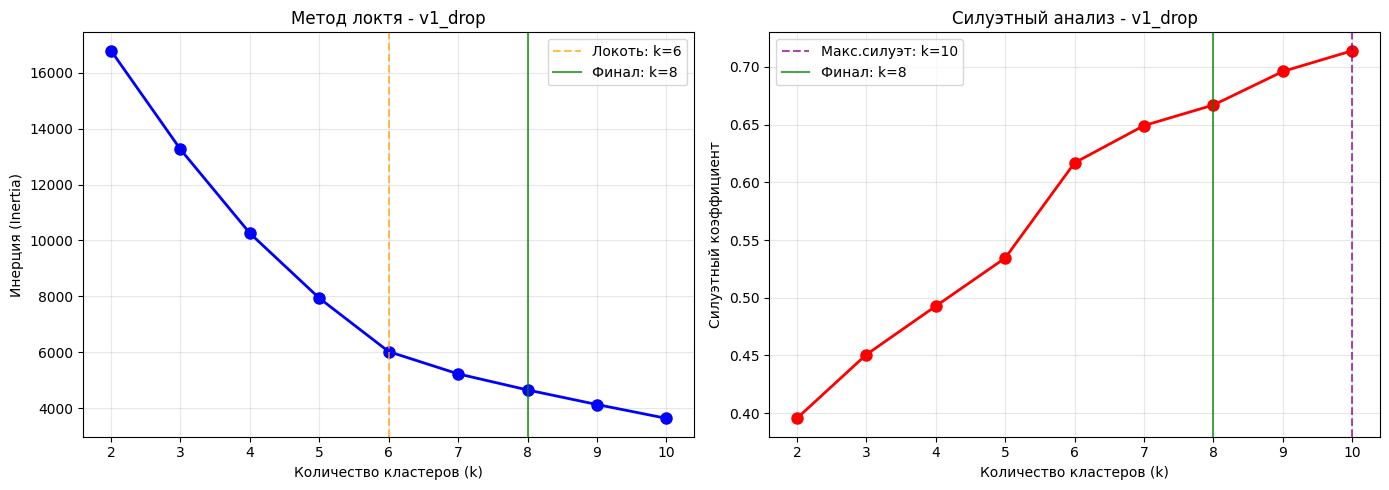


 ИТОГ для v1_drop: берем k=8

 ДАТАСЕТ: v2_3cat
k=2: Inertia=21993, Silhouette=0.3594
k=3: Inertia=17400, Silhouette=0.4070
k=4: Inertia=13581, Silhouette=0.4474
k=5: Inertia=10603, Silhouette=0.4531
k=6: Inertia=8540, Silhouette=0.5171
k=7: Inertia=7833, Silhouette=0.5258
k=8: Inertia=6842, Silhouette=0.5649
k=9: Inertia=6421, Silhouette=0.5699
k=10: Inertia=6022, Silhouette=0.5470

 АНАЛИЗ:
   По силуэту (макс): k=9 (sil=0.5699)
   По методу локтя: k=8
   Компромисс (финал): k=8


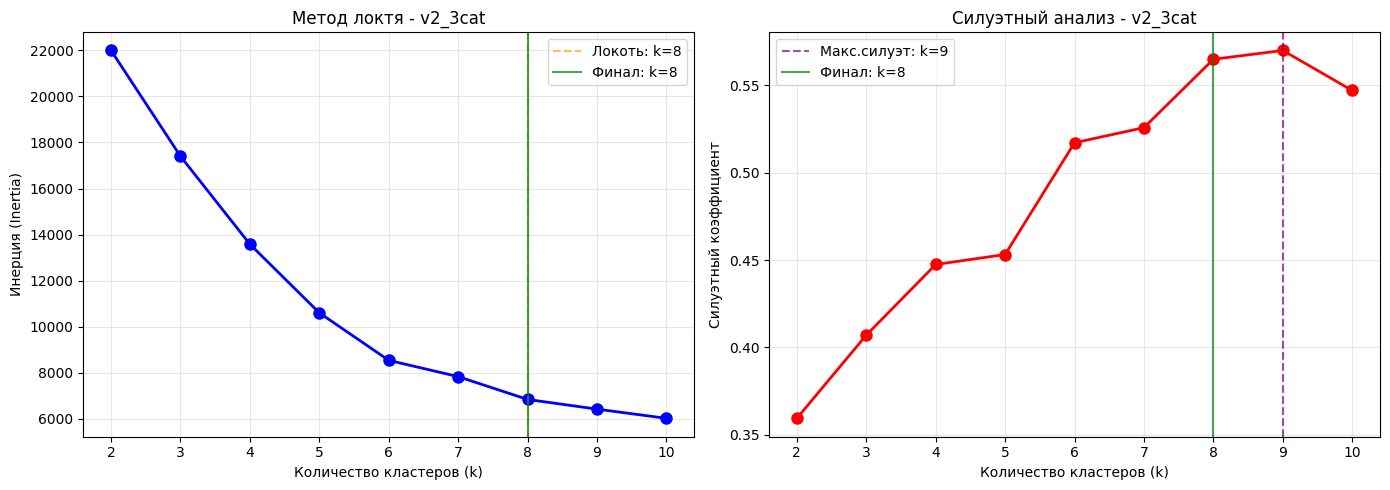


 ИТОГ для v2_3cat: берем k=8

 ДАТАСЕТ: v3_ml
k=2: Inertia=21939, Silhouette=0.3860
k=3: Inertia=17371, Silhouette=0.4269
k=4: Inertia=13984, Silhouette=0.4753
k=5: Inertia=10539, Silhouette=0.5359
k=6: Inertia=8046, Silhouette=0.6115
k=7: Inertia=6875, Silhouette=0.6506
k=8: Inertia=6079, Silhouette=0.6720
k=9: Inertia=5444, Silhouette=0.6865
k=10: Inertia=5016, Silhouette=0.6958

 АНАЛИЗ:
   По силуэту (макс): k=10 (sil=0.6958)
   По методу локтя: k=9
   Компромисс (финал): k=8


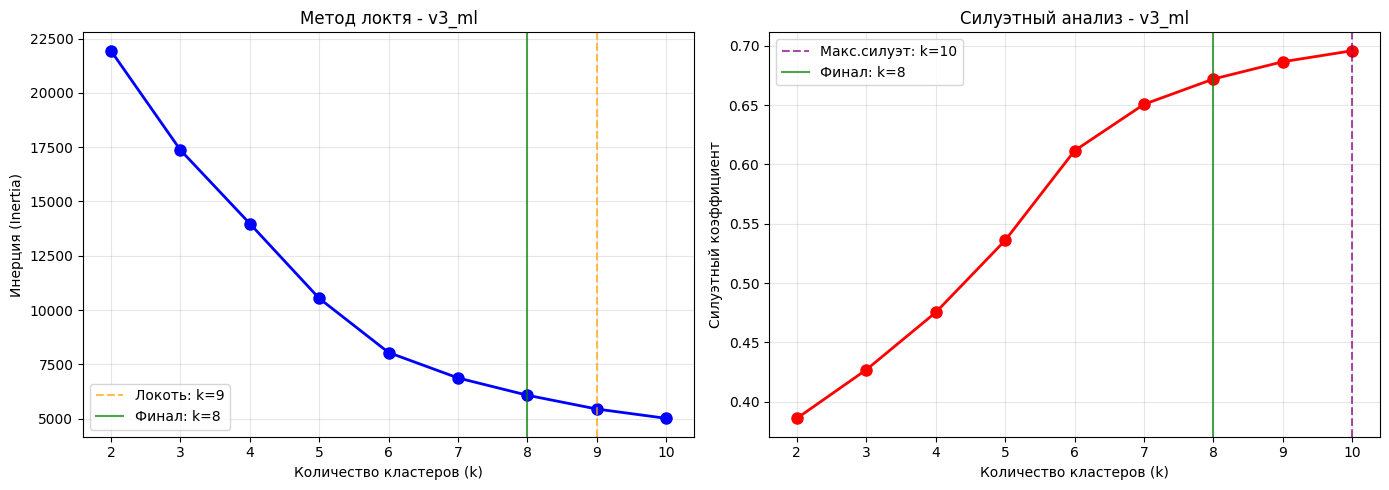


 ИТОГ для v3_ml: берем k=8

 ИТОГОВЫЕ ЗНАЧЕНИЯ K ДЛЯ ВСЕХ ДАТАСЕТОВ
   v1_drop: k=8
   v2_3cat: k=8
   v3_ml: k=8


In [23]:
# ============================================================================
# ЭТАП 2.3: ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО ЧИСЛА КЛАСТЕРОВ
# ============================================================================
# Цель: выбор k на основе метода локтя и силуэтного коэффициента
# ============================================================================

print("\n" + "="*80)
print("2.3: ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО ЧИСЛА КЛАСТЕРОВ")
print("="*80)

# Используем лучшие наборы признаков
optimal_features = ['diabetes', 'smoking_status', 'poor_hygiene', 'asthma', 'depression']

optimal_k_dict = {}

for dataset_name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f" ДАТАСЕТ: {dataset_name}")
    print(f"{'='*60}")
    
    features = optimal_features
    X = df[features].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    k_range = range(2, 11)
    inertias = []
    silhouettes = []

    # Перебираем возможные значения k
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        inertias.append(kmeans.inertia_)
        silhouettes.append(silhouette_score(X_scaled, labels))
        print(f"k={k}: Inertia={kmeans.inertia_:.0f}, Silhouette={silhouettes[-1]:.4f}")
    
    # ------------------------------------------------------------
    # ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО K ПО ДВУМ МЕТОДАМ
    # ------------------------------------------------------------
    
    # 1. По силуэту (максимум)
    k_silhouette = k_range[np.argmax(silhouettes)]
    sil_max = max(silhouettes)
    
    # 2. По методу локтя (точка перегиба)
    # Считаем "угол" между соседними точками
    angles = []
    for i in range(1, len(inertias)-1):
        # Векторы от предыдущей к текущей и от текущей к следующей
        v1 = np.array([k_range[i] - k_range[i-1], inertias[i] - inertias[i-1]])
        v2 = np.array([k_range[i+1] - k_range[i], inertias[i+1] - inertias[i]])
        
        # Косинус угла (чем меньше, тем острее угол)
        cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
        angles.append(cos_angle)
    
    # Берём точку с минимальным косинусом (самый острый угол)
    k_elbow = k_range[np.argmin(angles) + 1]  # +1 потому что angles считали с i=1
    
    # 3. Компромисс: берём среднее между локтем и максимумом силуэта
    # (но не больше 8 и не меньше 5 для интерпретируемости)
    k_final = int(np.clip(round((k_silhouette + k_elbow) / 2), 5, 8))
    
    print(f"\n АНАЛИЗ:")
    print(f"   По силуэту (макс): k={k_silhouette} (sil={sil_max:.4f})")
    print(f"   По методу локтя: k={k_elbow}")
    print(f"   Компромисс (финал): k={k_final}")
    
    # Визуализация
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Метод локтя с отметками
    axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
    axes[0].axvline(x=k_elbow, color='orange', linestyle='--', alpha=0.7, 
                    label=f'Локоть: k={k_elbow}')
    axes[0].axvline(x=k_final, color='green', linestyle='-', alpha=0.7, 
                    label=f'Финал: k={k_final}')
    axes[0].set_xlabel('Количество кластеров (k)')
    axes[0].set_ylabel('Инерция (Inertia)')
    axes[0].set_title(f'Метод локтя - {dataset_name}')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # Силуэтный коэффициент с отметками
    axes[1].plot(k_range, silhouettes, 'ro-', linewidth=2, markersize=8)
    axes[1].axvline(x=k_silhouette, color='purple', linestyle='--', alpha=0.7, 
                    label=f'Макс.силуэт: k={k_silhouette}')
    axes[1].axvline(x=k_final, color='green', linestyle='-', alpha=0.7, 
                    label=f'Финал: k={k_final}')
    axes[1].set_xlabel('Количество кластеров (k)')
    axes[1].set_ylabel('Силуэтный коэффициент')
    axes[1].set_title(f'Силуэтный анализ - {dataset_name}')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    plt.tight_layout()

    # Сохраняем графики
    plt.savefig(f'../results/clustering/elbow_silhouette_{dataset_name}.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'../results/clustering/elbow_silhouette_{dataset_name}.pdf', bbox_inches='tight')
    
    plt.show()
    
    # Сохраняем результат в словарь для дальнейшего использования
    optimal_k_dict[dataset_name] = k_final
    
    print(f"\n ИТОГ для {dataset_name}: берем k={k_final}")

# После цикла можно вывести итоги
print("\n" + "="*80)
print(" ИТОГОВЫЕ ЗНАЧЕНИЯ K ДЛЯ ВСЕХ ДАТАСЕТОВ")
print("="*80)
for name, k in optimal_k_dict.items():
    print(f"   {name}: k={k}")

In [24]:
# ============================================================================
# ЭТАП 2.4: ФИНАЛЬНАЯ КЛАСТЕРИЗАЦИЯ С ЛУЧШИМИ КОНФИГУРАЦИЯМИ
# ============================================================================
# Цель: выполнение K-Means кластеризации с оптимальными параметрами (k=8)
# ============================================================================

print("\n" + "="*80)
print("2.4: ФИНАЛЬНАЯ КЛАСТЕРИЗАЦИЯ")
print("="*80)

# Используем единый набор признаков для всех датасетов
optimal_features = ['diabetes', 'smoking_status', 'poor_hygiene', 'asthma', 'depression']

final_datasets = {}
for dataset_name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f" ФИНАЛЬНЫЙ АНАЛИЗ: {dataset_name}")
    print(f"{'='*60}")
    
    df = df.copy()
    features = optimal_features  # для всех одинаковый набор
    k = optimal_k_dict[dataset_name]  # берём из словаря, который сохранили ранее
    
    print(f"\n Используемые признаки ({len(features)}): {features}")
    print(f" Количество кластеров: k={k}")
    
    # Проверяем, что все признаки есть в датасете
    available_features = [f for f in features if f in df.columns]
    if len(available_features) < len(features):
        missing = set(features) - set(available_features)
        print(f"   Внимание! Отсутствуют признаки: {missing}")
        features = available_features
    
    # Кластеризация K-Means с оптимальными параметрами
    X = df[features].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(X_scaled)

    # Профили кластеров: средние значения признаков по каждому кластеру
    # Позволяют интерпретировать, чем кластеры отличаются друг от друга
    analyze_features = features + ['dmft', 'age', 'income_ratio', 'gender', 'bmi', 'sugar_avg']
    analyze_features = [f for f in analyze_features if f in df.columns]
    
    profiles = df.groupby('cluster')[analyze_features].mean().round(2)
    profiles['size'] = df.groupby('cluster').size()
    profiles['size_pct'] = (profiles['size'] / len(df) * 100).round(1)
    profiles = profiles.sort_values('dmft', ascending=False)
    
    print(f"\n РАСПРЕДЕЛЕНИЕ ПО КЛАСТЕРАМ:")
    for cluster in sorted(df['cluster'].unique()):
        count = (df['cluster'] == cluster).sum()
        pct = count / len(df) * 100
        print(f"   Кластер {cluster}: {count:4d} пациентов ({pct:5.1f}%)")
    
    print(f"\n ПРОФИЛИ КЛАСТЕРОВ (по уровню DMFT):")
    print(profiles.to_string())
    
    final_datasets[dataset_name] = df


2.4: ФИНАЛЬНАЯ КЛАСТЕРИЗАЦИЯ

 ФИНАЛЬНЫЙ АНАЛИЗ: v1_drop

 Используемые признаки (5): ['diabetes', 'smoking_status', 'poor_hygiene', 'asthma', 'depression']
 Количество кластеров: k=8

 РАСПРЕДЕЛЕНИЕ ПО КЛАСТЕРАМ:
   Кластер 0:  498 пациентов ( 11.8%)
   Кластер 1: 1469 пациентов ( 34.7%)
   Кластер 2:  250 пациентов (  5.9%)
   Кластер 3:  562 пациентов ( 13.3%)
   Кластер 4:  375 пациентов (  8.8%)
   Кластер 5:  687 пациентов ( 16.2%)
   Кластер 6:  287 пациентов (  6.8%)
   Кластер 7:  110 пациентов (  2.6%)

 ПРОФИЛИ КЛАСТЕРОВ (по уровню DMFT):
         diabetes  smoking_status  poor_hygiene  asthma  depression    dmft     age  income_ratio  gender     bmi  sugar_avg  size  size_pct
cluster                                                                                                                                     
5          1.5700          0.0000        0.1400  0.0000      0.0500 14.2400 61.3500        2.9200  0.4700 31.0500    86.7700   687   16.2000
6          0.3400   

In [25]:
# ============================================================================
# ЭТАП 2.5: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ
# ============================================================================
# Цель: сохранение датасетов с метками кластеров, профилей, параметров и моделей
# ============================================================================

print("\n" + "="*80)
print("2.5: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ")
print("="*80)

# Единый набор признаков для всех датасетов
optimal_features = ['diabetes', 'smoking_status', 'poor_hygiene', 'asthma', 'depression']

# 1. Сохраняем датасеты с метками кластеров для каждого подхода
for dataset_name, df in final_datasets.items():
    output_path = f'../data/processed/dataset_{dataset_name}_with_clusters.csv'
    df.to_csv(output_path, index=False)
    print(f"    {dataset_name}: {len(df)} строк, {df['cluster'].nunique()} кластеров")

# 2. Сохраняем профили кластеров в Excel для удобного просмотра
with pd.ExcelWriter('../results/clustering/cluster_profiles.xlsx') as writer:
    for dataset_name, df in final_datasets.items():
        analyze_features = optimal_features + ['dmft', 'age', 'income_ratio', 'gender', 'bmi', 'sugar_avg']
        
        profiles = df.groupby('cluster')[analyze_features].mean().round(2)
        profiles['size'] = df.groupby('cluster').size()
        profiles['size_pct'] = (profiles['size'] / len(df) * 100).round(1)
        
        profiles.to_excel(writer, sheet_name=dataset_name)

print(f"\n Профили кластеров: ../results/clustering/cluster_profiles.xlsx")

# 3. Сохраняем параметры кластеризации в JSON

clustering_params = {
    dataset_name: {
        'features': optimal_features,
        'n_clusters': optimal_k_dict[dataset_name],  # используем словарь с k  
        'dataset_size': len(final_datasets[dataset_name])
    }
    for dataset_name in final_datasets.keys()
}

with open('../results/clustering/clustering_params.json', 'w') as f:
    json.dump(clustering_params, f, indent=2, ensure_ascii=False)

print(f" Параметры: ../results/clustering/clustering_params.json")

# 4. Сохраняем модели для воспроизводимости
print("\n" + "="*80)
print(" СОХРАНЕНИЕ МОДЕЛЕЙ")
print("="*80)

for dataset_name, df in final_datasets.items():
    features = optimal_features
    k = optimal_k_dict[dataset_name]
    
    # Проверяем, что все признаки есть в датасете
    available_features = [f for f in features if f in df.columns]
    
    # Обучаем модели заново (чтобы сохранить)
    X = df[available_features].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    
    # Сохраняем
    joblib.dump(scaler, f'../models/scaler_{dataset_name}.pkl')
    joblib.dump(kmeans, f'../models/kmeans_{dataset_name}.pkl')
    
    print(f"    {dataset_name}: модели сохранены")


2.5: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ
    v1_drop: 4238 строк, 8 кластеров
    v2_3cat: 5533 строк, 8 кластеров
    v3_ml: 5533 строк, 8 кластеров

 Профили кластеров: ../results/clustering/cluster_profiles.xlsx
 Параметры: ../results/clustering/clustering_params.json

 СОХРАНЕНИЕ МОДЕЛЕЙ
    v1_drop: модели сохранены
    v2_3cat: модели сохранены
    v3_ml: модели сохранены



2.6: ВИЗУАЛИЗАЦИЯ И СТАТИСТИЧЕСКАЯ ПРОВЕРКА КЛАСТЕРОВ

 АНАЛИЗ: v1_drop

 PCA: PC1=24.1%, PC2=21.2%


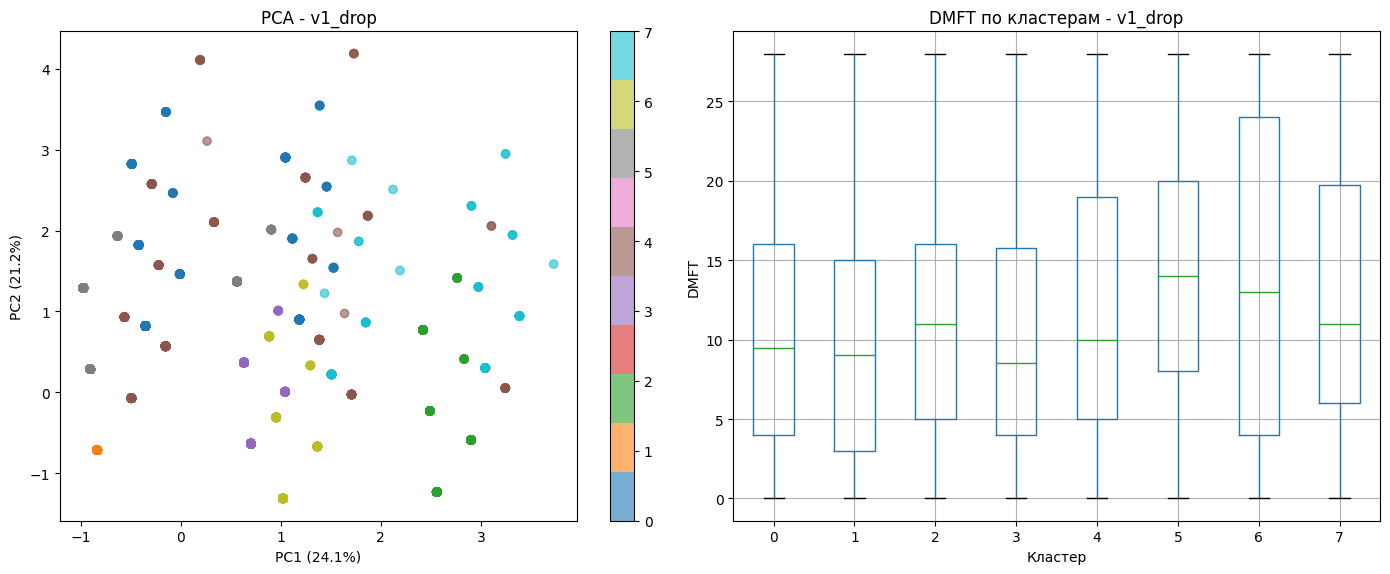


 ANOVA:
   dmft        : p=0.0000 ***
   age         : p=0.0000 ***
   bmi         : p=0.0000 ***
   sugar_avg   : p=0.0000 ***
   income_ratio: p=0.0000 ***

 ПРОФИЛИ КЛАСТЕРОВ:
           dmft     age  smoking_status  poor_hygiene  diabetes   asthma  depression  sugar_avg     bmi  income_ratio  gender  size  size_pct
cluster                                                                                                                                      
5       14.2400 61.3500          0.0000       14.0000    1.5700   0.0000      0.0500    86.7700 31.0500        2.9200 47.0000   687   16.2000
6       13.8600 49.0400        100.0000        0.0000    0.3400   0.0000      0.1200   103.4200 28.7500        2.2400 44.0000   287    6.8000
7       12.8500 41.7800        100.0000       49.0000    0.3300 100.0000      0.2900   116.2000 30.3100        1.7400 46.0000   110    2.6000
4       12.2500 51.4900          7.0000       19.0000    0.3700   8.0000      1.7400    91.8600 28.7100       

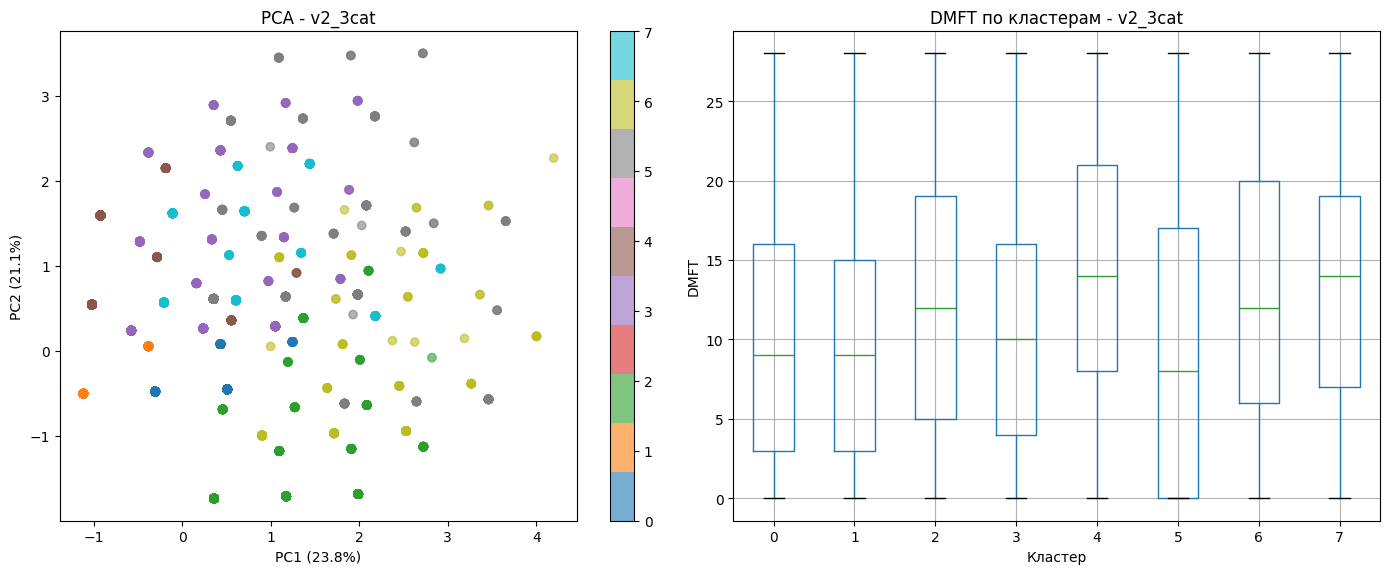


 ANOVA:
   dmft        : p=0.0000 ***
   age         : p=0.0000 ***
   bmi         : p=0.0000 ***
   sugar_avg   : p=0.0000 ***
   income_ratio: p=0.0000 ***

 ПРОФИЛИ КЛАСТЕРОВ:
           dmft     age  smoking_status  poor_hygiene  diabetes   asthma  depression  sugar_avg     bmi  income_ratio  gender  size  size_pct
cluster                                                                                                                                      
4       14.4000 60.6000          5.0000        0.0000    1.5100   0.0000      0.0800    89.0700 30.9900        2.9700 48.0000   648   11.7000
7       13.7400 60.0500          6.0000        1.6100    1.6100   0.0000      0.1200    87.9300 31.7900        2.2300 51.0000   447    8.1000
6       13.3300 44.6600        100.0000        0.9900    0.3600 100.0000      0.3300   113.6400 30.4700        1.6300 48.0000   165    3.0000
2       12.5100 46.9000        100.0000        0.9100    0.2000   0.0000      0.1400   116.6500 28.4700       

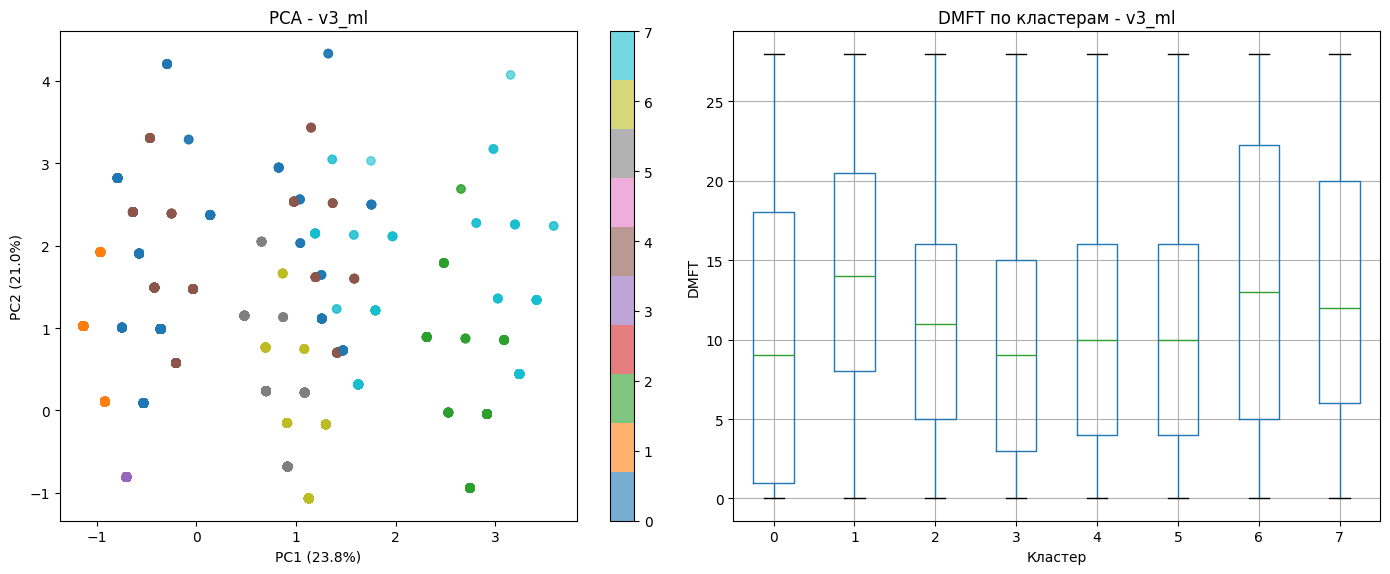


 ANOVA:
   dmft        : p=0.0000 ***
   age         : p=0.0000 ***
   bmi         : p=0.0000 ***
   sugar_avg   : p=0.0000 ***
   income_ratio: p=0.0000 ***

 ПРОФИЛИ КЛАСТЕРОВ:
           dmft     age  smoking_status  poor_hygiene  diabetes   asthma  depression  sugar_avg     bmi  income_ratio  gender  size  size_pct
cluster                                                                                                                                      
1       14.2800 61.0200          0.0000        0.0000    1.5400   0.0000      0.0600    87.2500 31.1100        2.8100 49.0000   831   15.0000
6       13.7900 49.5300        100.0000        0.0000    0.3300   0.0000      0.1200   105.4200 28.2200        2.1300 44.0000   468    8.5000
7       13.3300 44.6600        100.0000       40.0000    0.3600 100.0000      0.3300   113.6400 30.4700        1.6300 48.0000   165    3.0000
2       11.2100 44.9100        100.0000      100.0000    0.3500   0.0000      0.2600   132.4700 29.5500       

In [26]:
# ============================================================================
# ЭТАП 2.6: ВИЗУАЛИЗАЦИЯ И АНАЛИЗ КЛАСТЕРОВ
# ============================================================================
print("\n" + "="*80)
print("2.6: ВИЗУАЛИЗАЦИЯ И СТАТИСТИЧЕСКАЯ ПРОВЕРКА КЛАСТЕРОВ")
print("="*80)

from sklearn.decomposition import PCA
from scipy.stats import f_oneway
import seaborn as sns

cluster_features = ['diabetes', 'smoking_status', 'poor_hygiene', 'asthma', 'depression']

for dataset_name, df in final_datasets.items():
    print(f"\n{'='*60}\n АНАЛИЗ: {dataset_name}\n{'='*60}")
    
    features = [f for f in cluster_features if f in df.columns]
    X_scaled = StandardScaler().fit_transform(df[features])
    
    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    print(f"\n PCA: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Левый график: PCA
    scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='tab10', alpha=0.6)
    axes[0].set_title(f'PCA - {dataset_name}')
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    plt.colorbar(scatter, ax=axes[0])
    
    # Правый график: Boxplot (чистый, без точек)
    df.boxplot(column='dmft', by='cluster', ax=axes[1])
    axes[1].set_title(f'DMFT по кластерам - {dataset_name}')
    axes[1].set_xlabel('Кластер')
    axes[1].set_ylabel('DMFT')
    
    plt.suptitle('')
    plt.tight_layout()
    plt.savefig(f'../results/clustering/pca_{dataset_name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ANOVA
    print("\n ANOVA:")
    for feat in ['dmft', 'age', 'bmi', 'sugar_avg', 'income_ratio']:
        if feat in df.columns:
            groups = [df[df['cluster']==c][feat].dropna().values for c in sorted(df['cluster'].unique())]
            _, p = f_oneway(*groups)
            print(f"   {feat:12}: p={p:.4f} {'***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'н.з.'}")
    
    # Профили кластеров
    profile_cols = ['dmft', 'age', 'smoking_status', 'poor_hygiene', 'diabetes', 
                    'asthma', 'depression', 'sugar_avg', 'bmi', 'income_ratio', 'gender']
    profile = df.groupby('cluster')[profile_cols].mean().round(2)
    profile['size'] = df.groupby('cluster').size()
    profile['size_pct'] = (profile['size'] / len(df) * 100).round(1)
    
    # Преобразуем в проценты ТОЛЬКО для бинарных признаков
    # Для v2_3cat poor_hygiene имеет 3 категории (0,1,2) — НЕ преобразуем
    # Для v1_drop и v3_ml poor_hygiene бинарный — преобразуем
    
    # Бинарные признаки (всегда преобразуем)
    for col in ['smoking_status', 'asthma', 'gender']:
        if col in profile.columns and profile[col].max() <= 1:
            profile[col] = (profile[col] * 100).round(1)
    
    # poor_hygiene преобразуем ТОЛЬКО для v1_drop и v3_ml (бинарный)
    if dataset_name in ['v1_drop', 'v3_ml']:
        if 'poor_hygiene' in profile.columns and profile['poor_hygiene'].max() <= 1:
            profile['poor_hygiene'] = (profile['poor_hygiene'] * 100).round(1)
    # Для v2_3cat poor_hygiene оставляем как есть (0,1,2)
    
    profile = profile.sort_values('dmft', ascending=False)
    print(f"\n ПРОФИЛИ КЛАСТЕРОВ:\n{profile.to_string()}")
    
    # Ключевые отличия
    print(f"\n КЛЮЧЕВЫЕ ОТЛИЧИЯ:")
    sizes = df.groupby('cluster').size()
    print(f"   Самый большой: кластер {sizes.idxmax()} ({sizes.max()} пациентов, {sizes.max()/len(df)*100:.1f}%)")
    print(f"   Самый маленький: кластер {sizes.idxmin()} ({sizes.min()} пациентов, {sizes.min()/len(df)*100:.1f}%)")
    
    for metric, name in [('dmft', 'DMFT'), ('smoking_status', 'курение'), ('poor_hygiene', 'плохая гигиена'), 
                         ('diabetes', 'диабет'), ('asthma', 'астма'), ('depression', 'депрессия'), 
                         ('sugar_avg', 'сахар'), ('age', 'возраст'), ('income_ratio', 'доход')]:
        if metric in df.columns:
            mean_val = df.groupby('cluster')[metric].mean()
            print(f"   Макс. {name}: кластер {mean_val.idxmax()} ({mean_val.max():.2f})")
            print(f"   Мин. {name}: кластер {mean_val.idxmin()} ({mean_val.min():.2f})")

In [27]:
# ============================================================================
# 3.1: ЗАГРУЗКА ДАННЫХ И ПОДГОТОВКА ПРИЗНАКОВ (ДЛЯ МОДЕЛЕЙ)
# ============================================================================
print("="*80)
print("3.1: ЗАГРУЗКА ДАННЫХ И ПРИЗНАКИ")
print("="*80)

# ===== ЗАГРУЗКА ДАННЫХ =====
datasets = {}
for name in ['v1_drop', 'v2_3cat', 'v3_ml']:
    df = pd.read_csv(f'../data/processed/dataset_{name}_with_clusters.csv')
    # Обрезание выбросов уже сделано в этапе 1.16, повторно не делаем
    datasets[name] = df
    print(f"   {name}: {df.shape[0]} пациентов, {df['cluster'].nunique()} кластеров")
    if 'active_caries' not in df.columns:
        df['active_caries'] = (df['carious_count'] > 0).astype(int)

# ===== ПРИЗНАКИ =====
FEATURES = ['age', 'gender', 'income_ratio', 'race_asian', 'race_black', 
            'race_latino', 'race_white', 'race_other', 'bmi', 'diabetes', 
            'asthma', 'depression', 'sugar_avg', 'smoking_status', 'poor_hygiene']

def prepare_features(df, target_col='dmft'):
    """Подготавливает признаки для обучения"""
    X = df[[f for f in FEATURES if f in df.columns]].astype(float)
    return X, df[target_col].astype(float), X.columns.tolist()

print(f"\n   Всего признаков: {len(FEATURES)}")
print(" Данные загружены, prepare_features готова")

3.1: ЗАГРУЗКА ДАННЫХ И ПРИЗНАКИ
   v1_drop: 4238 пациентов, 8 кластеров
   v2_3cat: 5533 пациентов, 8 кластеров
   v3_ml: 5533 пациентов, 8 кластеров

   Всего признаков: 15
 Данные загружены, prepare_features готова


In [28]:
# ============================================================================
# 3.2: ПАРАМЕТРЫ ДЛЯ GRID SEARCH
# ============================================================================
print("\n" + "="*80)
print("3.2: ПАРАМЕТРЫ ДЛЯ GRID SEARCH")
print("="*80)

# Общие параметры для RandomForest (регрессия и классификация)
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 7, 8, 10],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [4, 6, 8],
    'max_features': ['sqrt', 'log2']
}

cb_param_grid = {'iterations': [150, 300, 500], 'depth': [4, 5, 6], 
                 'learning_rate': [0.03, 0.05, 0.07], 'l2_leaf_reg': [3, 5, 7]}

xgb_param_grid = {'n_estimators': [150, 200, 300], 'max_depth': [4, 5, 6],
                  'learning_rate': [0.03, 0.05, 0.07], 'reg_alpha': [0.1, 0.5, 1.0],
                  'reg_lambda': [0.5, 1.0, 2.0]}

lgb_param_grid = xgb_param_grid.copy()  # те же параметры

# Подсчёт количества комбинаций
def count_combinations(grid):
    total = 1
    for v in grid.values():
        total *= len(v)
    return total

rf_comb = count_combinations(rf_param_grid)
cb_comb = count_combinations(cb_param_grid)
xgb_comb = count_combinations(xgb_param_grid)
lgb_comb = count_combinations(lgb_param_grid)

print(f" RandomForest: {rf_comb} комбинаций")
print(f" CatBoost:     {cb_comb} комбинации")
print(f" XGBoost:      {xgb_comb} комбинаций")
print(f" LightGBM:     {lgb_comb} комбинаций")

# Параметры для классификации идентичны, копируем ссылки
rf_clf_param_grid = rf_param_grid
cb_clf_param_grid = cb_param_grid
xgb_clf_param_grid = xgb_param_grid
lgb_clf_param_grid = lgb_param_grid

# =========================================================
# ВСПОМОГАТЕЛЬНАЯ ФУНКЦИЯ ДЛЯ СОЗДАНИЯ МОДЕЛИ
# =========================================================
def create_model_from_params(model_name, params, is_classification=False, imbalance=None):
    if model_name == 'CatBoost':
        if is_classification:
            return CatBoostClassifier(**params, random_seed=42, verbose=False, auto_class_weights='Balanced')
        else:
            return CatBoostRegressor(**params, random_seed=42, verbose=False)
    elif model_name == 'XGBoost':
        if is_classification:
            # Передаём scale_pos_weight для балансировки
            if imbalance is not None:
                params['scale_pos_weight'] = imbalance
            return XGBClassifier(**params, random_state=42, n_jobs=-1, verbosity=0)
        else:
            return XGBRegressor(**params, random_state=42, n_jobs=-1, verbosity=0)
    elif model_name == 'LightGBM':
        if is_classification:
            return LGBMClassifier(**params, random_state=42, n_jobs=-1, verbose=-1, class_weight='balanced')
        else:
            return LGBMRegressor(**params, random_state=42, n_jobs=-1, verbose=-1)
    elif model_name == 'RandomForest':
        if is_classification:
            return RandomForestClassifier(**params, random_state=42, n_jobs=-1, class_weight='balanced')
        else:
            return RandomForestRegressor(**params, random_state=42, n_jobs=-1)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
print(f"\n КРОСС-ВАЛИДАЦИЯ: {cv.n_splits} фолдов, random_state=42\n")


3.2: ПАРАМЕТРЫ ДЛЯ GRID SEARCH
 RandomForest: 216 комбинаций
 CatBoost:     81 комбинации
 XGBoost:      243 комбинаций
 LightGBM:     243 комбинаций

 КРОСС-ВАЛИДАЦИЯ: 5 фолдов, random_state=42



In [29]:
# ============================================================================
# 3.3: ОБУЧЕНИЕ МОДЕЛЕЙ ДЛЯ DMFT (с быстрым обучением)
# ============================================================================
# Цель: обучение глобальных и кластерных моделей для прогнозирования DMFT
# Модели: RandomForest, CatBoost, XGBoost, LightGBM, Voting, Stacking
# 
# Логика работы:
# - Если файл best_params_dmft_full.json существует → быстрое обучение (без GridSearch)
# - Если файла нет → запускает GridSearch (долго, 1 раз) и сохраняет параметры
# ============================================================================

print("\n" + "="*80)
print("3.3: ОБУЧЕНИЕ МОДЕЛЕЙ ДЛЯ DMFT")
print("   Модели: RandomForest, CatBoost, XGBoost, LightGBM, Voting, Stacking")
print("="*80)

import json
import os

# Путь к файлу с сохранёнными параметрами
PARAMS_FILE = '../models/best_params_dmft_full.json'

# =========================================================
# ПРОВЕРКА: есть ли сохранённые параметры?
# =========================================================
if os.path.exists(PARAMS_FILE):
    print("\n Найден файл с параметрами! Использую быстрое обучение (без GridSearch)")
    with open(PARAMS_FILE, 'r') as f:
        SAVED_PARAMS = json.load(f)
    USE_GRIDSEARCH = False
else:
    print("\n Файл с параметрами не найден! Запускаю GridSearch")
    USE_GRIDSEARCH = True
    SAVED_PARAMS = {
        'global': {},
        'cluster': {}
    }

all_results_dmft = []
trained_models_dmft = {}

# Словарь моделей и их параметров
MODELS = {
    'RandomForest': (RandomForestRegressor(random_state=42, n_jobs=-1), rf_param_grid),
    'CatBoost': (CatBoostRegressor(random_seed=42, verbose=False, thread_count=-1), cb_param_grid),
    'XGBoost': (XGBRegressor(random_state=42, n_jobs=-1, verbosity=0), xgb_param_grid),
    'LightGBM': (LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1), lgb_param_grid)
}

for dataset_name, df in datasets.items():
    print(f"\n{'='*60}\nДАТАСЕТ: {dataset_name}\n{'='*60}")
    
    X, y, _ = prepare_features(df, 'dmft')
    X = X.astype(float)
    y = y.astype(float)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    test_indices = X_test.index
    
    # =========================================================
    # 1. ГЛОБАЛЬНЫЕ МОДЕЛИ
    # =========================================================
    print(f"\n   ОБУЧЕНИЕ ГЛОБАЛЬНЫХ МОДЕЛЕЙ:")
    
    global_models = {}
    for name, (model, param_grid) in MODELS.items():
        if USE_GRIDSEARCH:
            print(f"      {name} Grid Search...")
            grid = GridSearchCV(model, param_grid, cv=cv, scoring='r2', n_jobs=-1, verbose=0)
            grid.fit(X_train, y_train)
            global_models[name] = grid.best_estimator_
            SAVED_PARAMS['global'].setdefault(dataset_name, {})[name] = grid.best_params_
            print(f"         Лучшие параметры: {grid.best_params_}")
        else:
            params = SAVED_PARAMS['global'].get(dataset_name, {}).get(name, {})
            print(f"      {name}: {params}")
            new_model = create_model_from_params(name, params, is_classification=False)
            new_model.fit(X_train, y_train)
            global_models[name] = new_model 
    
    # Voting и Stacking
    voting_global = VotingRegressor(estimators=[(n.lower(), m) for n, m in global_models.items()])
    voting_global.fit(X_train, y_train)
    
    stacking_global = StackingRegressor(
        estimators=[(n.lower(), m) for n, m in global_models.items()],
        final_estimator=RandomForestRegressor(n_estimators=100, random_state=42), cv=5
    )
    stacking_global.fit(X_train, y_train)
    
    global_models['VotingRegressor'] = voting_global
    global_models['StackingRegressor'] = stacking_global
    
    # Оценка глобальных моделей
    print(f"\n      РЕЗУЛЬТАТЫ ГЛОБАЛЬНЫХ МОДЕЛЕЙ (на тесте):")
    for name, model in global_models.items():
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
        
        all_results_dmft.append({
            'dataset': dataset_name, 'model_name': name, 'type': 'global',
            'cluster': 'global', 'mae': round(mae, 4), 'rmse': round(rmse, 4),
            'r2': round(r2, 4), 'cv_r2_mean': round(cv_scores.mean(), 4),
            'cv_r2_std': round(cv_scores.std(), 4)
        })
        print(f"         {name}: R²={r2:.4f}, MAE={mae:.2f}, CV R²={cv_scores.mean():.4f}")
        trained_models_dmft[f"{dataset_name}_global_{name}"] = model
    
    # =========================================================
    # 1.2. ГЛОБАЛЬНЫЕ МОДЕЛИ НА КЛАСТЕРАХ (оценка)
    # =========================================================
    print(f"\n   ОЦЕНКА ГЛОБАЛЬНЫХ МОДЕЛЕЙ НА КЛАСТЕРАХ:")
    for cluster_id in sorted(df['cluster'].unique()):
        mask = (df['cluster'] == cluster_id) & (df.index.isin(test_indices))
        X_cluster, y_cluster = X[mask], y[mask]
        if len(X_cluster) < 3:
            continue
        
        print(f"\n     КЛАСТЕР {cluster_id} (test size={len(X_cluster)}):")
        for name, model in global_models.items():
            y_pred = model.predict(X_cluster)
            r2 = r2_score(y_cluster, y_pred)
            mae = mean_absolute_error(y_cluster, y_pred)
            rmse = np.sqrt(mean_squared_error(y_cluster, y_pred))
            all_results_dmft.append({
                'dataset': dataset_name, 'model_name': name, 'type': 'global_on_cluster',
                'cluster': cluster_id, 'mae': round(mae, 4), 'rmse': round(rmse, 4),
                'r2': round(r2, 4), 'cluster_size_test': len(X_cluster),
                'cluster_mean_test': round(y_cluster.mean(), 4)
            })
            print(f"          {name}: R²={r2:.4f}, MAE={mae:.2f}, RMSE={rmse:.2f}")
    
    # =========================================================
    # 2. КЛАСТЕРНЫЕ МОДЕЛИ
    # =========================================================
    print(f"\n   ОБУЧЕНИЕ КЛАСТЕРНЫХ МОДЕЛЕЙ:")
    for cluster_id in sorted(df['cluster'].unique()):
        mask = df['cluster'] == cluster_id
        X_cluster, y_cluster = X[mask], y[mask]
        if len(X_cluster) < 10:
            print(f"\n     КЛАСТЕР {cluster_id} (n={len(X_cluster)}): СЛИШКОМ МАЛО ДАННЫХ - ПРОПУСК")
            continue
        
        X_tr, X_te, y_tr, y_te = train_test_split(X_cluster, y_cluster, test_size=0.2, random_state=42)
        print(f"\n     КЛАСТЕР {cluster_id} (n={len(X_cluster)}, train={len(X_tr)}, test={len(X_te)}):")
        
        cluster_models = {}
        for name, (model, param_grid) in MODELS.items():
            if USE_GRIDSEARCH:
                print(f"        {name} Grid Search...")
                grid = GridSearchCV(model, param_grid, cv=min(3, cv.n_splits), scoring='r2', n_jobs=-1, verbose=0)
                grid.fit(X_tr, y_tr)
                cluster_models[name] = grid.best_estimator_
                SAVED_PARAMS['cluster'].setdefault(dataset_name, {}).setdefault(str(cluster_id), {})[name] = grid.best_params_
                print(f"            Лучшие параметры: {grid.best_params_}")
            else:
                params = SAVED_PARAMS['cluster'].get(dataset_name, {}).get(str(cluster_id), {}).get(name, {})
                print(f"        {name}: {params}")
                new_model = create_model_from_params(name, params, is_classification=False)
                new_model.fit(X_tr, y_tr)
                cluster_models[name] = new_model
        
        # Voting и Stacking
        voting = VotingRegressor(estimators=[(n.lower(), m) for n, m in cluster_models.items()])
        voting.fit(X_tr, y_tr)
        stacking = StackingRegressor(
            estimators=[(n.lower(), m) for n, m in cluster_models.items()],
            final_estimator=RandomForestRegressor(n_estimators=100, random_state=42), cv=3
        )
        stacking.fit(X_tr, y_tr)
        cluster_models['VotingRegressor'] = voting
        cluster_models['StackingRegressor'] = stacking
        
        # Оценка
        print(f"\n        РЕЗУЛЬТАТЫ НА ТЕСТЕ КЛАСТЕРА:")
        for name, model in cluster_models.items():
            y_pred = model.predict(X_te)
            r2 = r2_score(y_te, y_pred)
            mae = mean_absolute_error(y_te, y_pred)
            cv_scores = cross_val_score(model, X_tr, y_tr, cv=min(3, cv.n_splits), scoring='r2')
            all_results_dmft.append({
                'dataset': dataset_name, 'model_name': name, 'type': 'cluster', 'cluster': cluster_id,
                'mae': round(mae, 4), 'r2': round(r2, 4), 'cluster_size_test': len(X_te),
                'cluster_mean_test': round(y_te.mean(), 4), 'cv_r2_mean': round(cv_scores.mean(), 4),
                'cv_r2_std': round(cv_scores.std(), 4)
            })
            print(f"          {name}: R²={r2:.4f}, MAE={mae:.2f}, CV R²={cv_scores.mean():.4f}")
            trained_models_dmft[f"{dataset_name}_cluster{cluster_id}_{name}"] = model
        
        # Выбор лучшей модели
        best = max(cluster_models.items(), key=lambda x: r2_score(y_te, x[1].predict(X_te)))
        print(f"\n         Лучшая для кластера {cluster_id}: {best[0]} (R²={r2_score(y_te, best[1].predict(X_te)):.4f})")

# =========================================================
# СОХРАНЕНИЕ ПАРАМЕТРОВ
# =========================================================
if USE_GRIDSEARCH:
    def convert_to_serializable(obj):
        if isinstance(obj, dict):
            return {k: convert_to_serializable(v) for k, v in obj.items()}
        elif isinstance(obj, list):
            return [convert_to_serializable(v) for v in obj]
        elif isinstance(obj, (np.integer, np.int64)):
            return int(obj)
        elif isinstance(obj, (np.floating, np.float64)):
            return float(obj)
        else:
            return obj
    
    SAVED_PARAMS_SERIALIZABLE = convert_to_serializable(SAVED_PARAMS)
    os.makedirs('../models', exist_ok=True)
    with open(PARAMS_FILE, 'w') as f:
        json.dump(SAVED_PARAMS_SERIALIZABLE, f, indent=2)
    print("\n" + "="*80)
    print(" ПАРАМЕТРЫ СОХРАНЕНЫ В ФАЙЛ:", PARAMS_FILE)
    print("="*80)

# Сохранение результатов
results_dmft_df = pd.DataFrame(all_results_dmft)
results_dmft_df.to_csv('../results/models/results_dmft.csv', index=False)
print(f"\n Сохранено: results_dmft.csv")

print("\n" + "="*80)
print(" ОБУЧЕНИЕ МОДЕЛЕЙ ДЛЯ DMFT ЗАВЕРШЕНО!")
print("="*80)


3.3: ОБУЧЕНИЕ МОДЕЛЕЙ ДЛЯ DMFT
   Модели: RandomForest, CatBoost, XGBoost, LightGBM, Voting, Stacking

 Найден файл с параметрами! Использую быстрое обучение (без GridSearch)

ДАТАСЕТ: v1_drop

   ОБУЧЕНИЕ ГЛОБАЛЬНЫХ МОДЕЛЕЙ:
      RandomForest: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
      CatBoost: {'depth': 5, 'iterations': 300, 'l2_leaf_reg': 7, 'learning_rate': 0.03}
      XGBoost: {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 150, 'reg_alpha': 1.0, 'reg_lambda': 1.0}
      LightGBM: {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 150, 'reg_alpha': 0.1, 'reg_lambda': 2.0}

      РЕЗУЛЬТАТЫ ГЛОБАЛЬНЫХ МОДЕЛЕЙ (на тесте):
         RandomForest: R²=0.4873, MAE=4.93, CV R²=0.4559
         CatBoost: R²=0.5150, MAE=4.73, CV R²=0.4781
         XGBoost: R²=0.5104, MAE=4.75, CV R²=0.4674
         LightGBM: R²=0.5112, MAE=4.75, CV R²=0.4689
         VotingRegressor: R²=0.5112, MAE=4.77, CV R²=0.4738
  

In [30]:
# ============================================================================
# 3.4: ВЫБОР ЛУЧШИХ МОДЕЛЕЙ ДЛЯ DMFT
# ============================================================================

print("\n" + "="*80)
print("3.4: ВЫБОР ЛУЧШИХ МОДЕЛЕЙ ДЛЯ DMFT")
print("   Критерий: максимальный R² на тестовых данных")
print("="*80)

results_df = pd.DataFrame(all_results_dmft)

# Словарь для хранения лучших моделей
best_models_dmft = []

for dataset_name in datasets.keys():
    print(f"\n{'='*60}")
    print(f"ДАТАСЕТ: {dataset_name}")
    print(f"{'='*60}")
    
    dataset_results = results_df[results_df['dataset'] == dataset_name]
    
    # Глобальные модели
    global_results = dataset_results[dataset_results['type'] == 'global']
    if len(global_results) > 0:
        print(f"\n   ЛУЧШАЯ ГЛОБАЛЬНАЯ МОДЕЛЬ:")
        best_global = global_results.loc[global_results['r2'].idxmax()]
        print(f"      {best_global['model_name']}: R²={best_global['r2']:.4f}, MAE={best_global['mae']:.2f}")
    
    # Кластерные модели И глобальные на кластере
    clusters = dataset_results[dataset_results['type'].isin(['cluster', 'global_on_cluster'])]['cluster'].unique()
    
    for cluster_id in sorted(clusters):
        cluster_results = dataset_results[
            (dataset_results['type'].isin(['cluster', 'global_on_cluster'])) & 
            (dataset_results['cluster'] == cluster_id)
        ]
        
        if len(cluster_results) == 0:
            continue

        # Выбор лучшей модели по максимальному R² (стандартная практика для регрессии)
        best = cluster_results.loc[cluster_results['r2'].idxmax()]

        if best['type'] == 'cluster':
            model_type_str = "КЛАСТЕРНАЯ (обучена на кластере)"
        else:
            model_type_str = "ГЛОБАЛЬНАЯ НА КЛАСТЕРЕ"
        
        print(f"\n   КЛАСТЕР {cluster_id}:")
        print(f"      Лучшая модель: {best['model_name']} ({model_type_str})")
        print(f"      R² = {best['r2']:.4f}")
        print(f"      MAE = {best['mae']:.2f} зубов")
        
        best_models_dmft.append({
            'dataset': dataset_name,
            'cluster': cluster_id,
            'best_model': best['model_name'],
            'type': best['type'],
            'r2': best['r2'],
            'mae': best['mae'],
            'rmse': best['rmse']
        })

# Сохраняем результаты
best_dmft_df = pd.DataFrame(best_models_dmft)
best_dmft_df.to_csv('../results/models/best_models_dmft_gridsearch.csv', index=False)
print(f"\n Сохранено: best_models_dmft_gridsearch.csv")

print("\n" + "="*80)
print(" ВЫБОР МОДЕЛЕЙ ДЛЯ DMFT ЗАВЕРШЁН!")
print("="*80)


3.4: ВЫБОР ЛУЧШИХ МОДЕЛЕЙ ДЛЯ DMFT
   Критерий: максимальный R² на тестовых данных

ДАТАСЕТ: v1_drop

   ЛУЧШАЯ ГЛОБАЛЬНАЯ МОДЕЛЬ:
      CatBoost: R²=0.5150, MAE=4.73

   КЛАСТЕР 0:
      Лучшая модель: CatBoost (ГЛОБАЛЬНАЯ НА КЛАСТЕРЕ)
      R² = 0.5477
      MAE = 4.57 зубов

   КЛАСТЕР 1:
      Лучшая модель: XGBoost (ГЛОБАЛЬНАЯ НА КЛАСТЕРЕ)
      R² = 0.5320
      MAE = 4.29 зубов

   КЛАСТЕР 2:
      Лучшая модель: XGBoost (ГЛОБАЛЬНАЯ НА КЛАСТЕРЕ)
      R² = 0.3632
      MAE = 4.79 зубов

   КЛАСТЕР 3:
      Лучшая модель: CatBoost (ГЛОБАЛЬНАЯ НА КЛАСТЕРЕ)
      R² = 0.4881
      MAE = 4.48 зубов

   КЛАСТЕР 4:
      Лучшая модель: LightGBM (ГЛОБАЛЬНАЯ НА КЛАСТЕРЕ)
      R² = 0.4055
      MAE = 5.63 зубов

   КЛАСТЕР 5:
      Лучшая модель: CatBoost (ГЛОБАЛЬНАЯ НА КЛАСТЕРЕ)
      R² = 0.4183
      MAE = 5.06 зубов

   КЛАСТЕР 6:
      Лучшая модель: CatBoost (ГЛОБАЛЬНАЯ НА КЛАСТЕРЕ)
      R² = 0.4814
      MAE = 5.71 зубов

   КЛАСТЕР 7:
      Лучшая модель: StackingRegressor (ГЛ

In [31]:
# ============================================================================
# 3.5: ОБУЧЕНИЕ МОДЕЛЕЙ ДЛЯ ACTIVE_CARIES (с быстрым обучением)
# ============================================================================
# Цель: обучение моделей для бинарной классификации (есть ли активный кариес)
# Особенности: SMOTE для дисбаланса, оптимизация порога, стратификация
# 
# Логика работы:
# - Если файл best_params_ac_full.json существует → быстрое обучение (без GridSearch)
# - Если файла нет → запускает GridSearch (долго, 1 раз) и сохраняет параметры
# ============================================================================

print("\n" + "="*80)
print("3.5: ОБУЧЕНИЕ МОДЕЛЕЙ ДЛЯ ACTIVE_CARIES (v1_drop)")
print("   Модели: RandomForest, CatBoost, XGBoost, LightGBM, Voting, Stacking")
print("   + SMOTE, + оптимизация порога, + стратификация")
print("="*80)

import json
import os

# Путь к файлу с сохранёнными параметрами
PARAMS_FILE = '../models/best_params_ac_full.json'

# =========================================================
# ПРОВЕРКА: есть ли сохранённые параметры?
# =========================================================
if os.path.exists(PARAMS_FILE):
    print("\n Найден файл с параметрами! Использую быстрое обучение (без GridSearch)")
    with open(PARAMS_FILE, 'r') as f:
        SAVED_PARAMS = json.load(f)
    USE_GRIDSEARCH = False
else:
    print("\n Файл с параметрами не найден! Запускаю GridSearch")
    USE_GRIDSEARCH = True
    SAVED_PARAMS = {
        'global': {},
        'cluster': {}
    }

# ========== ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ ==========

def find_valid_split(X, y, test_size=0.2, max_attempts=10):
    """Ищет разбиение, где в тесте есть оба класса (для несбалансированных кластеров)"""
    for seed in range(max_attempts):
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, 
                                                   random_state=seed, stratify=y)
        if y_te.sum() > 0 and (len(y_te) - y_te.sum()) > 0:
            return X_tr, X_te, y_tr, y_te, seed
    return X_tr, X_te, y_tr, y_te, -1

def find_best_threshold(model, X_val, y_val):
    """Поиск оптимального порога классификации по F1-score (0.1-0.9)"""
    y_proba = model.predict_proba(X_val)[:, 1]
    thresholds = np.linspace(0.1, 0.9, 50)
    best_thresh, best_f1 = 0.5, 0
    
    for thresh in thresholds:
        y_pred = (y_proba > thresh).astype(int)
        if y_pred.sum() == 0 or y_pred.sum() == len(y_pred):
            continue
        f1 = f1_score(y_val, y_pred)
        if f1 > best_f1:
            best_f1, best_thresh = f1, thresh
    
    return best_thresh if best_f1 > 0 else 0.5

def apply_smote(X, y, imbalance_ratio):
    """Применяет SMOTE при сильном дисбалансе (>3)"""

    if y.sum() < 5:
        print(f"         SMOTE не применяется (положительных {y.sum()} < 5)")
        return X, y, False
        
    if imbalance_ratio > 3:
        try:
            smote = SMOTETomek(sampling_strategy='auto', random_state=42)
            X_res, y_res = smote.fit_resample(X, y)
            print(f"         SMOTE: {len(y)} → {len(y_res)} samples")
            return X_res, y_res, True
        except:
            try:
                smote = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=min(5, sum(y)-1))
                X_res, y_res = smote.fit_resample(X, y)
                print(f"         SMOTE: {len(y)} → {len(y_res)} samples")
                return X_res, y_res, True
            except:
                return X, y, False
    return X, y, False

def guarantee_test_split(df, X, y, test_size=0.2, random_state=42):
    """Гарантирует, что в каждом кластере хотя бы 1 пациент с кариесом попадёт в тест"""
    np.random.seed(random_state)
    
    train_idx = []
    test_idx = []
    
    print("\n   РАЗБИЕНИЕ С ГАРАНТИЕЙ ПОПАДАНИЯ КАРИЕСА В TEST:")
    
    for cluster_id in sorted(df['cluster'].unique()):
        mask = df['cluster'] == cluster_id
        X_cl = X[mask]
        y_cl = y[mask]
        indices = np.where(mask)[0]
        
        pos_idx = indices[y_cl == 1]
        neg_idx = indices[y_cl == 0]
        
        n_pos = len(pos_idx)
        n_neg = len(neg_idx)
        
        print(f"   Кластер {cluster_id}: pos={n_pos}, neg={n_neg}")
        
        if n_pos > 0 and n_neg > 0:
            n_pos_test = max(1, int(np.ceil(n_pos * test_size)))
            n_pos_test = min(n_pos_test, n_pos)
            n_neg_test = int(np.ceil(n_neg * test_size))
            
            np.random.shuffle(pos_idx)
            np.random.shuffle(neg_idx)
            
            pos_test = pos_idx[:n_pos_test]
            pos_train = pos_idx[n_pos_test:]
            neg_test = neg_idx[:n_neg_test]
            neg_train = neg_idx[n_neg_test:]
            
            test_idx.extend(pos_test)
            test_idx.extend(neg_test)
            train_idx.extend(pos_train)
            train_idx.extend(neg_train)
            
        elif n_pos > 0 and n_neg == 0:
            n_test = max(1, int(np.ceil(n_pos * test_size)))
            np.random.shuffle(pos_idx)
            test_idx.extend(pos_idx[:n_test])
            train_idx.extend(pos_idx[n_test:])
            
        elif n_pos == 0 and n_neg > 0:
            n_test = int(np.ceil(n_neg * test_size))
            np.random.shuffle(neg_idx)
            test_idx.extend(neg_idx[:n_test])
            train_idx.extend(neg_idx[n_test:])
    
    return np.array(train_idx), np.array(test_idx)

# ========== СЛОВАРЬ МОДЕЛЕЙ ==========
MODELS_AC = {
    'RandomForest': (RandomForestClassifier(random_state=42, n_jobs=-1), rf_clf_param_grid, 'class_weight'),
    'CatBoost': (CatBoostClassifier(random_seed=42, verbose=False, thread_count=-1), cb_clf_param_grid, 'auto_class_weights'),
    'XGBoost': (XGBClassifier(random_state=42, n_jobs=-1, verbosity=0, eval_metric='logloss'), xgb_clf_param_grid, 'scale_pos_weight'),
    'LightGBM': (LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1), lgb_clf_param_grid, 'class_weight')
}

# ========== ЗАГРУЗКА ДАННЫХ ==========
all_results_ac = []
trained_models_ac = {}
cluster_thresholds = {}

df = pd.read_csv('../data/processed/dataset_v1_drop_with_clusters.csv')
X, y, _ = prepare_features(df, 'active_caries')
X, y = X.astype(float), y.astype(int)

# ========== ГАРАНТИРОВАННОЕ РАЗБИЕНИЕ ==========
train_idx, test_idx = guarantee_test_split(df, X, y, test_size=0.2, random_state=42)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]
test_indices = X_test.index

print(f"\n Глобальное разделение: Train={len(X_train)} (кариес={y_train.sum()}), Test={len(X_test)} (кариес={y_test.sum()})")

# ========== 1. ГЛОБАЛЬНЫЕ МОДЕЛИ ==========
print(f"\n ОБУЧЕНИЕ ГЛОБАЛЬНЫХ МОДЕЛЕЙ:")
imbalance = (len(y_train)-y_train.sum())/y_train.sum() if y_train.sum() > 0 else 1
X_bal, y_bal, smote = apply_smote(X_train, y_train, imbalance)

global_models_ac = {}
for name, (model, params, weight_type) in MODELS_AC.items():
    if USE_GRIDSEARCH:
        print(f"   {name} Grid Search...")
        if weight_type == 'scale_pos_weight':
            model.set_params(scale_pos_weight=imbalance)
        elif weight_type == 'auto_class_weights':
            model.set_params(auto_class_weights='Balanced')
        else:
            model.set_params(class_weight='balanced')
        
        grid = GridSearchCV(model, params, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0)
        grid.fit(X_bal if smote else X_train, y_bal if smote else y_train)
        global_models_ac[name] = grid.best_estimator_
        SAVED_PARAMS['global'][name] = grid.best_params_
        print(f"      Лучшие параметры: {grid.best_params_}")
    else:
        params = SAVED_PARAMS['global'].get(name, {})
        print(f"   {name}: {params}")
        new_model = create_model_from_params(name, params, is_classification=True, imbalance=imbalance)
        new_model.fit(X_bal if smote else X_train, y_bal if smote else y_train)
        global_models_ac[name] = new_model

# Voting и Stacking 
print(f"   VotingClassifier...")
voting_global = VotingClassifier(estimators=[(n.lower(), m) for n, m in global_models_ac.items()], voting='soft')
voting_global.fit(X_train, y_train)

print(f"   StackingClassifier...")
stacking_global = StackingClassifier(
    estimators=[(n.lower(), m) for n, m in global_models_ac.items()],
    final_estimator=RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'), cv=5
)
stacking_global.fit(X_train, y_train)

global_models_ac['VotingClassifier'] = voting_global
global_models_ac['StackingClassifier'] = stacking_global

# Оценка глобальных моделей
print(f"\n ПОИСК ПОРОГОВ И РЕЗУЛЬТАТЫ:")
# Создаём словарь глобальных порогов для использования на кластерах
global_thresholds_dict = {}
for name, model in global_models_ac.items():
    thresh = find_best_threshold(model, X_test, y_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc, acc, f1 = roc_auc_score(y_test, y_proba), accuracy_score(y_test, y_proba > thresh), f1_score(y_test, y_proba > thresh)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
    all_results_ac.append({'dataset': 'v1_drop', 'model_name': name, 'type': 'global', 'cluster': 'global',
                           'auc': round(auc,4), 'accuracy': round(acc,4), 'f1': round(f1,4), 
                           'threshold': round(thresh,3), 'cv_auc_mean': round(cv_scores.mean(),4),
                           'cv_auc_std': round(cv_scores.std(),4)
                          })
    print(f"   {name}: AUC={auc:.4f}, F1={f1:.4f}, , CV AUC={cv_scores.mean():.4f}, порог={thresh:.3f}")
    trained_models_ac[f"v1_drop_global_{name}"] = model
    global_thresholds_dict[name] = thresh

# ========== 1.2. ГЛОБАЛЬНЫЕ МОДЕЛИ НА КЛАСТЕРАХ ==========
print(f"\n ОЦЕНКА ГЛОБАЛЬНЫХ МОДЕЛЕЙ НА КЛАСТЕРАХ:")
for cluster_id in sorted(df['cluster'].unique()):
    mask = (df['cluster'] == cluster_id) & (df.index.isin(test_indices))
    X_cl, y_cl = X[mask], y[mask]
    if len(X_cl) < 3: continue

    if len(np.unique(y_cl)) < 2:
        print(f"\n   КЛАСТЕР {cluster_id} (test size={len(X_cl)}): ТОЛЬКО ОДИН КЛАСС - пропускаем")
        continue
    
    print(f"\n   КЛАСТЕР {cluster_id} (test size={len(X_cl)}):")
    for name, model in global_models_ac.items():
        y_proba = model.predict_proba(X_cl)[:, 1]
        thresh = find_best_threshold(model, X_cl, y_cl)
        y_pred = (y_proba > thresh).astype(int)
        if f1_score(y_cl, y_pred) == 0:
            thresh = global_thresholds_dict.get(name, 0.5)
            y_pred = (y_proba > thresh).astype(int)
        auc = roc_auc_score(y_cl, y_proba)
        acc = accuracy_score(y_cl, y_pred)
        f1 = f1_score(y_cl, y_pred)
        all_results_ac.append({'dataset': 'v1_drop', 'model_name': name, 'type': 'global_on_cluster',
                       'cluster': cluster_id, 'auc': round(auc,4), 'accuracy': round(acc,4),
                       'f1': round(f1,4), 'threshold': round(thresh,3), 'cluster_size_test': len(X_cl)})
        print(f"      {name}: AUC={auc:.4f}, F1={f1:.4f}, порог={thresh:.3f}")

# ========== 2. КЛАСТЕРНЫЕ МОДЕЛИ ==========
print(f"\n ОБУЧЕНИЕ КЛАСТЕРНЫХ МОДЕЛЕЙ:")

# Находим кластеры, где у глобальных моделей есть F1 > 0
clusters_with_f1 = set()
for res in all_results_ac:
    if res.get('type') == 'global_on_cluster' and res.get('f1', 0) > 0:
        clusters_with_f1.add(res.get('cluster'))

print(f"   Кластеры с F1>0 (обучаем кластерные модели): {sorted(clusters_with_f1)}")

for cluster_id in sorted(df['cluster'].unique()):
    if cluster_id not in clusters_with_f1:
        print(f"\n   КЛАСТЕР {cluster_id}: F1=0, пропускаем обучение кластерной модели")
        continue
    
    mask = df['cluster'] == cluster_id
    X_cl, y_cl = X[mask], y[mask]
    if len(X_cl) < 10: 
        print(f"\n   КЛАСТЕР {cluster_id} (n={len(X_cl)}): СЛИШКОМ МАЛО ДАННЫХ - ПРОПУСК")
        continue
    
    X_tr, X_te, y_tr, y_te, _ = find_valid_split(X_cl, y_cl)
    if _ == -1: continue
    
    print(f"\n   КЛАСТЕР {cluster_id} (n={len(X_cl)}): Дисбаланс={y_cl.sum()}/{len(y_cl)-y_cl.sum()}")
    
    imbalance_ratio = (len(y_tr)-y_tr.sum()) / y_tr.sum() if y_tr.sum() > 0 else 0
    X_final, y_final, smote = apply_smote(X_tr, y_tr, imbalance_ratio)
    
    # Обучение базовых моделей для кластера
    cluster_models = {}
    for name, (model, params, weight_type) in MODELS_AC.items():
        if USE_GRIDSEARCH:
            print(f"        {name} Grid Search...")
            if weight_type == 'scale_pos_weight':
                model.set_params(scale_pos_weight=imbalance_ratio)
            elif weight_type == 'auto_class_weights':
                model.set_params(auto_class_weights='Balanced')
            else:
                model.set_params(class_weight='balanced')
            
            grid = GridSearchCV(model, params, cv=min(3, cv.n_splits), scoring='roc_auc', n_jobs=-1, verbose=0)
            grid.fit(X_final if smote else X_tr, y_final if smote else y_tr)
            cluster_models[name] = grid.best_estimator_
            SAVED_PARAMS['cluster'].setdefault(str(cluster_id), {})[name] = grid.best_params_
            print(f"            Лучшие параметры: {grid.best_params_}")
        else:
            params = SAVED_PARAMS['cluster'].get(str(cluster_id), {}).get(name, {})
            print(f"        {name}: {params}")
            new_model = create_model_from_params(name, params, is_classification=True, imbalance=imbalance_ratio)
            new_model.fit(X_final if smote else X_tr, y_final if smote else y_tr)
            cluster_models[name] = new_model
    
    # Voting и Stacking для кластера 
    voting = VotingClassifier(estimators=[(n.lower(), m) for n, m in cluster_models.items()], voting='soft')
    voting.fit(X_tr, y_tr)
    
    stacking = StackingClassifier(
        estimators=[(n.lower(), m) for n, m in cluster_models.items()],
        final_estimator=RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'), 
        cv=min(3, cv.n_splits)
    )
    stacking.fit(X_tr, y_tr)
    
    cluster_models['VotingClassifier'] = voting
    cluster_models['StackingClassifier'] = stacking
    
    # Оценка и выбор лучшей модели
    print(f"\n   РЕЗУЛЬТАТЫ:")
    best_name, best_auc, best_f1 = None, 0, 0
    for name, model in cluster_models.items():
        if len(np.unique(y_te)) < 2:
            print(f"      {name}: ТОЛЬКО ОДИН КЛАСС В ТЕСТЕ - пропускаем")
            continue
            
        thresh = find_best_threshold(model, X_te, y_te)
        y_proba = model.predict_proba(X_te)[:, 1]
        y_pred = (y_proba > thresh).astype(int)
        auc = roc_auc_score(y_te, y_proba)
        acc = accuracy_score(y_te, y_pred)
        f1 = f1_score(y_te, y_pred)
        cv_scores = cross_val_score(model,  X_final, y_final, cv=min(3, cv.n_splits), scoring='roc_auc')
        all_results_ac.append({'dataset': 'v1_drop', 'model_name': name, 'type': 'cluster', 'cluster': cluster_id,
                               'auc': round(auc,4), 'accuracy': round(acc,4), 'f1': round(f1,4),
                               'threshold': round(thresh,3), 'cluster_size_test': len(X_te),
                               'cv_auc_mean': round(cv_scores.mean(),4),'cv_auc_std': round(cv_scores.std(),4)
                              })
        print(f"      {name}: AUC={auc:.4f}, F1={f1:.4f}, CV AUC={cv_scores.mean():.4f}, порог={thresh:.3f}")
        
        if auc > best_auc:
            best_auc, best_name, best_f1 = auc, name, f1
        trained_models_ac[f"v1_drop_cluster{cluster_id}_{name}"] = model
    
    print(f"\n   Лучшая для кластера {cluster_id}: {best_name} (AUC={best_auc:.4f}, F1={best_f1:.4f})")

# ========== СОХРАНЕНИЕ ПАРАМЕТРОВ ==========
if USE_GRIDSEARCH:
    def convert_to_serializable(obj):
        if isinstance(obj, dict):
            return {k: convert_to_serializable(v) for k, v in obj.items()}
        elif isinstance(obj, list):
            return [convert_to_serializable(v) for v in obj]
        elif isinstance(obj, (np.integer, np.int64)):
            return int(obj)
        elif isinstance(obj, (np.floating, np.float64)):
            return float(obj)
        else:
            return obj
    
    SAVED_PARAMS_SERIALIZABLE = convert_to_serializable(SAVED_PARAMS)
    os.makedirs('../models', exist_ok=True)
    with open(PARAMS_FILE, 'w') as f:
        json.dump(SAVED_PARAMS_SERIALIZABLE, f, indent=2)
    print("\n" + "="*80)
    print(" ПАРАМЕТРЫ СОХРАНЕНЫ В ФАЙЛ:", PARAMS_FILE)
    print("="*80)

# Сохранение результатов
results_ac_df = pd.DataFrame(all_results_ac)
results_ac_df.to_csv('../results/models/results_active_caries.csv', index=False)
print(f"\n Сохранено: results_active_caries.csv")

print("\n" + "="*80)
print(" ОБУЧЕНИЕ МОДЕЛЕЙ ДЛЯ ACTIVE_CARIES ЗАВЕРШЕНО!")
print("="*80)


3.5: ОБУЧЕНИЕ МОДЕЛЕЙ ДЛЯ ACTIVE_CARIES (v1_drop)
   Модели: RandomForest, CatBoost, XGBoost, LightGBM, Voting, Stacking
   + SMOTE, + оптимизация порога, + стратификация

 Найден файл с параметрами! Использую быстрое обучение (без GridSearch)

   РАЗБИЕНИЕ С ГАРАНТИЕЙ ПОПАДАНИЯ КАРИЕСА В TEST:
   Кластер 0: pos=56, neg=442
   Кластер 1: pos=9, neg=1460
   Кластер 2: pos=164, neg=86
   Кластер 3: pos=243, neg=319
   Кластер 4: pos=39, neg=336
   Кластер 5: pos=51, neg=636
   Кластер 6: pos=2, neg=285
   Кластер 7: pos=34, neg=76

 Глобальное разделение: Train=3383 (кариес=475), Test=855 (кариес=123)

 ОБУЧЕНИЕ ГЛОБАЛЬНЫХ МОДЕЛЕЙ:
         SMOTE: 3383 → 5660 samples
   RandomForest: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
   CatBoost: {'depth': 6, 'iterations': 500, 'l2_leaf_reg': 3, 'learning_rate': 0.07}
   XGBoost: {'learning_rate': 0.07, 'max_depth': 6, 'n_estimators': 200, 'reg_alpha': 1.0, 'reg_lambda': 1.0}
 

In [32]:
# ============================================================================
# 3.6: ВЫБОР ЛУЧШИХ МОДЕЛЕЙ ДЛЯ ACTIVE_CARIES (только v1_drop)
# ============================================================================

print("\n" + "="*80)
print("3.6: ВЫБОР ЛУЧШИХ МОДЕЛЕЙ ДЛЯ ACTIVE_CARIES")
print("   Критерий: максимальный AUC на тестовых данных")
print("="*80)

results_ac_df = pd.DataFrame(all_results_ac)
best_models_ac = []
dataset_name = 'v1_drop'

print(f"\n{'='*60}")
print(f"ДАТАСЕТ: {dataset_name}")
print(f"{'='*60}")

dataset_results = results_ac_df[results_ac_df['dataset'] == dataset_name]

# Кластерные модели И глобальные на кластере
clusters = dataset_results[dataset_results['type'].isin(['cluster', 'global_on_cluster'])]['cluster'].unique()

for cluster_id in sorted(clusters):
    cluster_results = dataset_results[
        (dataset_results['type'].isin(['cluster', 'global_on_cluster'])) & 
        (dataset_results['cluster'] == cluster_id)
    ]
    
    if len(cluster_results) == 0:
        continue

    # Выбор лучшей модели по максимальному AUC
    best = cluster_results.loc[cluster_results['auc'].idxmax()]
    
    if best['type'] == 'cluster':
        model_type_str = "КЛАСТЕРНАЯ (обучена на кластере)"
    else:
        model_type_str = "ГЛОБАЛЬНАЯ НА КЛАСТЕРЕ"
    
    print(f"\n   КЛАСТЕР {cluster_id}:")
    print(f"      Лучшая модель: {best['model_name']} ({model_type_str})")
    print(f"      AUC = {best['auc']:.4f}")
    print(f"      F1 = {best['f1']:.4f}")
    print(f"      ПОРОГ = {best['threshold']:.3f}")
    
    best_models_ac.append({
        'dataset': dataset_name,
        'cluster': cluster_id,
        'best_model': best['model_name'],
        'type': best['type'], 
        'auc': best['auc'],
        'accuracy': best['accuracy'],
        'f1': best['f1'],
        'threshold': best['threshold'] 
    })

# Сохраняем результаты в CSV
best_ac_df = pd.DataFrame(best_models_ac)
best_ac_df.to_csv('../results/models/best_models_active_caries_gridsearch.csv', index=False)

# ========== СОХРАНЯЕМ ПОРОГИ ДЛЯ ВСЕХ КЛАСТЕРОВ ==========
cluster_thresholds_final = {}
for item in best_models_ac:
    cluster_thresholds_final[item['cluster']] = item['threshold']

joblib.dump(cluster_thresholds_final, '../models/trained/cluster_thresholds_ac.pkl')
print(f"\n Сохранены финальные пороги для {len(cluster_thresholds_final)} кластеров:")
for cid, thresh in sorted(cluster_thresholds_final.items()):
    print(f"   КЛАСТЕР {cid}: {thresh:.3f}")

print(f"\n Сохранено: best_models_active_caries_gridsearch.csv")
print("\n" + "="*80)
print(" ВЫБОР МОДЕЛЕЙ ДЛЯ ACTIVE_CARIES ЗАВЕРШЁН!")
print("="*80)


3.6: ВЫБОР ЛУЧШИХ МОДЕЛЕЙ ДЛЯ ACTIVE_CARIES
   Критерий: максимальный AUC на тестовых данных

ДАТАСЕТ: v1_drop

   КЛАСТЕР 0:
      Лучшая модель: VotingClassifier (ГЛОБАЛЬНАЯ НА КЛАСТЕРЕ)
      AUC = 0.9185
      F1 = 0.7097
      ПОРОГ = 0.361

   КЛАСТЕР 1:
      Лучшая модель: CatBoost (ГЛОБАЛЬНАЯ НА КЛАСТЕРЕ)
      AUC = 0.7329
      F1 = 0.0000
      ПОРОГ = 0.312

   КЛАСТЕР 2:
      Лучшая модель: RandomForest (ГЛОБАЛЬНАЯ НА КЛАСТЕРЕ)
      AUC = 0.7138
      F1 = 0.8148
      ПОРОГ = 0.508

   КЛАСТЕР 3:
      Лучшая модель: RandomForest (ГЛОБАЛЬНАЯ НА КЛАСТЕРЕ)
      AUC = 0.6779
      F1 = 0.6718
      ПОРОГ = 0.508

   КЛАСТЕР 4:
      Лучшая модель: CatBoost (ГЛОБАЛЬНАЯ НА КЛАСТЕРЕ)
      AUC = 0.9945
      F1 = 0.9333
      ПОРОГ = 0.622

   КЛАСТЕР 5:
      Лучшая модель: RandomForest (КЛАСТЕРНАЯ (обучена на кластере))
      AUC = 0.9688
      F1 = 0.8182
      ПОРОГ = 0.590

   КЛАСТЕР 6:
      Лучшая модель: StackingClassifier (ГЛОБАЛЬНАЯ НА КЛАСТЕРЕ)
      AUC = 0.92

In [33]:
# ============================================================================
# 3.7: СОХРАНЕНИЕ МОДЕЛЕЙ И ПРЕДСКАЗАНИЙ (v1_drop)
# ============================================================================
print("\n" + "="*80)
print("3.7: СОХРАНЕНИЕ МОДЕЛЕЙ И ПРЕДСКАЗАНИЙ")
print("="*80)

os.makedirs('../models/trained', exist_ok=True)
os.makedirs('../results/predictions', exist_ok=True)

# ========== 1. СОХРАНЕНИЕ ЛУЧШИХ МОДЕЛЕЙ ==========
print("\n 1. СОХРАНЕНИЕ МОДЕЛЕЙ:")

# DMFT модели
best_dmft = pd.read_csv('../results/models/best_models_dmft_gridsearch.csv')
best_dmft = best_dmft[best_dmft['dataset'] == 'v1_drop']
print(f"   DMFT: {len(best_dmft)} моделей")

for _, row in best_dmft.iterrows():
    name, cid, typ = row['best_model'], row['cluster'], row['type']
    key = f"v1_drop_global_{name}" if typ == 'global_on_cluster' else f"v1_drop_cluster{cid}_{name}"
    if key in trained_models_dmft:
        ftype = 'global' if typ == 'global_on_cluster' else 'cluster'
        joblib.dump(trained_models_dmft[key], f'../models/trained/v1_drop_{ftype}_dmft_{name}_cluster{cid}.pkl')
        print(f"      DMFT | {ftype} | {name} | кластер {cid}")

# active_caries модели
best_ac = pd.read_csv('../results/models/best_models_active_caries_gridsearch.csv')
print(f"   ACTIVE_CARIES: {len(best_ac)} моделей")

for _, row in best_ac.iterrows():
    name, cid, typ = row['best_model'], row['cluster'], row['type']
    key = f"v1_drop_global_{name}" if typ == 'global_on_cluster' else f"v1_drop_cluster{cid}_{name}"
    if key in trained_models_ac:
        ftype = 'global' if typ == 'global_on_cluster' else 'cluster'
        joblib.dump(trained_models_ac[key], f'../models/trained/v1_drop_{ftype}_active_caries_{name}_cluster{cid}.pkl')
        print(f"      AC | {ftype} | {name} | кластер {cid}")

# Сохраняем полные словари
joblib.dump(trained_models_dmft, '../models/trained/all_models_dmft_dictionary.pkl')
joblib.dump(trained_models_ac, '../models/trained/all_models_ac_dictionary.pkl')
print(f"\n   Сохранены словари моделей")

# ========== 2. СОХРАНЕНИЕ ПРЕДСКАЗАНИЙ ==========
print("\n 2. СОХРАНЕНИЕ ПРЕДСКАЗАНИЙ:")

df_v1 = pd.read_csv('../data/processed/dataset_v1_drop_with_clusters.csv')
X, y, _ = prepare_features(df_v1, 'dmft')
X = X.astype(float)

# DMFT предсказания
all_pred_dmft = []
for cid in sorted(df_v1['cluster'].unique()):
    row = best_dmft[best_dmft['cluster'] == cid].iloc[0]
    key = f"v1_drop_global_{row['best_model']}" if row['type'] == 'global_on_cluster' else f"v1_drop_cluster{cid}_{row['best_model']}"
    model = trained_models_dmft[key]
    
    mask = df_v1['cluster'] == cid
    X_cluster = X[mask]
    y_true = y[mask]
    y_pred = model.predict(X_cluster)
    
    all_pred_dmft.append(pd.DataFrame({
        'patient_id': df_v1[mask]['id'].values,
        'cluster': cid,
        'dmft_true': y_true.values,
        'dmft_pred': y_pred,
        'error': y_pred - y_true.values
    }))

pd.concat(all_pred_dmft).to_csv('../results/predictions/dmft_predictions_v1_drop.csv', index=False)
print(f"   DMFT: {len(pd.concat(all_pred_dmft))} предсказаний, MAE={abs(pd.concat(all_pred_dmft)['error']).mean():.3f}")

# active_caries предсказания
all_pred_ac = []
for cid in sorted(df_v1['cluster'].unique()):
    row = best_ac[best_ac['cluster'] == cid].iloc[0]
    key = f"v1_drop_global_{row['best_model']}" if row['type'] == 'global_on_cluster' else f"v1_drop_cluster{cid}_{row['best_model']}"
    model = trained_models_ac[key]
    
    mask = df_v1['cluster'] == cid
    X_cluster = X[mask]
    y_true = df_v1[mask]['active_caries'].values
    y_proba = model.predict_proba(X_cluster)[:, 1]
    
    all_pred_ac.append(pd.DataFrame({
        'patient_id': df_v1[mask]['id'].values,
        'cluster': cid,
        'active_caries_true': y_true,
        'active_caries_prob': y_proba,
        'active_caries_pred': (y_proba > 0.5).astype(int)
    }))

pd.concat(all_pred_ac).to_csv('../results/predictions/active_caries_predictions_v1_drop.csv', index=False)
print(f"   ACTIVE_CARIES: {len(pd.concat(all_pred_ac))} предсказаний")

print("\n" + "="*80)
print(" ВСЕ МОДЕЛИ И ПРЕДСКАЗАНИЯ СОХРАНЕНЫ!")
print("="*80)


3.7: СОХРАНЕНИЕ МОДЕЛЕЙ И ПРЕДСКАЗАНИЙ

 1. СОХРАНЕНИЕ МОДЕЛЕЙ:
   DMFT: 8 моделей
      DMFT | global | CatBoost | кластер 0
      DMFT | global | XGBoost | кластер 1
      DMFT | global | XGBoost | кластер 2
      DMFT | global | CatBoost | кластер 3
      DMFT | global | LightGBM | кластер 4
      DMFT | global | CatBoost | кластер 5
      DMFT | global | CatBoost | кластер 6
      DMFT | global | StackingRegressor | кластер 7
   ACTIVE_CARIES: 8 моделей
      AC | global | VotingClassifier | кластер 0
      AC | global | CatBoost | кластер 1
      AC | global | RandomForest | кластер 2
      AC | global | RandomForest | кластер 3
      AC | global | CatBoost | кластер 4
      AC | cluster | RandomForest | кластер 5
      AC | global | StackingClassifier | кластер 6
      AC | global | XGBoost | кластер 7

   Сохранены словари моделей

 2. СОХРАНЕНИЕ ПРЕДСКАЗАНИЙ:
   DMFT: 4238 предсказаний, MAE=4.643
   ACTIVE_CARIES: 4238 предсказаний

 ВСЕ МОДЕЛИ И ПРЕДСКАЗАНИЯ СОХРАНЕНЫ!


4.1: SHAP-АНАЛИЗ ДЛЯ DMFT

Загрузка данных...

Лучшие модели для каждого кластера:
   cluster         best_model               type     r2
0        0           CatBoost  global_on_cluster 0.5477
1        1            XGBoost  global_on_cluster 0.5320
2        2            XGBoost  global_on_cluster 0.3632
3        3           CatBoost  global_on_cluster 0.4881
4        4           LightGBM  global_on_cluster 0.4055
5        5           CatBoost  global_on_cluster 0.4183
6        6           CatBoost  global_on_cluster 0.4814
7        7  StackingRegressor  global_on_cluster 0.5130

КЛАСТЕР 0 (R²=0.5477, MAE=4.5676)
Модель: CatBoost, Тип: global_on_cluster


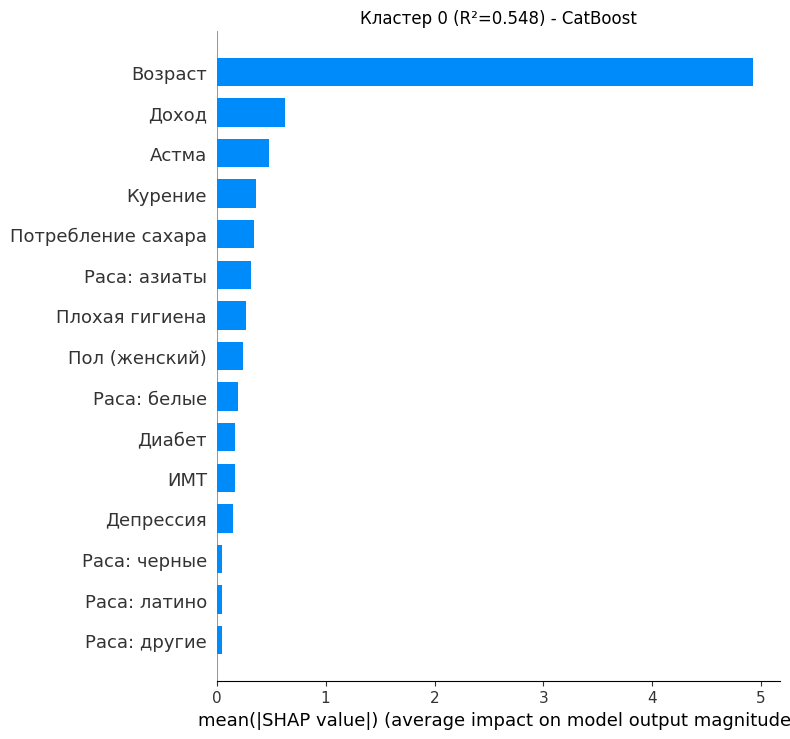

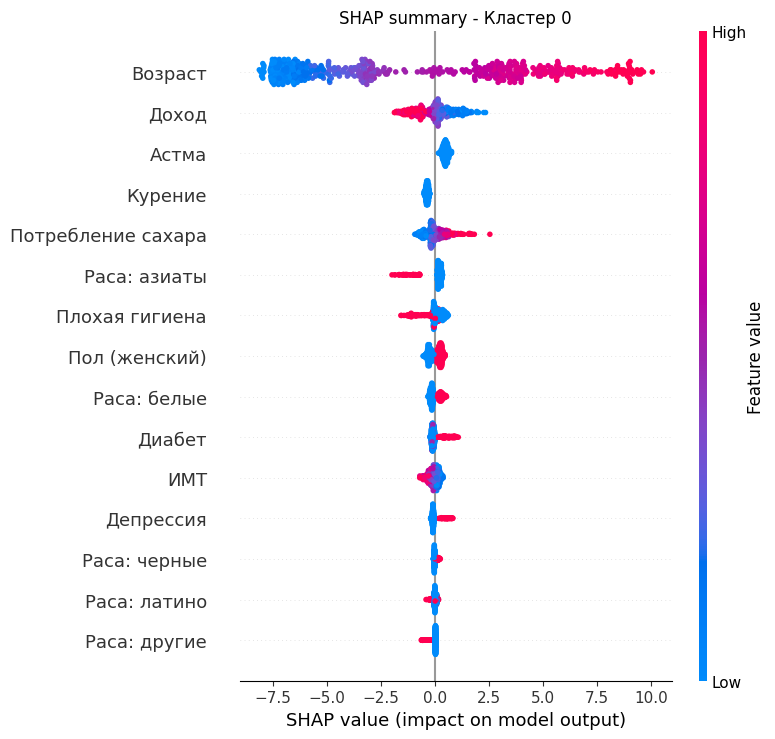


    ТОП-5 ВАЖНЫХ ПРИЗНАКОВ:
      Возраст: 4.9266
      Доход: 0.6301
      Астма: 0.4796
      Курение: 0.3636
      Потребление сахара: 0.3441

КЛАСТЕР 1 (R²=0.5320, MAE=4.2887)
Модель: XGBoost, Тип: global_on_cluster
    Используется 500 образцов


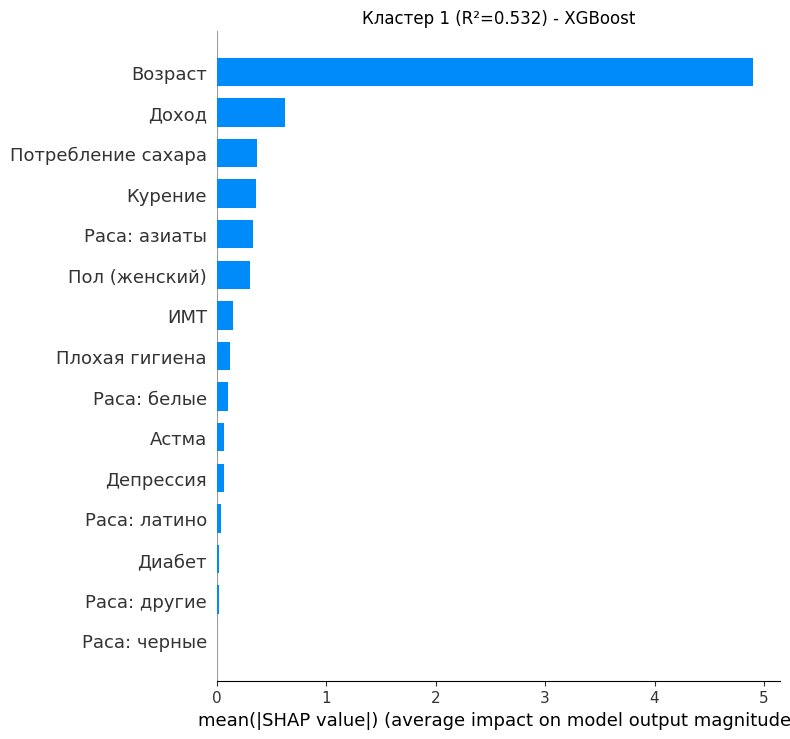

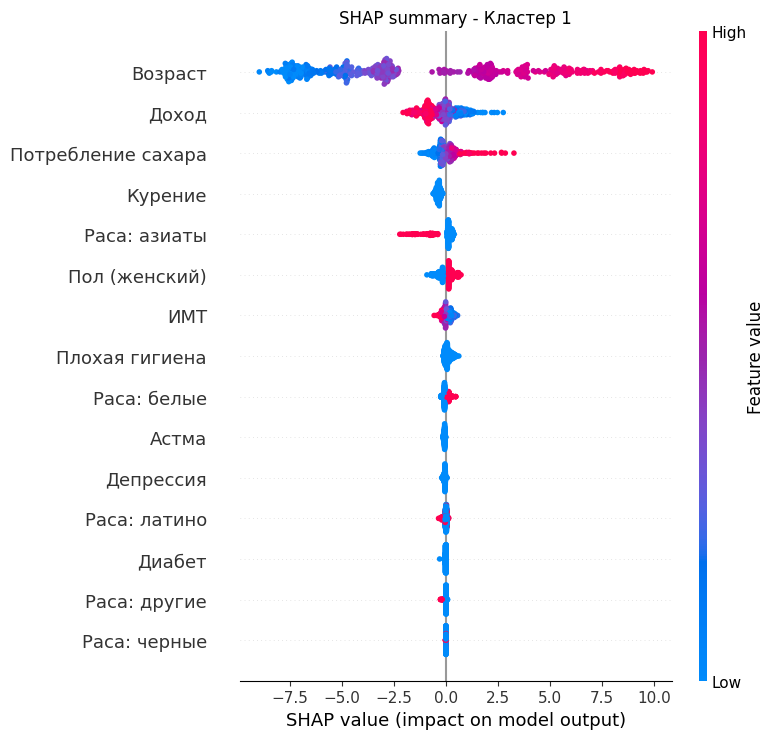


    ТОП-5 ВАЖНЫХ ПРИЗНАКОВ:
      Возраст: 4.9013
      Доход: 0.6206
      Потребление сахара: 0.3635
      Курение: 0.3545
      Раса: азиаты: 0.3304

КЛАСТЕР 2 (R²=0.3632, MAE=4.7934)
Модель: XGBoost, Тип: global_on_cluster


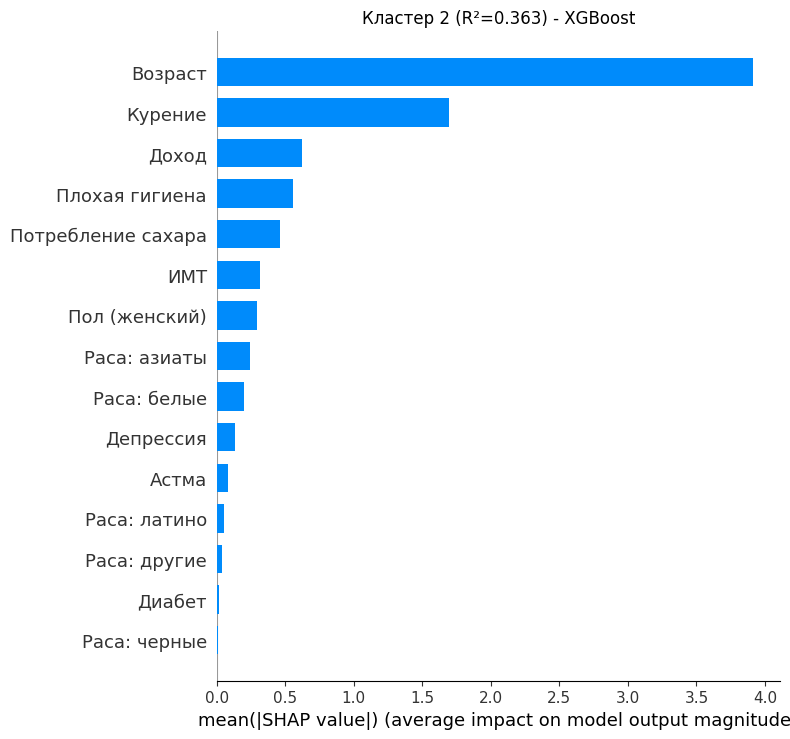

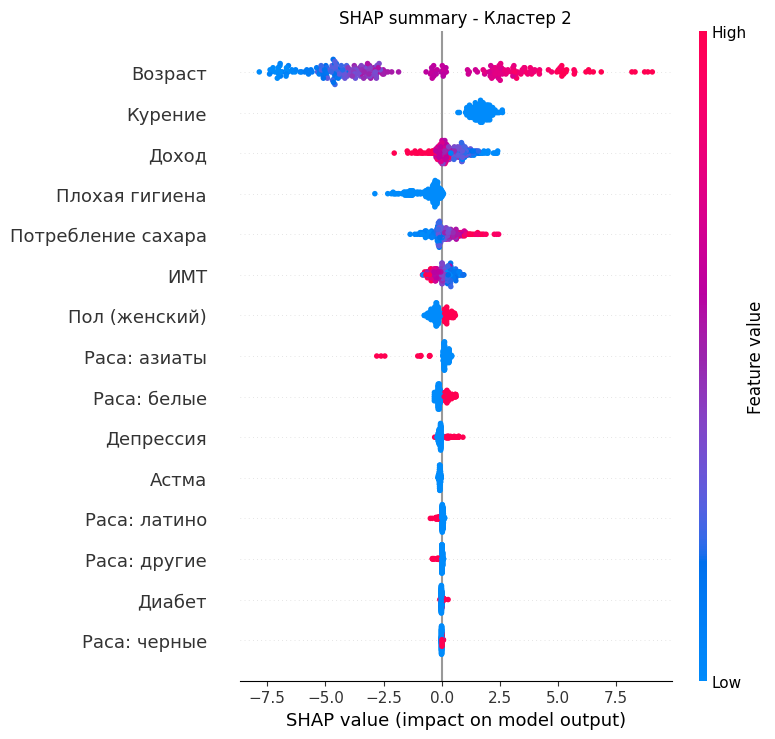


    ТОП-5 ВАЖНЫХ ПРИЗНАКОВ:
      Возраст: 3.9135
      Курение: 1.6914
      Доход: 0.6185
      Плохая гигиена: 0.5531
      Потребление сахара: 0.4600

КЛАСТЕР 3 (R²=0.4881, MAE=4.4803)
Модель: CatBoost, Тип: global_on_cluster
    Используется 500 образцов


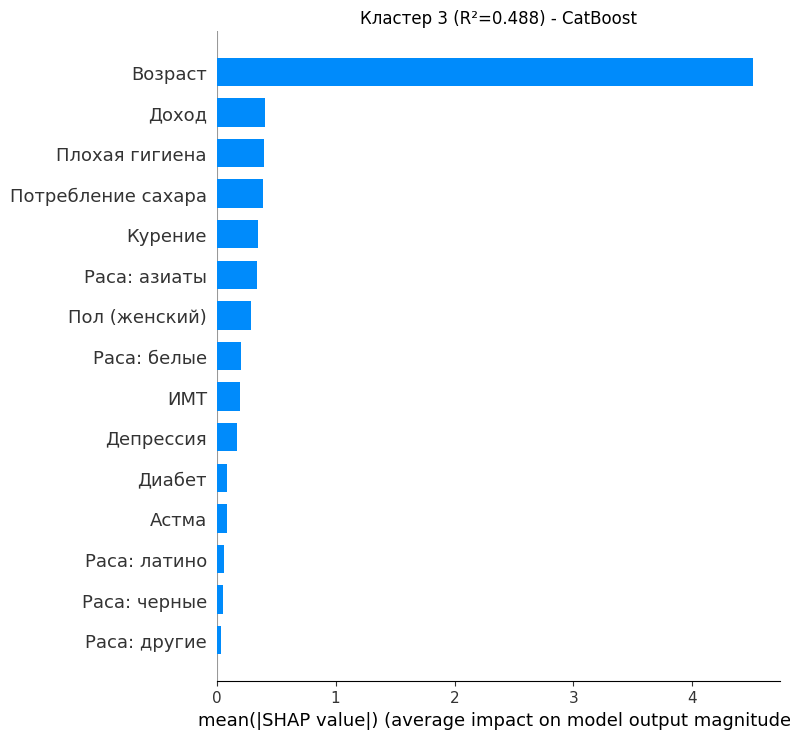

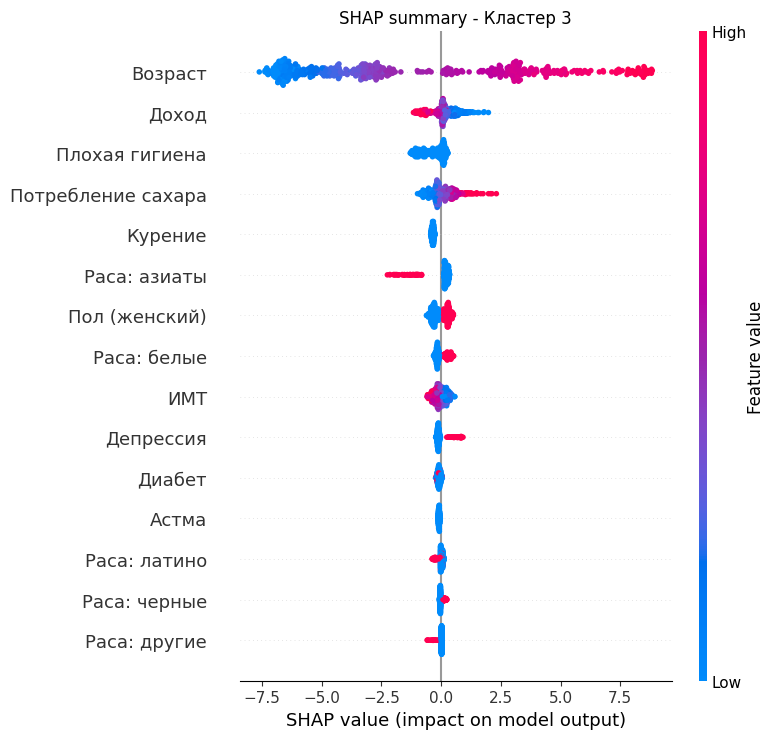


    ТОП-5 ВАЖНЫХ ПРИЗНАКОВ:
      Возраст: 4.5121
      Доход: 0.4079
      Плохая гигиена: 0.3944
      Потребление сахара: 0.3885
      Курение: 0.3460

КЛАСТЕР 4 (R²=0.4055, MAE=5.6266)
Модель: LightGBM, Тип: global_on_cluster


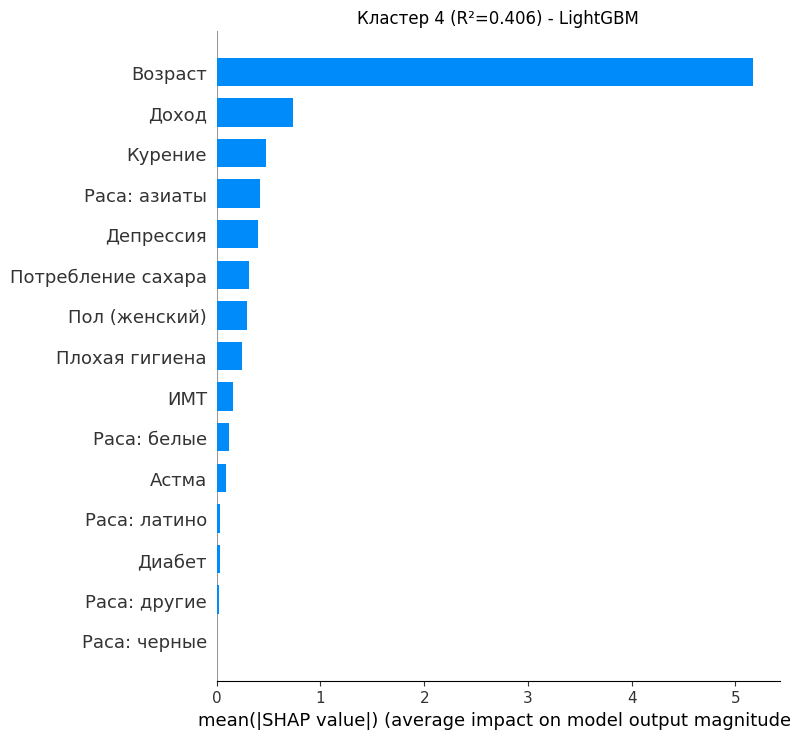

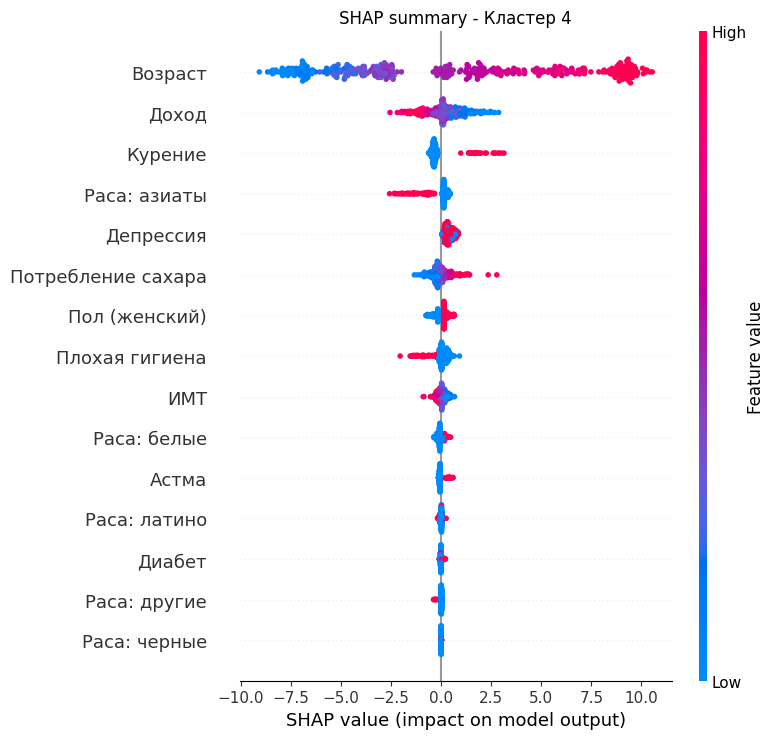


    ТОП-5 ВАЖНЫХ ПРИЗНАКОВ:
      Возраст: 5.1706
      Доход: 0.7312
      Курение: 0.4765
      Раса: азиаты: 0.4124
      Депрессия: 0.4020

КЛАСТЕР 5 (R²=0.4183, MAE=5.0566)
Модель: CatBoost, Тип: global_on_cluster
    Используется 500 образцов


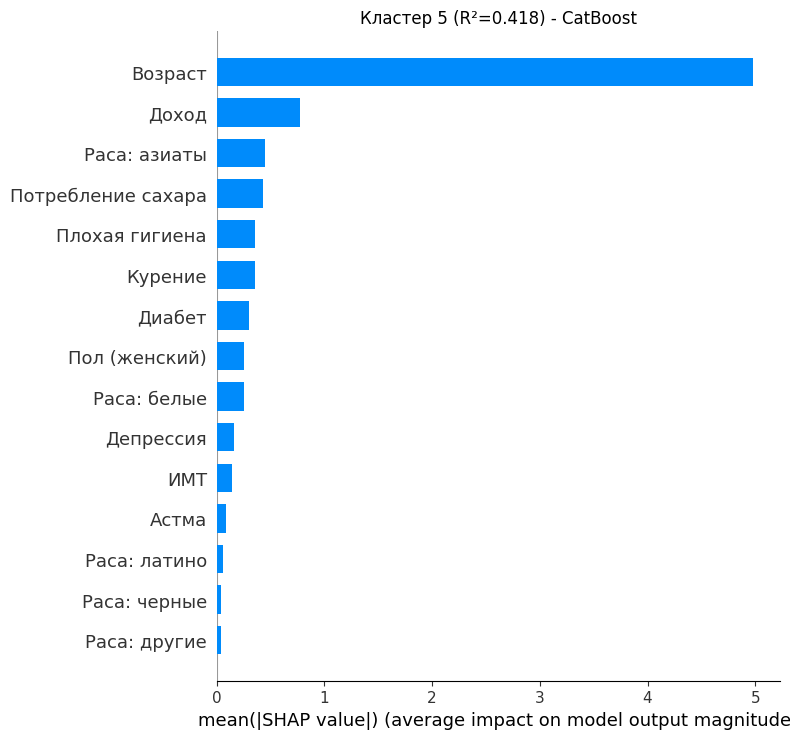

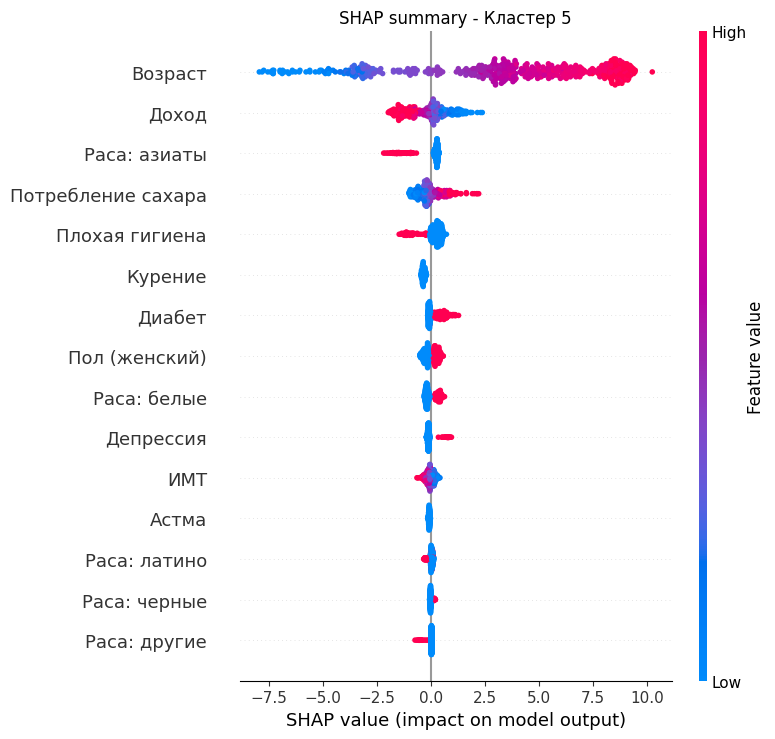


    ТОП-5 ВАЖНЫХ ПРИЗНАКОВ:
      Возраст: 4.9808
      Доход: 0.7707
      Раса: азиаты: 0.4506
      Потребление сахара: 0.4257
      Плохая гигиена: 0.3592

КЛАСТЕР 6 (R²=0.4814, MAE=5.7124)
Модель: CatBoost, Тип: global_on_cluster


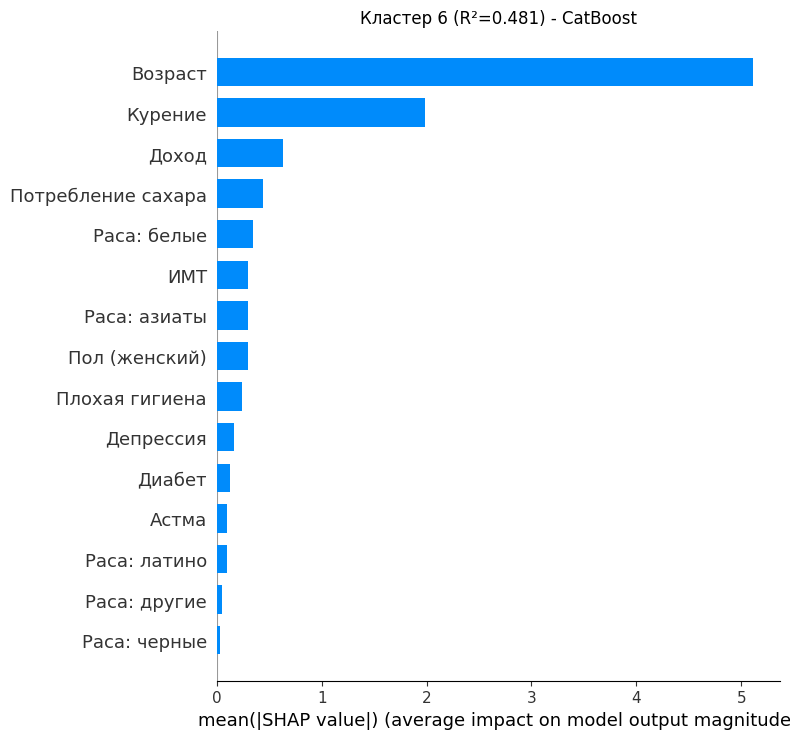

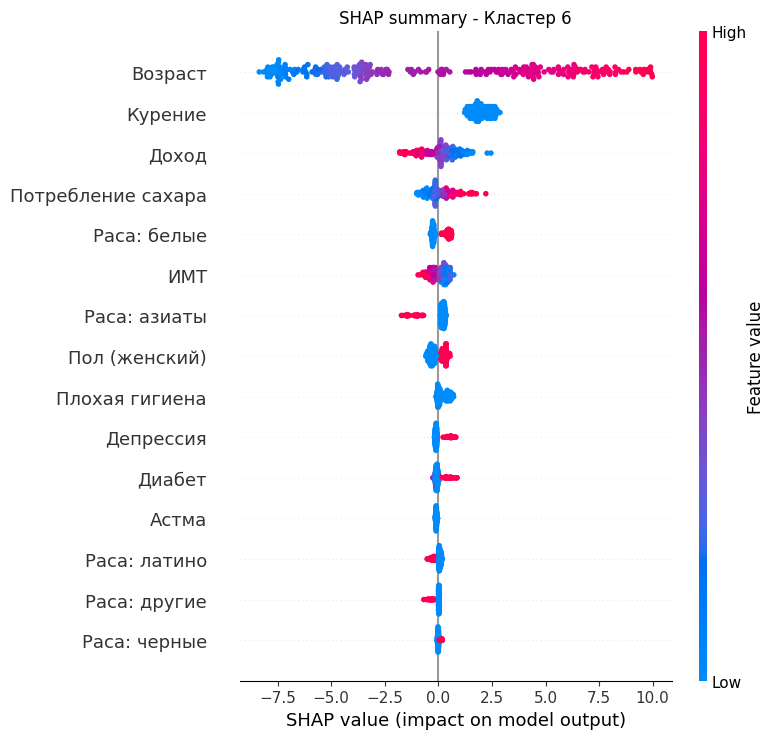


    ТОП-5 ВАЖНЫХ ПРИЗНАКОВ:
      Возраст: 5.1129
      Курение: 1.9883
      Доход: 0.6293
      Потребление сахара: 0.4366
      Раса: белые: 0.3438

КЛАСТЕР 7 (R²=0.5130, MAE=4.1195)
Модель: StackingRegressor, Тип: global_on_cluster
    StackingRegressor → усреднение SHAP базовых моделей


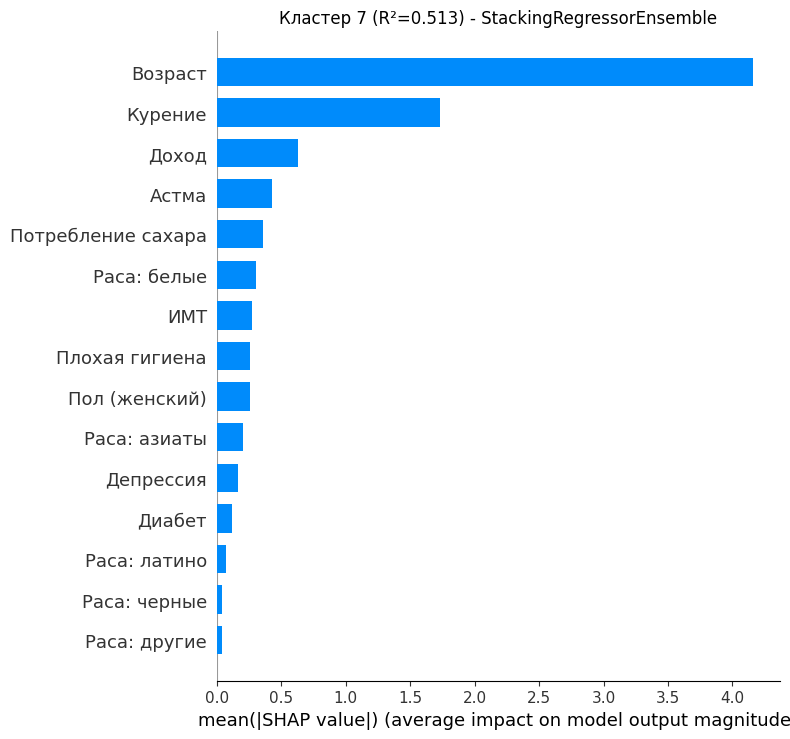

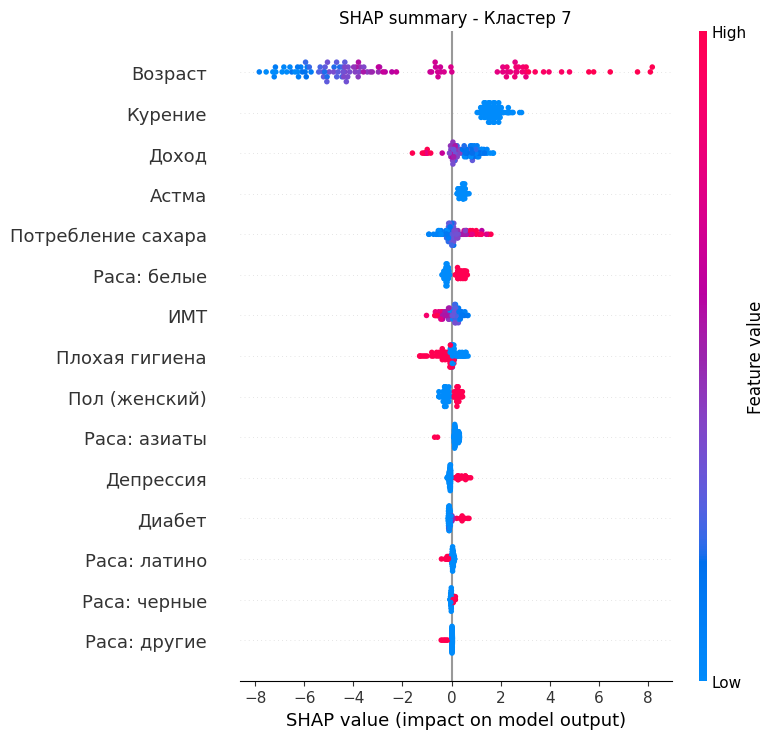


    ТОП-5 ВАЖНЫХ ПРИЗНАКОВ:
      Возраст: 4.1606
      Курение: 1.7282
      Доход: 0.6336
      Астма: 0.4297
      Потребление сахара: 0.3566

 SHAP-анализ для DMFT завершён


In [34]:
# ============================================================================
# 4.1: SHAP-АНАЛИЗ ДЛЯ DMFT
# ============================================================================
print("="*80)
print("4.1: SHAP-АНАЛИЗ ДЛЯ DMFT")
print("="*80)

MAX_SAMPLES = 500

# Загрузка данных
print("\nЗагрузка данных...")
models_dict = joblib.load('../models/trained/all_models_dmft_dictionary.pkl')
df = pd.read_csv('../data/processed/dataset_v1_drop_with_clusters.csv')

FEATURES = ['age', 'gender', 'income_ratio', 'race_asian', 'race_black', 'race_latino', 
            'race_white', 'race_other', 'bmi', 'diabetes', 'asthma', 'depression',
            'sugar_avg', 'smoking_status', 'poor_hygiene']

FEATURE_NAMES_RU = {
    'age': 'Возраст', 'gender': 'Пол (женский)', 'income_ratio': 'Доход',
    'race_asian': 'Раса: азиаты', 'race_black': 'Раса: черные', 'race_latino': 'Раса: латино',
    'race_white': 'Раса: белые', 'race_other': 'Раса: другие', 'bmi': 'ИМТ',
    'diabetes': 'Диабет', 'asthma': 'Астма', 'depression': 'Депрессия',
    'sugar_avg': 'Потребление сахара', 'smoking_status': 'Курение', 'poor_hygiene': 'Плохая гигиена'
}

best_models = pd.read_csv('../results/models/best_models_dmft_gridsearch.csv')
best_models = best_models[best_models['dataset'] == 'v1_drop']
print("\nЛучшие модели для каждого кластера:")
print(best_models[['cluster', 'best_model', 'type', 'r2']].to_string())

os.makedirs('../results/shap_plots', exist_ok=True)

for _, row in best_models.iterrows():
    cid, name, typ, r2 = row['cluster'], row['best_model'], row['type'], row['r2']
    print(f"\n{'='*60}\nКЛАСТЕР {cid} (R²={r2:.4f}, MAE={row['mae']:.4f})\nМодель: {name}, Тип: {typ}")
    
    # Подготовка данных
    X_cluster = df[df['cluster'] == cid][FEATURES].astype(float)
    if len(X_cluster) > MAX_SAMPLES:
        X_cluster = X_cluster.sample(MAX_SAMPLES, random_state=42)
        print(f"    Используется {MAX_SAMPLES} образцов")
    
    # Получение SHAP значений
    if name in ['VotingRegressor', 'StackingRegressor']:
        print(f"    {name} → усреднение SHAP базовых моделей")
        shap_list = []
        for base in ['RandomForest', 'CatBoost', 'XGBoost', 'LightGBM']:
            key = f"v1_drop_global_{base}" if typ == 'global_on_cluster' else f"v1_drop_cluster{cid}_{base}"
            if key in models_dict:
                try:
                    shap_val = shap.TreeExplainer(models_dict[key]).shap_values(X_cluster)
                    shap_list.append(shap_val[0] if isinstance(shap_val, list) else shap_val)
                except: pass
        shap_values = np.mean(shap_list, axis=0) if shap_list else None
        use_name = f"{name}Ensemble"
    else:
        key = f"v1_drop_global_{name}" if typ == 'global_on_cluster' else f"v1_drop_cluster{cid}_{name}"
        if key not in models_dict:
            print(f"    Модель не найдена: {key}")
            continue
        shap_values = shap.TreeExplainer(models_dict[key]).shap_values(X_cluster)
        if isinstance(shap_values, list):
            shap_values = shap_values[0]
        use_name = name
    
    if shap_values is None:
        continue
    
    # Графики
    X_renamed = X_cluster.rename(columns=FEATURE_NAMES_RU)
    
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_renamed, plot_type="bar", show=False, max_display=15)
    plt.title(f'Кластер {cid} (R²={r2:.3f}) - {use_name}')
    plt.tight_layout()
    plt.savefig(f'../results/shap_plots/shap_cluster_{cid}_bar.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_renamed, show=False, max_display=15)
    plt.title(f'SHAP summary - Кластер {cid}')
    plt.tight_layout()
    plt.savefig(f'../results/shap_plots/shap_cluster_{cid}_summary.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # Важность признаков
    imp = np.abs(shap_values).mean(axis=0)
    sorted_idx = np.argsort(imp)[::-1][:10]
    print(f"\n    ТОП-5 ВАЖНЫХ ПРИЗНАКОВ:")
    for i in sorted_idx[:5]:
        print(f"      {FEATURE_NAMES_RU[FEATURES[i]]}: {imp[i]:.4f}")

print("\n" + "="*80)
print(" SHAP-анализ для DMFT завершён")
print("="*80)

4.2: SHAP-АНАЛИЗ ДЛЯ ACTIVE_CARIES

Загрузка данных...

Лучшие модели для каждого кластера:
   cluster          best_model               type    auc     f1
0        0    VotingClassifier  global_on_cluster 0.9185 0.7097
1        1            CatBoost  global_on_cluster 0.7329 0.0000
2        2        RandomForest  global_on_cluster 0.7138 0.8148
3        3        RandomForest  global_on_cluster 0.6779 0.6718
4        4            CatBoost  global_on_cluster 0.9945 0.9333
5        5        RandomForest            cluster 0.9688 0.8182
6        6  StackingClassifier  global_on_cluster 0.9211 0.0000
7        7             XGBoost  global_on_cluster 0.9286 0.8750

КЛАСТЕР 0 (AUC=0.9185)
Модель: VotingClassifier, Тип: global_on_cluster
    VotingClassifier → усреднение SHAP базовых моделей


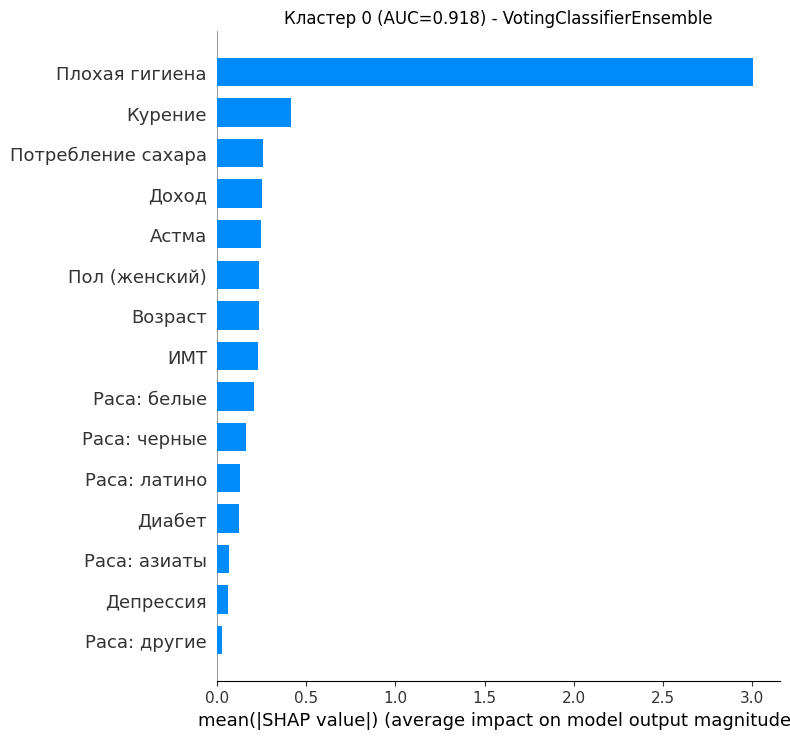

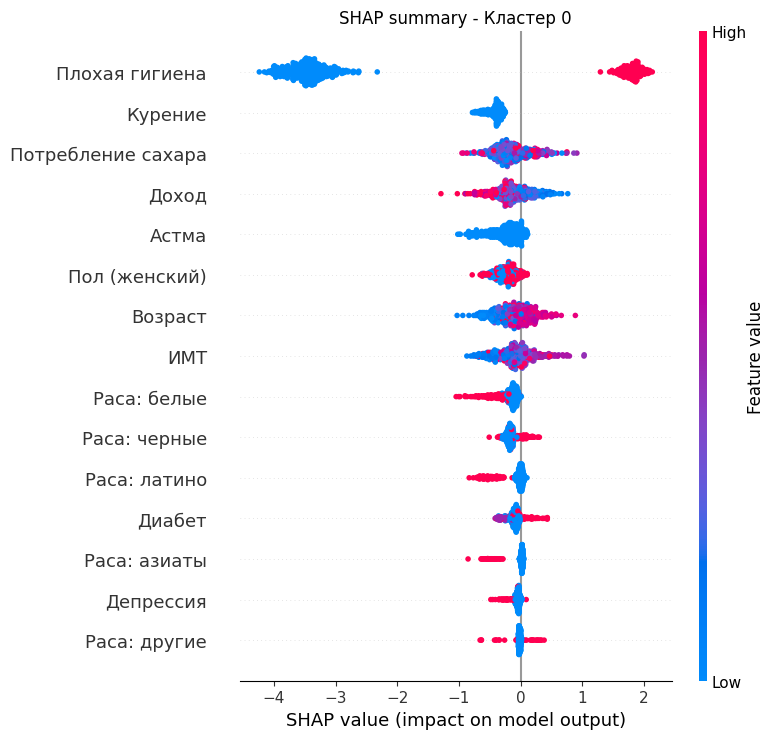


    ТОП-5 ВАЖНЫХ ПРИЗНАКОВ:
      Плохая гигиена: 3.0048
      Курение: 0.4143
      Потребление сахара: 0.2568
      Доход: 0.2525
      Астма: 0.2498

КЛАСТЕР 1 (AUC=0.7329)
Модель: CatBoost, Тип: global_on_cluster
    Используется 500 образцов


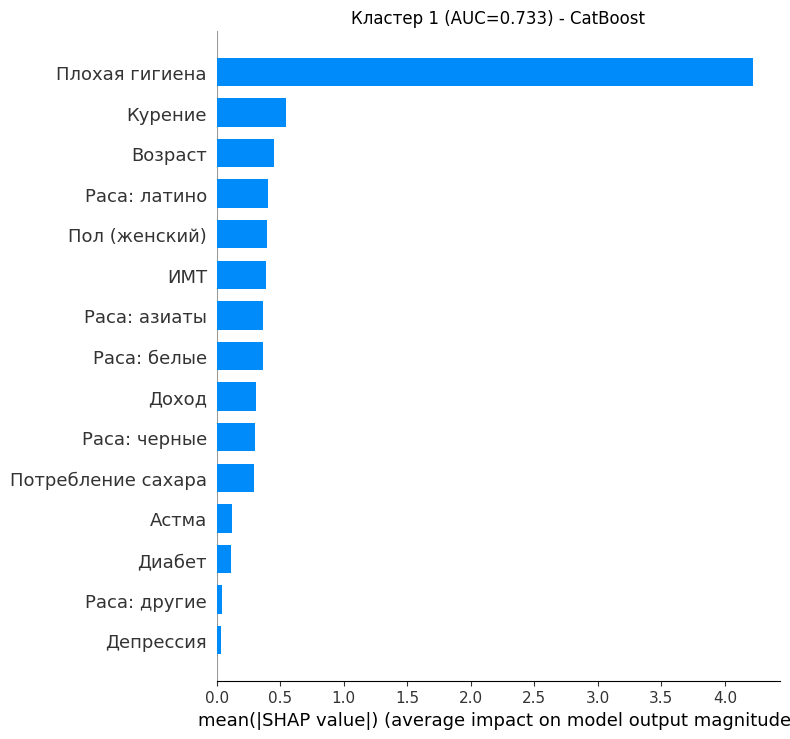

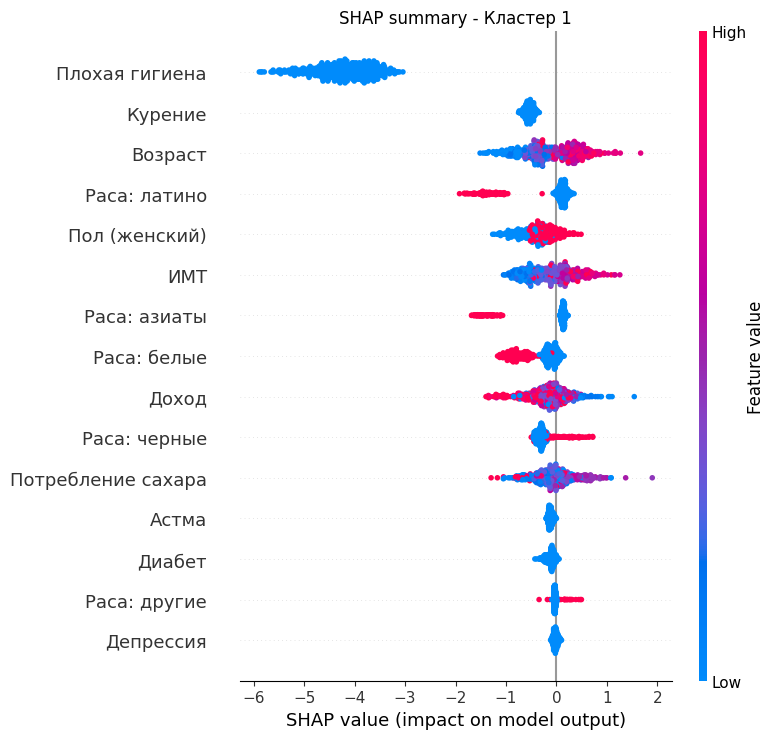


    ТОП-5 ВАЖНЫХ ПРИЗНАКОВ:
      Плохая гигиена: 4.2227
      Курение: 0.5442
      Возраст: 0.4500
      Раса: латино: 0.4070
      Пол (женский): 0.3940

КЛАСТЕР 2 (AUC=0.7138)
Модель: RandomForest, Тип: global_on_cluster


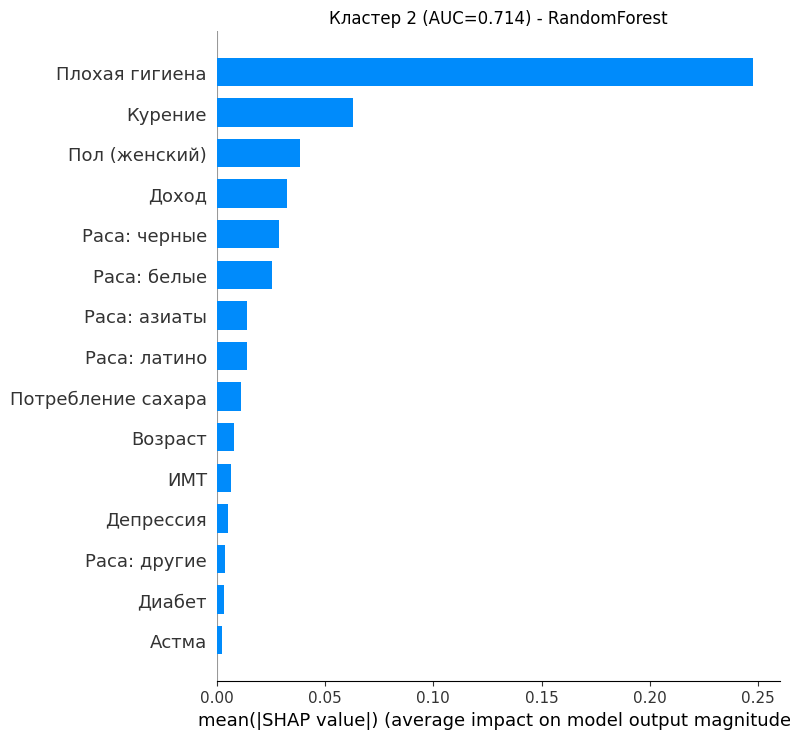

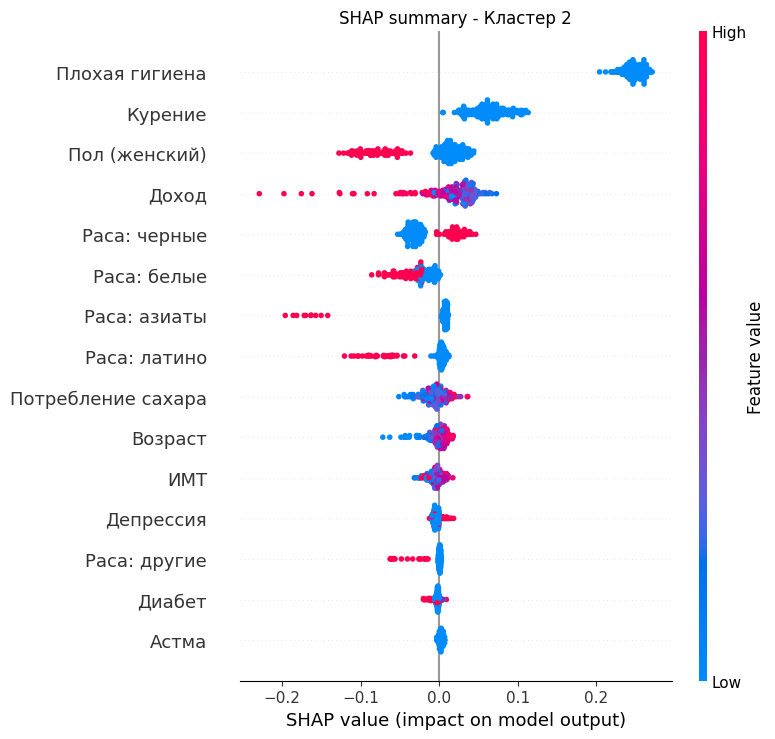


    ТОП-5 ВАЖНЫХ ПРИЗНАКОВ:
      Плохая гигиена: 0.2477
      Курение: 0.0627
      Пол (женский): 0.0383
      Доход: 0.0322
      Раса: черные: 0.0287

КЛАСТЕР 3 (AUC=0.6779)
Модель: RandomForest, Тип: global_on_cluster
    Используется 500 образцов


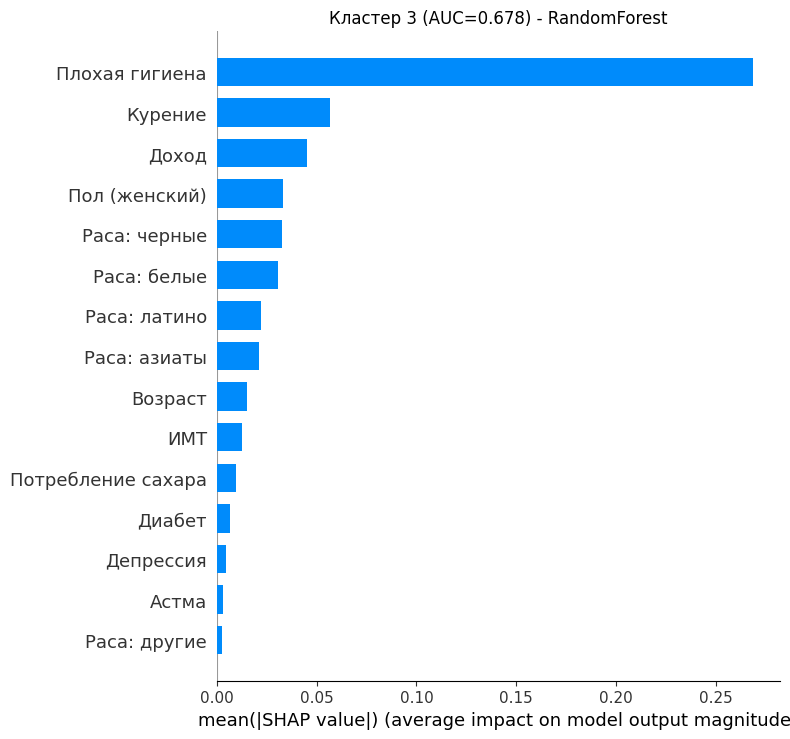

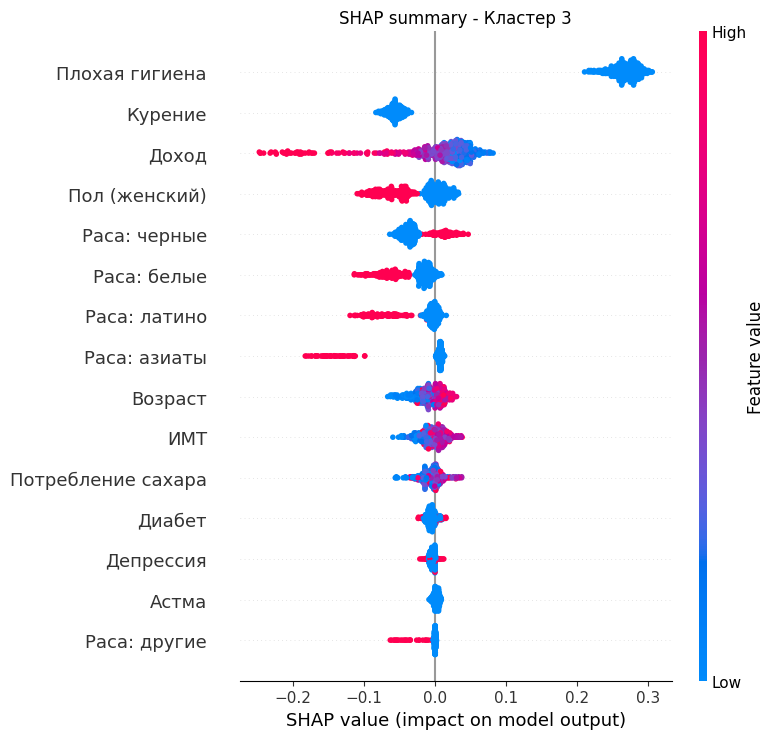


    ТОП-5 ВАЖНЫХ ПРИЗНАКОВ:
      Плохая гигиена: 0.2686
      Курение: 0.0568
      Доход: 0.0453
      Пол (женский): 0.0332
      Раса: черные: 0.0325

КЛАСТЕР 4 (AUC=0.9945)
Модель: CatBoost, Тип: global_on_cluster


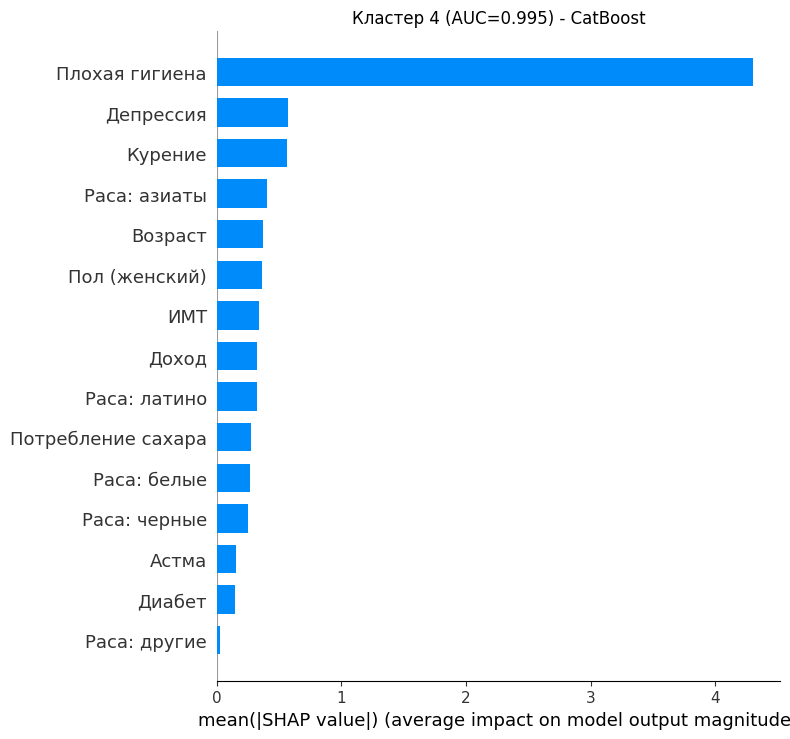

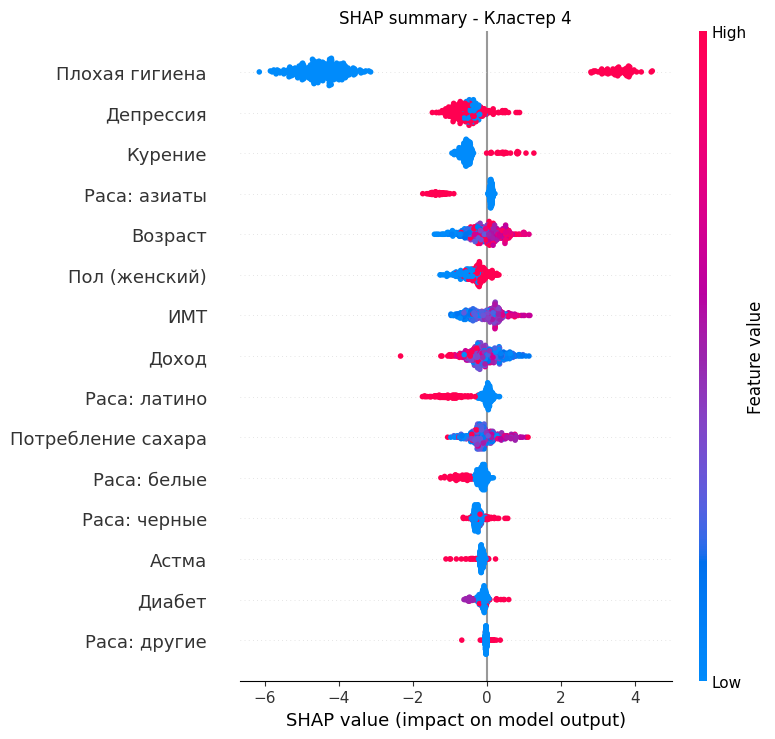


    ТОП-5 ВАЖНЫХ ПРИЗНАКОВ:
      Плохая гигиена: 4.3045
      Депрессия: 0.5691
      Курение: 0.5675
      Раса: азиаты: 0.4038
      Возраст: 0.3687

КЛАСТЕР 5 (AUC=0.9688)
Модель: RandomForest, Тип: cluster
    Используется 500 образцов


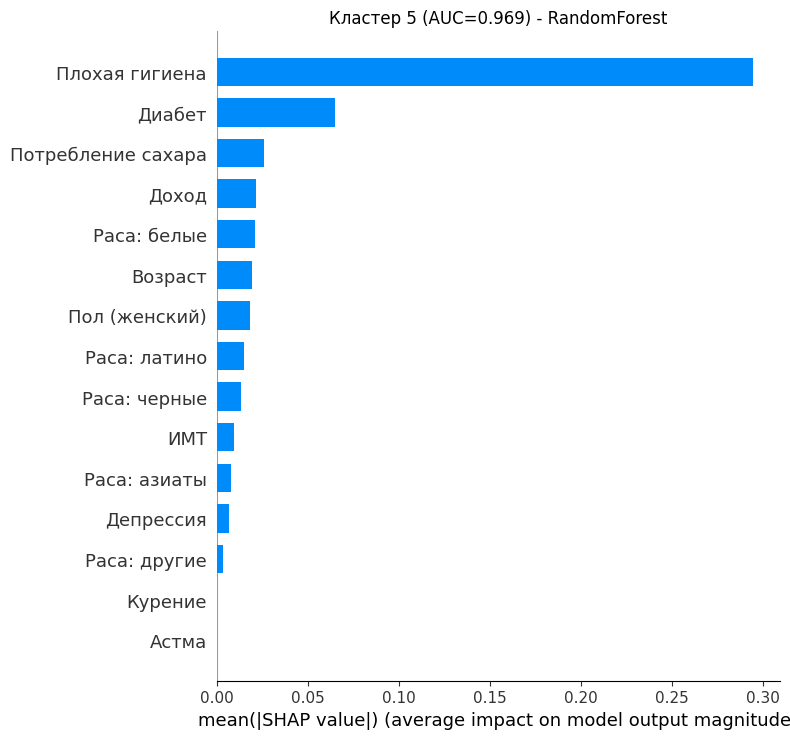

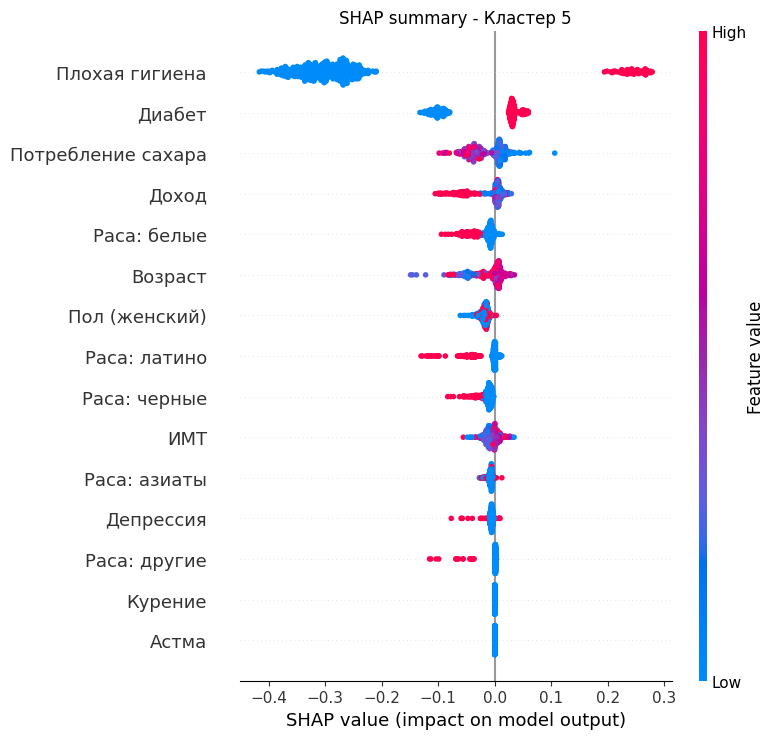


    ТОП-5 ВАЖНЫХ ПРИЗНАКОВ:
      Плохая гигиена: 0.2947
      Диабет: 0.0652
      Потребление сахара: 0.0258
      Доход: 0.0215
      Раса: белые: 0.0212

КЛАСТЕР 6 (AUC=0.9211)
Модель: StackingClassifier, Тип: global_on_cluster
    StackingClassifier → усреднение SHAP базовых моделей


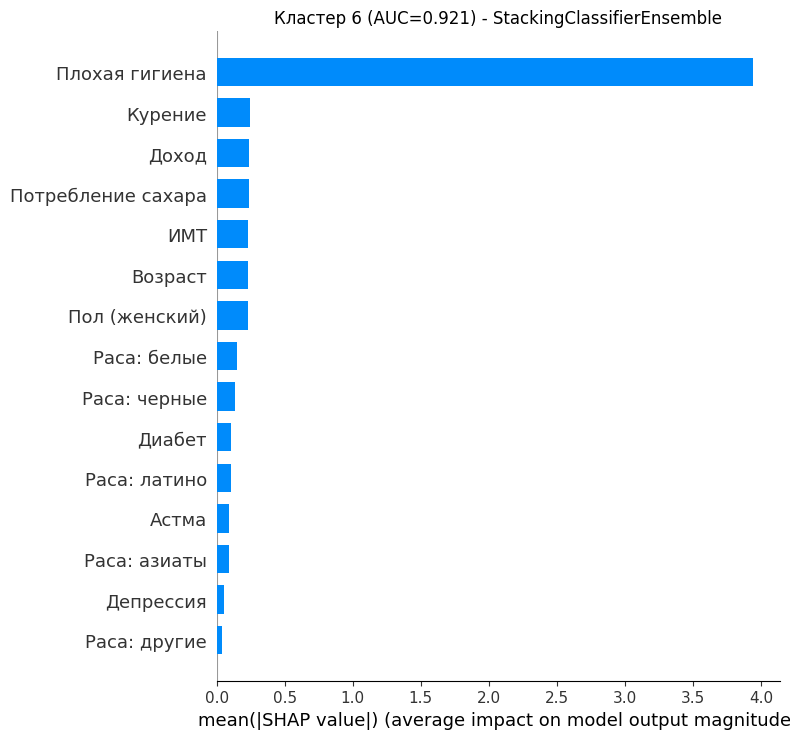

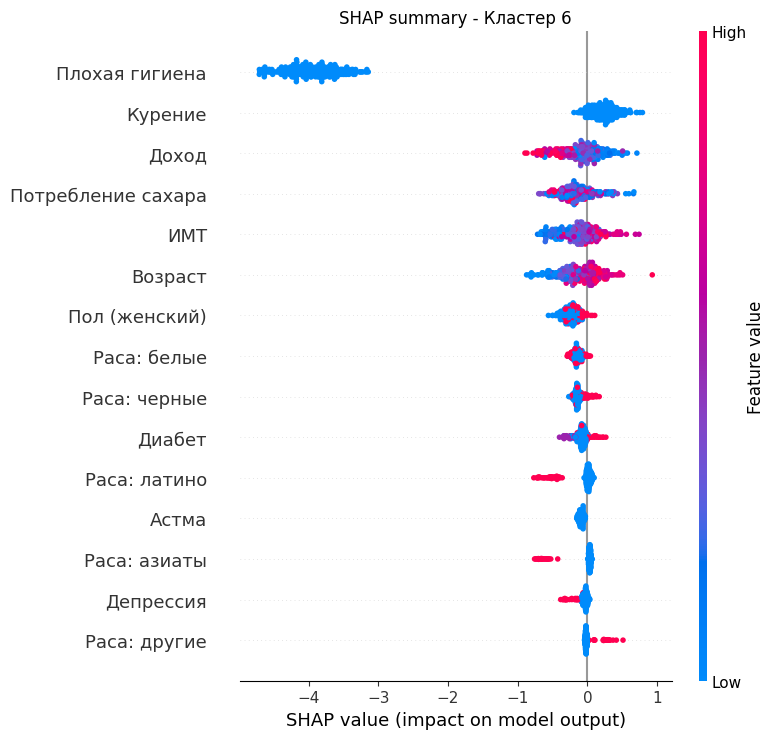


    ТОП-5 ВАЖНЫХ ПРИЗНАКОВ:
      Плохая гигиена: 3.9426
      Курение: 0.2460
      Доход: 0.2399
      Потребление сахара: 0.2373
      ИМТ: 0.2331

КЛАСТЕР 7 (AUC=0.9286)
Модель: XGBoost, Тип: global_on_cluster


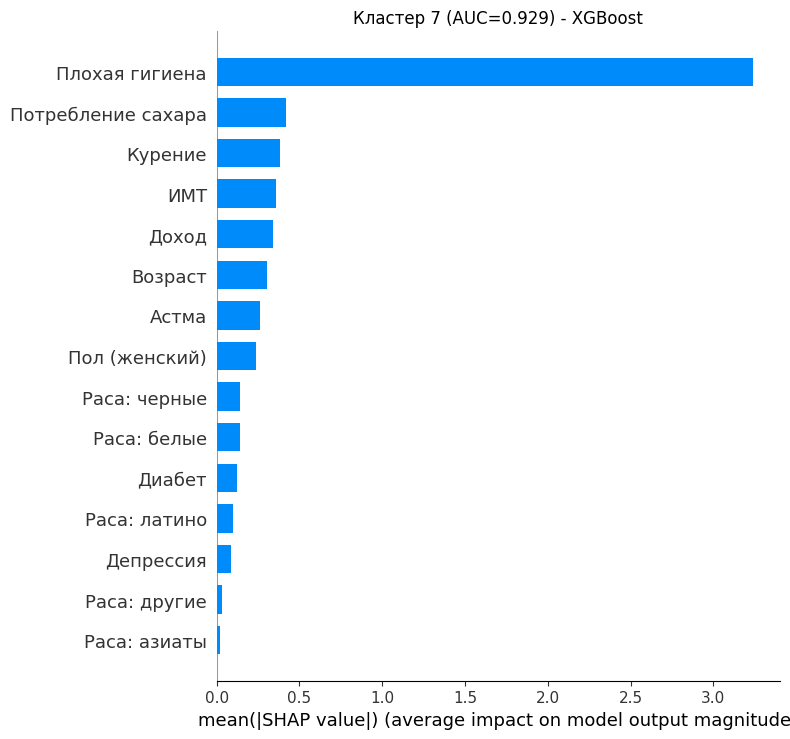

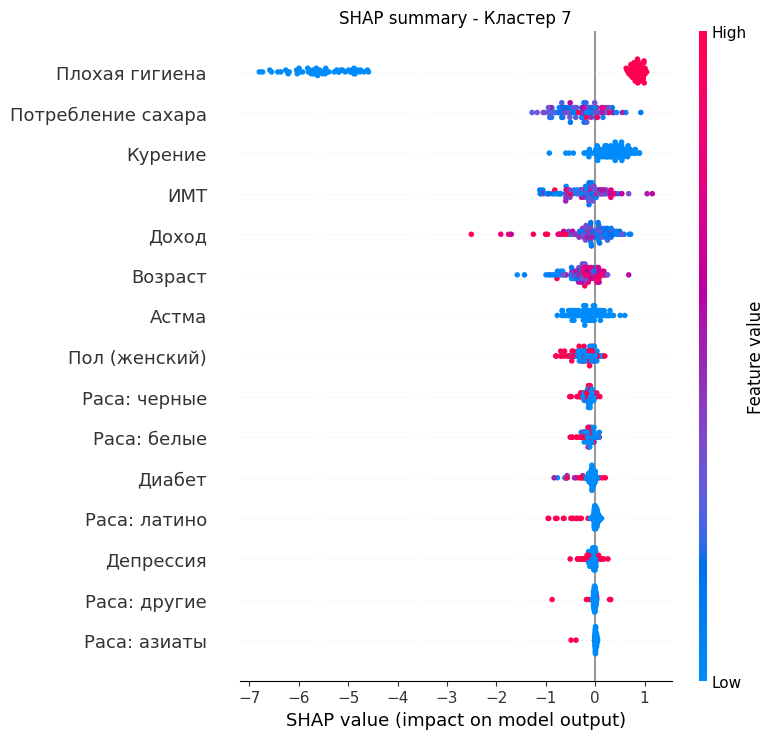


    ТОП-5 ВАЖНЫХ ПРИЗНАКОВ:
      Плохая гигиена: 3.2404
      Потребление сахара: 0.4197
      Курение: 0.3851
      ИМТ: 0.3561
      Доход: 0.3414

 SHAP-анализ для ACTIVE_CARIES завершён


In [35]:
# ============================================================================
# 4.2: SHAP-АНАЛИЗ ДЛЯ ACTIVE_CARIES
# ============================================================================
print("="*80)
print("4.2: SHAP-АНАЛИЗ ДЛЯ ACTIVE_CARIES")
print("="*80)

import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

MAX_SAMPLES = 500

# Загрузка данных
print("\nЗагрузка данных...")
models_dict = joblib.load('../models/trained/all_models_ac_dictionary.pkl')
df = pd.read_csv('../data/processed/dataset_v1_drop_with_clusters.csv')

FEATURES = ['age', 'gender', 'income_ratio', 'race_asian', 'race_black', 'race_latino', 
            'race_white', 'race_other', 'bmi', 'diabetes', 'asthma', 'depression',
            'sugar_avg', 'smoking_status', 'poor_hygiene']

FEATURE_NAMES_RU = {
    'age': 'Возраст', 'gender': 'Пол (женский)', 'income_ratio': 'Доход',
    'race_asian': 'Раса: азиаты', 'race_black': 'Раса: черные', 'race_latino': 'Раса: латино',
    'race_white': 'Раса: белые', 'race_other': 'Раса: другие', 'bmi': 'ИМТ',
    'diabetes': 'Диабет', 'asthma': 'Астма', 'depression': 'Депрессия',
    'sugar_avg': 'Потребление сахара', 'smoking_status': 'Курение', 'poor_hygiene': 'Плохая гигиена'
}

best_models = pd.read_csv('../results/models/best_models_active_caries_gridsearch.csv')
best_models = best_models[best_models['dataset'] == 'v1_drop']
print("\nЛучшие модели для каждого кластера:")
print(best_models[['cluster', 'best_model', 'type', 'auc', 'f1']].to_string())

os.makedirs('../results/shap_plots_ac', exist_ok=True)

def get_shap_for_class1(shap_raw):
    """Извлекает SHAP для класса 1 (кариес)"""
    
    # Случай 1: XGBoost/LightGBM → 3D массив (образцы, признаки, классы)
    if hasattr(shap_raw, 'shape') and len(shap_raw.shape) == 3 and shap_raw.shape[2] == 2:
        return shap_raw[:, :, 1]# Берём срез для класса 1 (кариес)

    # Случай 2: RandomForest → список из 2 элементов
    if isinstance(shap_raw, list) and len(shap_raw) == 2:
        return shap_raw[1]

    # Случай 3: CatBoost → уже готовый 2D массив для класса 1
    return shap_raw

for _, row in best_models.iterrows():
    cid, name, typ, auc_val = row['cluster'], row['best_model'], row['type'], row['auc']
    print(f"\n{'='*60}\nКЛАСТЕР {cid} (AUC={auc_val:.4f})\nМодель: {name}, Тип: {typ}")
    
    # Подготовка данных
    X_cluster = df[df['cluster'] == cid][FEATURES].astype(float)
    if len(X_cluster) > MAX_SAMPLES:
        X_cluster = X_cluster.sample(MAX_SAMPLES, random_state=42)
        print(f"    Используется {MAX_SAMPLES} образцов")
    
    # Получение SHAP значений
    if name in ['VotingClassifier', 'StackingClassifier']:
        print(f"    {name} → усреднение SHAP базовых моделей")
        shap_list = []
        for base in ['RandomForest', 'CatBoost', 'XGBoost', 'LightGBM']:
            key = f"v1_drop_global_{base}" if typ == 'global_on_cluster' else f"v1_drop_cluster{cid}_{base}"
            if key in models_dict:
                try:
                    shap_val = shap.TreeExplainer(models_dict[key]).shap_values(X_cluster)
                    shap_list.append(get_shap_for_class1(shap_val))
                except: pass
        shap_values = np.mean(shap_list, axis=0) if shap_list else None
        use_name = f"{name}Ensemble"
    else:
        key = f"v1_drop_global_{name}" if typ == 'global_on_cluster' else f"v1_drop_cluster{cid}_{name}"
        if key not in models_dict:
            print(f"    Модель не найдена: {key}")
            continue
        shap_raw = shap.TreeExplainer(models_dict[key]).shap_values(X_cluster)
        shap_values = get_shap_for_class1(shap_raw)
        use_name = name
    
    if shap_values is None or shap_values.ndim != 2:
        continue
    
    # Графики
    X_renamed = X_cluster.rename(columns=FEATURE_NAMES_RU)
    
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_renamed, plot_type="bar", show=False, max_display=15)
    plt.title(f'Кластер {cid} (AUC={auc_val:.3f}) - {use_name}')
    plt.tight_layout()
    plt.savefig(f'../results/shap_plots_ac/shap_cluster_{cid}_bar.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_renamed, show=False, max_display=15)
    plt.title(f'SHAP summary - Кластер {cid}')
    plt.tight_layout()
    plt.savefig(f'../results/shap_plots_ac/shap_cluster_{cid}_summary.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # Важность признаков
    imp = np.abs(shap_values).mean(axis=0)
    sorted_idx = np.argsort(imp)[::-1][:10]
    print(f"\n    ТОП-5 ВАЖНЫХ ПРИЗНАКОВ:")
    for i in sorted_idx[:5]:
        print(f"      {FEATURE_NAMES_RU[FEATURES[i]]}: {imp[i]:.4f}")

print("\n" + "="*80)
print(" SHAP-анализ для ACTIVE_CARIES завершён")
print("="*80)

In [36]:
# ============================================================================
# ЯЧЕЙКА 4.3: ЗАГРУЗКА ДАННЫХ И МОДЕЛЕЙ ДЛЯ WHAT-IF СИМУЛЯТОРА
# ============================================================================

print("="*80)
print("4.3: ЗАГРУЗКА ДАННЫХ И МОДЕЛЕЙ")
print("="*80)

df = pd.read_csv('../data/processed/dataset_v1_drop_with_clusters.csv')

# ============================================================================
# 1. МОДЕЛИ КЛАСТЕРИЗАЦИИ
# ============================================================================
scaler_cluster = joblib.load('../models/scaler_v1_drop.pkl')
kmeans = joblib.load('../models/kmeans_v1_drop.pkl')

# ============================================================================
# 2. ЛУЧШИЕ МОДЕЛИ ПО ТАБЛИЦАМ
# ============================================================================
best_dmft = pd.read_csv('../results/models/best_models_dmft_gridsearch.csv')
best_ac = pd.read_csv('../results/models/best_models_active_caries_gridsearch.csv')
best_dmft = best_dmft[best_dmft['dataset'] == 'v1_drop']
best_ac = best_ac[best_ac['dataset'] == 'v1_drop']

# ============================================================================
# 3. ПРИЗНАКИ
# ============================================================================
FEATURES = ['age', 'gender', 'income_ratio', 'race_asian', 'race_black', 'race_latino', 
            'race_white', 'race_other', 'bmi', 'diabetes', 'asthma', 'depression',
            'sugar_avg', 'smoking_status', 'poor_hygiene']

FEATURE_NAMES_RU = {
    'age': 'Возраст', 'gender': 'Пол (женский)', 'income_ratio': 'Доход',
    'race_asian': 'Раса: азиаты', 'race_black': 'Раса: черные', 'race_latino': 'Раса: латино',
    'race_white': 'Раса: белые', 'race_other': 'Раса: другие', 'bmi': 'ИМТ',
    'diabetes': 'Диабет', 'asthma': 'Астма', 'depression': 'Депрессия',
    'sugar_avg': 'Потребление сахара', 'smoking_status': 'Курение', 'poor_hygiene': 'Плохая гигиена'
}

# ============================================================================
# 4. ЗАГРУЗКА МОДЕЛЕЙ
# ============================================================================
dmft_dict = joblib.load('../models/trained/all_models_dmft_dictionary.pkl')
ac_dict = joblib.load('../models/trained/all_models_ac_dictionary.pkl')

dmft_models = {}
ac_models = {}

for _, row in best_dmft.iterrows():
    cid, name, typ = row['cluster'], row['best_model'], row['type']
    key = f"v1_drop_global_{name}" if typ == 'global_on_cluster' else f"v1_drop_cluster{cid}_{name}"
    dmft_models[cid] = dmft_dict.get(key)

for _, row in best_ac.iterrows():
    cid, name, typ = row['cluster'], row['best_model'], row['type']
    key = f"v1_drop_global_{name}" if typ == 'global_on_cluster' else f"v1_drop_cluster{cid}_{name}"
    ac_models[cid] = ac_dict.get(key)

# ============================================================================
# 5. SHAP EXPLAINERS
# ============================================================================
def get_explainers(models, base_dict, is_classification=False):
    explainers = {}
    base_models = ['RandomForest', 'CatBoost', 'XGBoost', 'LightGBM']
    for cid, model in models.items():
        if model is None: continue
        row = best_ac[best_ac['cluster'] == cid] if is_classification else best_dmft[best_dmft['cluster'] == cid]
        if len(row) == 0: continue
        name = row['best_model'].values[0]
        X_sample = df[df['cluster'] == cid][FEATURES].sample(min(500, len(df[df['cluster'] == cid])), random_state=42)
        
        try:
            if name in base_models:
                explainers[cid] = {'type': 'single', 'explainer': shap.TreeExplainer(model), 'X_sample': X_sample}
            elif name in ['VotingRegressor', 'StackingRegressor']:
                base_explainers = []
                typ = row['type'].values[0]
                for bn in base_models:
                    key = f"v1_drop_global_{bn}" if typ == 'global_on_cluster' else f"v1_drop_cluster{cid}_{bn}"
                    if key in base_dict:
                        base_explainers.append(shap.TreeExplainer(base_dict[key]))
                if base_explainers:
                    explainers[cid] = {'type': 'stacking', 'base_explainers': base_explainers, 'X_sample': X_sample}
        except:
            explainers[cid] = None
    return explainers

dmft_explainers = get_explainers(dmft_models, dmft_dict, is_classification=False)

# ============================================================================
# 6. ПАРАМЕТРЫ
# ============================================================================
cluster_mae = dict(zip(best_dmft['cluster'], best_dmft['mae']))

# Загружаем пороги из файла (сохранены в ячейке 3.6)
try:
    cluster_thresholds = joblib.load('../models/trained/cluster_thresholds_ac.pkl')
    print(f"\n Загружены пороги для {len(cluster_thresholds)} кластеров: {cluster_thresholds}")
except FileNotFoundError:
    print("\n Сluster_thresholds_ac.pkl не найден, используем порог 0.5")
    cluster_thresholds = {cid: 0.5 for cid in df['cluster'].unique()}

# ============================================================================
# 7. ИТОГ
# ============================================================================
print(f"\n Загружено: DMFT={sum(1 for m in dmft_models.values() if m)}/8, AC={sum(1 for m in ac_models.values() if m)}/8")
print(f" SHAP: DMFT={sum(1 for e in dmft_explainers.values() if e)}/8")

4.3: ЗАГРУЗКА ДАННЫХ И МОДЕЛЕЙ

 Загружены пороги для 8 кластеров: {0: 0.361, 1: 0.312, 2: 0.508, 3: 0.508, 4: 0.622, 5: 0.59, 6: 0.182, 7: 0.753}

 Загружено: DMFT=8/8, AC=8/8
 SHAP: DMFT=8/8


In [37]:
# ============================================================================
# ЯЧЕЙКА 4.4: ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ ДЛЯ WHAT-IF СИМУЛЯТОРА
# ============================================================================

print("="*80)
print("4.4: ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ")
print("="*80)

import pandas as pd
import numpy as np
import joblib
from scipy.stats import norm

# ============================================================================
# ПРИЗНАКИ ДЛЯ КЛАСТЕРИЗАЦИИ 
# ============================================================================

CLUSTER_FEATURES = ['diabetes', 'smoking_status', 'poor_hygiene', 'asthma', 'depression']

def get_cluster(patient_data):
    """Определяет кластер для пациента"""
    X_cluster = pd.DataFrame([patient_data])[CLUSTER_FEATURES].astype(float)
    X_scaled = scaler_cluster.transform(X_cluster)
    cluster = kmeans.predict(X_scaled)[0]
    return cluster
    
def predict_dmft(patient_data, cluster_id=None):
    """Предсказывает DMFT для пациента"""
    if cluster_id is None:
        cluster_id = get_cluster(patient_data)
    
    model = dmft_models.get(cluster_id)
    if model is None:
        print(f"Ошибка: нет модели DMFT для кластера {cluster_id}")
        return 0
    
    X = pd.DataFrame([patient_data])[FEATURES].astype(float)
    dmft = model.predict(X)[0]
    dmft = int(round(dmft))
    return max(0, min(dmft, 28))

def predict_future_dmft(patient_data, years_ahead, cluster_id=None):
    """
    ДЕМОНСТРАЦИОННЫЙ прогноз на основе возрастных трендов.
    Прогноз DMFT через years_ahead лет через разность предсказаний
    """
    if cluster_id is None:
        cluster_id = get_cluster(patient_data)
    
    # Текущий DMFT
    dmft_now = predict_dmft(patient_data, cluster_id)

    # Если уже все зубы поражены, прироста быть не может
    if dmft_now >= 28:
        return {
            'dmft_now': 28,
            'dmft_future': 28,
            'new_teeth': 0,
            'years_ahead': years_ahead,
            'cluster_id': cluster_id,
            'note': "DMFT достиг максимального значения (28 зубов)"
        }
    
    # Данные с будущим возрастом
    patient_future = patient_data.copy()
    patient_future['age'] = patient_data['age'] + years_ahead
    
    # Будущий DMFT
    dmft_future = predict_dmft(patient_future, cluster_id)

    # Будущий DMFT не может быть меньше текущего =====
    if dmft_future < dmft_now:
        dmft_future = dmft_now

    
    # Прирост не может быть отрицательным и не может превышать оставшиеся зубы
    remaining_teeth = 28 - dmft_now
    new_teeth = max(0, min(dmft_future - dmft_now, remaining_teeth))
    
    return {
        'dmft_now': dmft_now,
        'dmft_future': dmft_future,
        'new_teeth': new_teeth,
        'years_ahead': years_ahead,
        'cluster_id': cluster_id,
        'remaining_teeth': remaining_teeth
    }

def get_risk_thresholds(age):
    """
    Возвращает пороговые значения DMFT для категорий риска
    На основе клинических норм
    """
    if age <= 24:
        return {'low': 3.5, 'medium': 6.5, 'high': 9.0}
    elif age <= 34:
        return {'low': 5.0, 'medium': 9.5, 'high': 13.0}
    elif age <= 44:
        return {'low': 6.2, 'medium': 12.7, 'high': 16.2}
    elif age <= 54:
        return {'low': 8.0, 'medium': 15.0, 'high': 19.0}
    elif age <= 64:
        return {'low': 10.0, 'medium': 18.0, 'high': 22.0}
    else:  # 65+
        return {'low': 12.0, 'medium': 21.0, 'high': 25.0}

def classify_risk_by_age(dmft, age):
    """
    Классифицирует риск прогрессирования кариеса на основе DMFT и возраста
    
    Категории:
    - НИЗКИЙ: DMFT ниже возрастной нормы
    - СРЕДНИЙ: DMFT в пределах возрастной нормы  
    - ВЫСОКИЙ: DMFT выше возрастной нормы
    - ОЧЕНЬ ВЫСОКИЙ: DMFT значительно выше возрастной нормы
    """
    thresholds = get_risk_thresholds(age)
    
    if dmft <= thresholds['low']:
        return "НИЗКИЙ"
    elif dmft <= thresholds['medium']:
        return "СРЕДНИЙ"
    elif dmft <= thresholds['high']:
        return "ВЫСОКИЙ"
    else:
        return "ОЧЕНЬ ВЫСОКИЙ"

def predict_dmft_with_probability(patient_data, cluster_id, mae_value):
    """
    Прогноз DMFT с вероятностью попадания в категории риска
    """
    dmft_point = predict_dmft(patient_data, cluster_id)  
    age = patient_data['age']
    
    # Стандартное отклонение (аппроксимируем через MAE)
    sigma = mae_value * 1.25
    thresholds = get_risk_thresholds(age)

    # Вероятности попадания в категории
    prob_low = norm.cdf(thresholds['low'], dmft_point, sigma)
    prob_medium = norm.cdf(thresholds['medium'], dmft_point, sigma) - prob_low
    prob_high = norm.cdf(thresholds['high'], dmft_point, sigma) - norm.cdf(thresholds['medium'], dmft_point, sigma)
    prob_very_high = 1 - norm.cdf(thresholds['high'], dmft_point, sigma)

    probs = {
        'НИЗКИЙ': round(prob_low * 100, 1),
        'СРЕДНИЙ': round(prob_medium * 100, 1),
        'ВЫСОКИЙ': round(prob_high * 100, 1),
        'ОЧЕНЬ ВЫСОКИЙ': round(prob_very_high * 100, 1)
    }

    most_likely = max(probs, key=probs.get)
    
    return {
        'dmft_point': dmft_point,
        'probabilities': probs,
        'most_likely_risk': most_likely,
        'most_likely_probability': probs[most_likely]
    }

def get_race_name(row):
    """Возвращает название расы"""
    if row.get('race_asian', 0) == 1:
        return "Азиат"
    elif row.get('race_black', 0) == 1:
        return "Черный"
    elif row.get('race_latino', 0) == 1:
        return "Латиноамериканец"
    elif row.get('race_white', 0) == 1:
        return "Белый"
    elif row.get('race_other', 0) == 1:
        return "Другая / Смешанная"
    else:
        return "Не указана"

def get_diabetes_status(row):
    """Возвращает статус диабета (0=нет, 1=предиабет, 2=диабет)"""
    diabetes = row.get('diabetes', 0)
    if diabetes == 2:
        return "Да (диабет)"
    elif diabetes == 1:
        return "Предиабет"
    else:
        return "Нет"

def predict_active_caries_with_threshold(patient_data, cluster_id=None):
    if cluster_id is None:
        cluster_id = get_cluster(patient_data)
    
    model = ac_models.get(cluster_id)
    if model is None:
        return 0, 0.5, 0.5
    
    X = pd.DataFrame([patient_data])[FEATURES].astype(float)
    proba = model.predict_proba(X)[0, 1]
    
    threshold = cluster_thresholds.get(cluster_id, 0.5)
    prediction = 1 if proba >= threshold else 0
    
    return prediction, proba, threshold

def get_shap_effects_dmft(patient_data, cluster):
    """Получает SHAP-эффекты для DMFT (без масштабирования)"""
    
    X = pd.DataFrame([patient_data])[FEATURES].astype(float)
    
    explainer_data = dmft_explainers.get(cluster)
    if explainer_data is None:
        return []
    
    try:
        if explainer_data.get('type') == 'stacking':
            base_explainers = explainer_data.get('base_explainers', [])
            shap_values_list = []
            for base_explainer in base_explainers:
                if base_explainer is not None:
                    try:
                        shap_val = base_explainer.shap_values(X)  # ← X, не X_scaled
                        if isinstance(shap_val, list):
                            shap_val = shap_val[0]
                        if hasattr(shap_val, 'shape') and len(shap_val.shape) > 1:
                            shap_val = shap_val[0]
                        shap_values_list.append(shap_val)
                    except:
                        pass
            if len(shap_values_list) > 0:
                shap_values = np.mean(shap_values_list, axis=0)
            else:
                return []
        else:
            explainer = explainer_data.get('explainer')
            if explainer is None:
                return []
            shap_values = explainer.shap_values(X)  # ← X, не X_scaled
            if isinstance(shap_values, list):
                shap_values = shap_values[0]
            if hasattr(shap_values, 'shape') and len(shap_values.shape) > 1:
                shap_values = shap_values[0]
    except Exception as e:
        print(f"Ошибка при вычислении SHAP: {e}")
        return []
    
    effects = []
    for i, feat in enumerate(FEATURES):
        if i < len(shap_values):
            val = shap_values[i]
            if abs(val) > 0.01:
                effects.append({
                    'feature': feat,
                    'ru_name': FEATURE_NAMES_RU.get(feat, feat),
                    'dmft_effect': round(val, 3)
                })
    
    effects.sort(key=lambda x: abs(x['dmft_effect']), reverse=True)
    return effects[:10]

print("  Все функции загружены:")
print("   - get_cluster() - определение кластера")
print("   - predict_dmft() - предсказание DMFT")
print("   - predict_future_dmft() - прогноз прироста")
print("   - get_risk_thresholds() - возрастные нормы")
print("   - classify_risk_by_age() - категории риска")
print("   - predict_dmft_with_probability() - вероятностный прогноз")
print("   - get_shap_effects() - существующие")

4.4: ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
  Все функции загружены:
   - get_cluster() - определение кластера
   - predict_dmft() - предсказание DMFT
   - predict_future_dmft() - прогноз прироста
   - get_risk_thresholds() - возрастные нормы
   - classify_risk_by_age() - категории риска
   - predict_dmft_with_probability() - вероятностный прогноз
   - get_shap_effects() - существующие


In [38]:
# ============================================================================
# ЯЧЕЙКА 4.5: WHAT-IF СИМУЛЯТОР 
# ============================================================================

print("="*80)
print("4.5: WHAT-IF СИМУЛЯТОР")
print("="*80)

from itertools import combinations

# ============================================================================
# 1. ОСНОВНОЙ АНАЛИЗ ДЛЯ ПАЦИЕНТА
# ============================================================================

def what_if_analysis(patient_row, years_ahead=5):
    """
    Полный анализ для пациента
    """
    # 1. Определяем кластер
    cluster = get_cluster(patient_row)
    
    # 2. Прогнозы
    dmft_pred = predict_dmft(patient_row, cluster)
    ac_pred, ac_prob, ac_threshold = predict_active_caries_with_threshold(patient_row, cluster)
    
    # 3. Вероятностный прогноз
    mae_value = cluster_mae.get(cluster, 5.0)
    probabilistic = predict_dmft_with_probability(patient_row, cluster, mae_value)
    
    # 4. Вычисляем агрегированную категорию 
    low_risk_prob = probabilistic['probabilities']['НИЗКИЙ'] + probabilistic['probabilities']['СРЕДНИЙ']
    high_risk_prob = probabilistic['probabilities']['ВЫСОКИЙ'] + probabilistic['probabilities']['ОЧЕНЬ ВЫСОКИЙ']
    max_prob = max(low_risk_prob, high_risk_prob)
    
    if max_prob > 60:
        if low_risk_prob > high_risk_prob:
            aggregated_risk = "НИЗКИЙ"
        else:
            aggregated_risk = "ВЫСОКИЙ"
    else:
        aggregated_risk = "НЕОПРЕДЕЛЁННЫЙ"
    
    # 5. Прогноз прироста: для высокого риска ИЛИ неопределённого
    if ac_pred == 1 or aggregated_risk in ['ВЫСОКИЙ', 'НЕОПРЕДЕЛЁННЫЙ']:
        growth = predict_future_dmft(patient_row, years_ahead, cluster)
    else:
        growth = {
            'dmft_now': dmft_pred,
            'dmft_future': dmft_pred,
            'new_teeth': 0,
            'years_ahead': years_ahead,
            'cluster_id': cluster,
            'note': 'Активный кариес не обнаружен'
        }
    
    # 5. SHAP эффекты
    shap_effects_dmft = get_shap_effects_dmft(patient_row, cluster)
    
    return {
        'cluster': cluster,
        'dmft_pred': dmft_pred,
        'ac_prediction': ac_pred,
        'ac_probability': round(ac_prob, 3),
        'ac_threshold': ac_threshold,
        'growth': growth,
        'shap_dmft': shap_effects_dmft[:5],
        'low_risk_prob': low_risk_prob,      
        'high_risk_prob': high_risk_prob,    
        'aggregated_risk': aggregated_risk   
    }

# ============================================================================
# 2. WHAT-IF СИМУЛЯЦИЯ (изменение привычек) 
# ============================================================================

def simulate_habit_change(patient_row, changes, years_ahead=5, original_cluster=None):
    """
    Симуляция изменения привычек (выполняется только при ac_prediction == 1)
    """
    if original_cluster is None:
        original_cluster = get_cluster(patient_row)
    
    dmft_now = predict_dmft(patient_row, original_cluster)
    if dmft_now >= 28:
        return None
    
    modified_patient = patient_row.copy()
    changes_text = []
    
    if 'poor_hygiene' in changes:
        old = patient_row['poor_hygiene']
        new = changes['poor_hygiene']
        modified_patient['poor_hygiene'] = new
        if old == 1 and new == 0:
            changes_text.append("Улучшение гигиены полости рта")
    
    if 'sugar_avg' in changes:
        old = patient_row['sugar_avg']
        new = changes['sugar_avg']
        modified_patient['sugar_avg'] = new
        if new < old:
            changes_text.append(f"Снижение сахара: {old:.0f} -> {new:.0f} г/день")
    
    if 'smoking_status' in changes:
        old = patient_row['smoking_status']
        new = changes['smoking_status']
        modified_patient['smoking_status'] = new
        if old == 1 and new == 0:
            changes_text.append("Отказ от курения")
    
    if 'bmi' in changes:
        old = patient_row['bmi']
        new = changes['bmi']
        modified_patient['bmi'] = new
        if new < old:
            changes_text.append(f"Снижение веса: {old:.1f} -> {new:.1f}")
    
    if not changes_text:
        return None

    # Создаём пациента с будущим возрастом и новыми привычками
    patient_future_modified = modified_patient.copy()
    patient_future_modified['age'] = patient_row['age'] + years_ahead
    
    # Определяем кластер по будущему пациенту
    new_cluster = get_cluster(patient_future_modified)
    cluster_changed = (new_cluster != original_cluster)

    # Базовый прогноз (без изменений привычек, но с будущим возрастом)
    growth_base = predict_future_dmft(patient_row, years_ahead, original_cluster)

    # Предсказание для изменённого пациента
    dmft_future_new = predict_dmft(patient_future_modified, new_cluster)

    # Рассчитываем new_teeth для нового прогноза
    remaining_teeth = 28 - growth_base['dmft_now']
    new_teeth_new = max(0, min(dmft_future_new - growth_base['dmft_now'], remaining_teeth))
    
    # Расчет предотвращенных зубов
    prevented = growth_base['new_teeth'] - new_teeth_new
    
    # Если кластер изменился, но улучшения нет — корректируем
    if cluster_changed and prevented < 0:
        prevented = 0
        new_teeth_new = growth_base['new_teeth']
    
    return {
        'changes': changes_text,
        'new_cluster': new_cluster,
        'cluster_changed': cluster_changed,
        'new_teeth_base': growth_base['new_teeth'],
        'new_teeth_new': new_teeth_new,
        'prevented_teeth': max(0, prevented)
    }

# ============================================================================
# 3. ГЕНЕРАЦИЯ ПОЛНОГО ОТЧЁТА (С ВСЕМИ WHAT-IF ИЗМЕНЕНИЯМИ)
# ============================================================================

def generate_full_report(patient_row, years_ahead=5, show_simulation=True):
    """Генерирует полный отчёт с информацией о пациенте, SHAP и what-if"""
    
    analysis = what_if_analysis(patient_row, years_ahead)
    cluster = analysis['cluster']
    dmft_current = analysis['dmft_pred']
    dmft_future = analysis['growth']['dmft_future']
    new_teeth = analysis['growth']['new_teeth']
    ac_pred = analysis['ac_prediction']
    ac_prob = analysis['ac_probability']
    ac_threshold = analysis['ac_threshold']

    # Извлекаем данные из analysis
    low_risk_prob = analysis['low_risk_prob']
    high_risk_prob = analysis['high_risk_prob']
    aggregated_risk = analysis['aggregated_risk']

    # Определяем risk_category и risk_advice для отчёта на основе aggregated_risk
    if aggregated_risk == "НИЗКИЙ":
        risk_category = "НИЗКИЙ РИСК"
        risk_advice = "Плановое наблюдение 1 раз в 6-12 месяцев"
    elif aggregated_risk == "ВЫСОКИЙ":
        risk_category = "ВЫСОКИЙ РИСК"
        risk_advice = "Требуется активное стоматологическое вмешательство"
    else:  # aggregated_risk == "НЕОПРЕДЕЛЁННЫЙ"
        risk_category = "НЕОПРЕДЕЛЁННЫЙ РИСК"
        risk_advice = "Требуется дополнительное обследование"
    
    report = f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    ПЕРСОНАЛИЗИРОВАННЫЙ ОТЧЁТ О РИСКЕ КАРИЕСА                 ║
╚══════════════════════════════════════════════════════════════════════════════╝

┌─────────────────────────────────────────────────────────────────────────────┐
│ 1. ИНФОРМАЦИЯ О ПАЦИЕНТЕ                                                    │
├─────────────────────────────────────────────────────────────────────────────┤
│  • Возраст:                        {patient_row['age']:.0f} лет
│  • Пол:                            {'Женщина' if patient_row['gender'] == 1 else 'Мужчина'}
│  • Раса:                           {get_race_name(patient_row)}
│  • Кластер:                        {cluster}
│  • ИМТ:                            {patient_row['bmi']:.1f}
│  • Сахар:                          {patient_row['sugar_avg']:.0f} г/день
│  • Курение:                        {'Да' if patient_row['smoking_status'] == 1 else 'Нет'}
│  • Гигиена:                        {'Плохая' if patient_row['poor_hygiene'] == 1 else 'Хорошая'}
│  • Доход:                          {patient_row['income_ratio']:.2f}
│  • Диабет:                         {get_diabetes_status(patient_row)}
│  • Астма:                          {'Да' if patient_row['asthma'] == 1 else 'Нет'}
│  • Депрессия:                      {'Да' if patient_row['depression'] == 1 else 'Нет'}

┌─────────────────────────────────────────────────────────────────────────────┐
│ 2. ТЕКУЩИЙ СТАТУС (DMFT)                                                    │
├─────────────────────────────────────────────────────────────────────────────┤
│  • Прогноз:                       {dmft_current} из 28 зубов
│  • Агрегированная оценка риска по DMFT:
│        НИЗКИЙ/СРЕДНИЙ риск:   {low_risk_prob:5.1f}%
│        ВЫСОКИЙ/ОЧЕНЬ ВЫСОКИЙ: {high_risk_prob:5.1f}%
│
│  • Наиболее вероятная категория:             {risk_category}
│  • Рекомендация:                {risk_advice}
"""
    
    # SHAP для DMFT
    if analysis['shap_dmft']:
        report += f"""
│
│  • Ключевые факторы, влияющие на DMFT:
"""
        total = sum(abs(eff['dmft_effect']) for eff in analysis['shap_dmft'])
        for eff in analysis['shap_dmft'][:5]:
            pct = (abs(eff['dmft_effect']) / total) * 100 if total > 0 else 0
            report += f"      - {eff['ru_name']}: {pct:.1f}%\n"
    
    # =========================================================
    # 3. АКТИВНЫЙ КАРИЕС (с учетом DMFT)
    # =========================================================
    
    if ac_pred == 1:
        ac_conclusion = "ВЫСОКАЯ ВЕРОЯТНОСТЬ активного кариеса"
        ac_advice = "Рекомендуется обращение к стоматологу в ближайшее время."
    else:
        if risk_category == "ВЫСОКИЙ РИСК":
            ac_conclusion = "НИЗКАЯ ВЕРОЯТНОСТЬ по модели, НО ВЫСОКИЙ DMFT ДЛЯ ВОЗРАСТА"
            ac_advice = "Требуется очный осмотр стоматолога для исключения нелеченого кариеса."
        elif risk_category == "НЕОПРЕДЕЛЁННЫЙ РИСК":
            ac_conclusion = "НЕДОСТАТОЧНО ДАННЫХ ДЛЯ ОДНОЗНАЧНОГО ВЫВОДА"
            ac_advice = "Рекомендуется очный осмотр стоматолога для уточнения статуса."
        else:
            ac_conclusion = "НИЗКАЯ ВЕРОЯТНОСТЬ активного кариеса"
            ac_advice = "Рекомендуется плановое наблюдение."
    
    report += f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│ 3. АКТИВНЫЙ КАРИЕС                                                          │
├─────────────────────────────────────────────────────────────────────────────┤
│  • Вероятность по модели:          {ac_prob*100:.1f}%
│  • Порог для этого кластера:       {ac_threshold*100:.1f}%
│  • Заключение:                     {ac_conclusion}
│  • Рекомендация:                   {ac_advice}
"""
    
    # =========================================================
    # 4. ВОЗРАСТНАЯ ДИНАМИКА И РЕКОМЕНДАЦИИ
    # =========================================================
    
    if ac_pred == 1 or risk_category in ["ВЫСОКИЙ РИСК", "НЕОПРЕДЕЛЁННЫЙ РИСК"]:
        report += f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│ 4. ВОЗРАСТНАЯ ДИНАМИКА (ДЕМОНСТРАЦИОННЫЙ ПРОГНОЗ)                           │
├─────────────────────────────────────────────────────────────────────────────┤
│     ВНИМАНИЕ: Данный прогноз основан на возрастных трендах в популяции,     │
│     а не на индивидуальной лонгитудальной динамике.                         │
│     Для клинического применения требуется валидация.                        │
│                                                                             │
│  • Текущий DMFT:                     {dmft_current} зубов                     │
│  • Ожидаемый DMFT через {years_ahead} лет:       {dmft_future} зубов            
"""
        if new_teeth > 0:
            report += f"""│  • Потенциальный прирост:            +{new_teeth} зубов                      
"""
        else:
            report += f"""│  • Потенциальный прирост:            0 зубов (риск стабилен)               
"""
        
        report += f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│ 5. РЕКОМЕНДАЦИИ ПО ИЗМЕНЕНИЮ ПРИВЫЧЕК                                        │
├─────────────────────────────────────────────────────────────────────────────┤
│  Для снижения риска рекомендуется:
"""
        if patient_row['sugar_avg'] > 50:
            report += f"""│  • Снизить потребление сахара:        {patient_row['sugar_avg']:.0f} → <50 г/день
"""
        if patient_row['smoking_status'] == 1:
            report += """│  • Отказаться от курения
"""
        if patient_row['poor_hygiene'] == 1:
            report += """│  • Улучшить гигиену полости рта (чистка 2 раза в день, зубная нить)
"""
        if patient_row['bmi'] > 25:
            report += f"""│  • Снизить индекс массы тела:        {patient_row['bmi']:.1f} → <25
"""
        
        # =========================================================
        # WHAT-IF СИМУЛЯЦИЯ: ВСЕ ЭФФЕКТИВНЫЕ ИЗМЕНЕНИЯ
        # =========================================================
        if show_simulation and dmft_current < 28:
            available_changes = []
            
            if patient_row['poor_hygiene'] == 1:
                available_changes.append(('poor_hygiene', 0, "Улучшение гигиены полости рта"))
            if patient_row['sugar_avg'] > 50:
                available_changes.append(('sugar_avg', 50, f"Снижение сахара до 50 г/день"))
            if patient_row['smoking_status'] == 1:
                available_changes.append(('smoking_status', 0, "Отказ от курения"))
            if patient_row['bmi'] > 25:
                available_changes.append(('bmi', 25, f"Снижение веса до ИМТ 25"))
            
            if available_changes:
                # Проверяем каждое изменение отдельно
                effective_changes = []
                
                for change_name, change_value, change_desc in available_changes:
                    changes = {change_name: change_value}
                    sim = simulate_habit_change(patient_row, changes, years_ahead, cluster)
                    if sim and sim['prevented_teeth'] > 0:
                        effective_changes.append({
                            'description': change_desc,
                            'prevented': sim['prevented_teeth']
                        })
                
                # Также проверяем комбинации (если есть)
                if len(available_changes) >= 2:
                    for r in range(2, min(3, len(available_changes) + 1)):
                        for combo in combinations(available_changes, r):
                            changes = {item[0]: item[1] for item in combo}
                            sim = simulate_habit_change(patient_row, changes, years_ahead, cluster)
                            if sim and sim['prevented_teeth'] > 0:
                                combo_desc = ", ".join([item[2] for item in combo])
                                # Проверяем, не дублируем ли мы уже имеющееся улучшение
                                existing = any(e['description'] == combo_desc for e in effective_changes)
                                if not existing:
                                    effective_changes.append({
                                        'description': combo_desc,
                                        'prevented': sim['prevented_teeth']
                                    })
                
                # Сортируем по эффективности
                effective_changes.sort(key=lambda x: x['prevented'], reverse=True)
                
                if effective_changes:
                    report += f"""
│
│     WHAT-IF АНАЛИЗ (эффект от изменения привычек):
"""
                    for change in effective_changes[:5]:  # Показываем топ-5
                        report += f"""│     • {change['description']} → предотвращено {change['prevented']} зуб(ов)
"""
                else:
                    report += f"""
│
│     WHAT-IF АНАЛИЗ: К сожалению, при имеющихся факторах риска
│     изменение привычек не дает значимого эффекта в рамках данной модели.
"""
        
        report += """
│
│     ВНИМАНИЕ: Данный прогноз основан на статистических моделях и не заменяет
│     консультацию врача-стоматолога.
└─────────────────────────────────────────────────────────────────────────────┘
"""
    
    else:
        # Низкий риск
        report += f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│ 4. РЕКОМЕНДАЦИИ                                                             │
├─────────────────────────────────────────────────────────────────────────────┤
│  Активный кариес в текущий момент маловероятен. Однако для долгосрочной     │
│  профилактики рекомендуется:                                                │
"""
        if patient_row['sugar_avg'] > 50:
            report += f"""│  • Снизить потребление сахара (сейчас {patient_row['sugar_avg']:.0f} г/день, цель: <50 г/день)
"""
        if patient_row['smoking_status'] == 1:
            report += """│  • Отказаться от курения
"""
        if patient_row['poor_hygiene'] == 1:
            report += """│  • Улучшить гигиену полости рта
"""
        if patient_row['bmi'] > 25:
            report += f"""│  • Снизить индекс массы тела (сейчас {patient_row['bmi']:.1f}, цель: <25)
"""
        report += """│
│  • Плановый профилактический осмотр: 1 раз в 6 месяцев
│
│     ВНИМАНИЕ: Данный прогноз основан на статистических моделях и не заменяет
│     консультацию врача-стоматолога.
└─────────────────────────────────────────────────────────────────────────────┘
"""
    
    report += """

═══════════════════════════════════════════════════════════════════════════════
═══════════════════════════════════════════════════════════════════════════════
"""
    return report

# ============================================================================
# ТЕСТИРОВАНИЕ
# ============================================================================

print("\n" + "="*80)
print("ТЕСТ WHAT-IF СИМУЛЯТОРА")
print("="*80)

# Загружаем данные для теста
df_test = pd.read_csv('../data/processed/dataset_v1_drop_with_clusters.csv')
test_patient = df_test.iloc[0].to_dict()

print(generate_full_report(test_patient, years_ahead=5, show_simulation=True))

# Сохраняем отчёт
with open('../results/full_patient_report_with_simulation.txt', 'w', encoding='utf-8') as f:
    f.write(generate_full_report(test_patient, years_ahead=5, show_simulation=True))

print("\nОтчёт сохранён: ../results/full_patient_report_with_simulation.txt")
print("\nWHAT-IF СИМУЛЯТОР ГОТОВ!")

4.5: WHAT-IF СИМУЛЯТОР

ТЕСТ WHAT-IF СИМУЛЯТОРА

╔══════════════════════════════════════════════════════════════════════════════╗
║                    ПЕРСОНАЛИЗИРОВАННЫЙ ОТЧЁТ О РИСКЕ КАРИЕСА                 ║
╚══════════════════════════════════════════════════════════════════════════════╝

┌─────────────────────────────────────────────────────────────────────────────┐
│ 1. ИНФОРМАЦИЯ О ПАЦИЕНТЕ                                                    │
├─────────────────────────────────────────────────────────────────────────────┤
│  • Возраст:                        66 лет
│  • Пол:                            Женщина
│  • Раса:                           Черный
│  • Кластер:                        0
│  • ИМТ:                            31.7
│  • Сахар:                          67 г/день
│  • Курение:                        Нет
│  • Гигиена:                        Хорошая
│  • Доход:                          0.82
│  • Диабет:                         Нет
│  • Астма:                          

In [39]:
# ============================================================================
# ОТЧЁТЫ ДЛЯ СЛУЧАЙНЫХ ПАЦИЕНТОВ ИЗ КАЖДОГО КЛАСТЕРА
# ============================================================================

print("="*80)
print("ОТЧЁТЫ ДЛЯ ВСЕХ КЛАСТЕРОВ")
print("="*80)

import random
random.seed(42)

df = pd.read_csv('../data/processed/dataset_v1_drop_with_clusters.csv')

for cluster_id in range(8):
    cluster_patients = df[df['cluster'] == cluster_id]
    if len(cluster_patients) == 0:
        print(f"\nКластер {cluster_id}: нет пациентов")
        continue
    
    # Случайный пациент
    patient = cluster_patients.sample(n=1).iloc[0].to_dict()
    
    print(f"\n{'='*60}")
    print(f"КЛАСТЕР {cluster_id} (ID={int(patient['id'])}, возраст={patient['age']:.0f} лет)")
    print(f"{'='*60}")
    
    # Генерируем и выводим отчёт
    print(generate_full_report(patient, years_ahead=5, show_simulation=True))
    
    # Сохраняем
    with open(f'../results/cluster_{cluster_id}_report.txt', 'w', encoding='utf-8') as f:
        f.write(generate_full_report(patient, years_ahead=5, show_simulation=True))
    print(f"\nСохранён: cluster_{cluster_id}_report.txt")

print("\n" + "="*80)
print("ГОТОВО!")
print("="*80)

ОТЧЁТЫ ДЛЯ ВСЕХ КЛАСТЕРОВ

КЛАСТЕР 0 (ID=100128, возраст=47 лет)

╔══════════════════════════════════════════════════════════════════════════════╗
║                    ПЕРСОНАЛИЗИРОВАННЫЙ ОТЧЁТ О РИСКЕ КАРИЕСА                 ║
╚══════════════════════════════════════════════════════════════════════════════╝

┌─────────────────────────────────────────────────────────────────────────────┐
│ 1. ИНФОРМАЦИЯ О ПАЦИЕНТЕ                                                    │
├─────────────────────────────────────────────────────────────────────────────┤
│  • Возраст:                        47 лет
│  • Пол:                            Мужчина
│  • Раса:                           Белый
│  • Кластер:                        0
│  • ИМТ:                            42.1
│  • Сахар:                          166 г/день
│  • Курение:                        Нет
│  • Гигиена:                        Хорошая
│  • Доход:                          3.46
│  • Диабет:                         Нет
│  • Астма:         